# Exploração de Dados — Incidentes Locaweb

**Objetivo do notebook.** Mapear o comportamento da base de incidentes e identificar quais
variáveis têm poder preditivo para o alvo do projeto: **o número de incidentes P2, P3 e P4
abertos em D+1 e em D+7, separados por necessidade de intervenção humana** — seis séries no total.

Este notebook é *exploratório e de preparação*,
ele entrega:

1. Um diagnóstico do que as séries alvo são (e do que elas **não** são);
2. Um conjunto de tabelas *silver* em grão diário, prontas para a etapa de modelagem;
3. Uma lista explícita de riscos e decisões em aberto que a modelagem precisa herdar.

---

## Como este notebook está organizado

| Seção | O que contém |
|---|---|
| **1. Configuração** | Ambiente, imports, constantes de negócio, funções utilitárias |
| **2. Transformações** | Carga, enriquecimento e construção das tabelas fato (grão dia e dia × prioridade × tipo de tratamento) |
| **3. Investigações** | Dimensionamento das 6 séries, quebras estruturais, sazonalidade e análise das colunas candidatas |
| **4. Salvamento** | Escrita das tabelas silver com contrato de colunas documentado |

## Sumário executivo

Os achados abaixo saíram das análises da Seção 3 e estão aqui no topo porque **condicionam toda
a modelagem**. Quem for treinar o modelo precisa ler esta seção antes de qualquer coisa.

### 1. O alvo são seis séries, não três — e elas não têm o mesmo histórico.

A decisão que ficou em aberto na versão anterior ("o alvo inclui os tickets `Sem Intervenção`?")
foi fechada com a área: **os dois, separadamente**. O grão do fato ganhou a dimensão
`tipo_tratamento`, e o que era "P2, P3 e P4 em D+1 e D+7" virou seis séries alvo.

A regra é mais estreita do que o nome dos status sugere: só `Sem Intervenção` é alerta que nasce e
morre na máquina. `Encerrado Automaticamente` é chamado **tratado** que o fluxo fechou sozinho
depois, e conta como com intervenção.

O recorte revelou o que o total escondia:

| Série (P2–P4) | R2 (243 dias) | R3 (122 dias) | Fator R3/R2 |
|---|---|---|---|
| **Com intervenção** | 115,2 /dia | 107,5 /dia | **0,93×** |
| Sem intervenção | 0,3 /dia | 658,1 /dia | ~1.950× |
| Total | 115,6 /dia | 765,6 /dia | 6,6× |

**A quebra de setembro está inteiramente na série sem intervenção. A série com intervenção
atravessa a data plana.** O que multiplicava por 6,6 no total era a soma de uma série que nasce em
setembro com outra que não se moveu.

Consequência direta, e é o principal ganho desta revisão: as três séries **com intervenção** têm
**365 dias** de regime aparentemente único e podem treinar no ano inteiro. As três **sem
intervenção** têm **122 dias**, porque antes disso elas não existiam — §3.0 mostra 98–100 % de dias
zerados em R2. §3.1 confirma isso série a série.

### 2. A base não é uma série de três anos.

O recorte vai de 2023-01-02 a 2025-12-31 (1.095 dias), mas o volume não está distribuído:

| Regime | Período | Dias | Incidentes | % do total | Média/dia |
|---|---|---|---|---|---|
| **R1** | até 2024-12-31 | 730 | 732 | 0,6 % | 1,0 |
| **R2** | 2025-01-01 a 2025-08-31 | 243 | 28.388 | 23,2 % | 116,8 |
| **R3** | a partir de 2025-09-01 | 122 | 93.423 | 76,2 % | 765,8 |

**R1 é um artefato de extração, não um regime de negócio.** A Locaweb entregou os incidentes
*abertos ou encerrados em 2025*; o que aparece em 2023/2024 são apenas os poucos casos de vida
longa que atravessaram o ano. R1 deve ser descartado da modelagem.

### 3. O salto de setembro é mudança de instrumentação.

De R2 para R3 o volume diário multiplica por ~6,6. Três evidências convergem:

| Métrica | R2 | R3 |
|---|---|---|
| Status `Sem Intervenção` | 0,3 % | 85,9 % |
| Aberto por `Monitoramento` | 54,9 % | 94,8 % |
| Duração **mediana** | 1,55 h | **0,16 h** (≈ 10 min) |

Entrou em produção um pipeline de monitoramento que abre e fecha o alerta automaticamente, quase
sempre em minutos. O crescimento é maior justamente onde não há gente trabalhando — fim de
semana/feriado e madrugada crescem mais que dia útil e tarde. Operação humana não cresce assim.

`Q_R3` foi movido de 03/09 para **01/09/2025**, que é a data que a detecção de quebra de §3.1
aponta série a série. Com o corte no lugar certo, o resíduo `Sem Intervenção` em R2 cai de 1.883
para 82 tickets (0,3 % de R2): o que sobra em R2 é cauda antiga, não a série nova vazando para
dentro do regime anterior.

### 4. A mistura de prioridades também mudou.

| Prioridade | % em R2 | % em R3 |
|---|---|---|
| P2 | 20,1 % | 10,7 % |
| P3 | 59,3 % | 26,3 % |
| P4 | 20,6 % | 63,0 % |

P3 deixa de ser dominante e P4 assume — consistente com o item 3: alerta automático de baixa
severidade. **Modelar as três prioridades com um único modelo compartilhado é arriscado**; elas
não responderam à quebra do mesmo jeito.

### 5. O volume é concentrado em poucos itens de configuração.

Em R3, **17 % dos ICs ativos concentram 89 % dos incidentes**. A base tem 9.171 ICs, mas a mediana
é de 2 incidentes por IC no período inteiro. Features de IC devem ser construídas sobre a cauda
pesada, não sobre médias da base toda. §3.6 refaz a leitura separando por tipo de tratamento.

### 6. Um único time responde por três quartos da base.

Team14 tem 92.775 dos 122.543 incidentes (75,7 %). A coluna `Grupo designado` tem 17 valores
distintos, não 14 — a Seção 3.5 reconcilia essa diferença.

---

## Riscos e decisões em aberto

| # | Questão | Situação | Onde é tratada |
|---|---|---|---|
| 1 | O alvo inclui tickets `Sem Intervenção`? | **Respondida — os dois, separadamente** | §2.2, §3.0 |
| 2 | `Q_R3` deve ser 01/09 em vez de 03/09? | **Respondida — aplicado 01/09/2025**, confirmado por §3.1 | §1.3 |
| 3 | D+7 é a contagem *no* dia D+7 ou o acumulado D+1..D+7? | **Respondida - D+& será um somatório dos 7 próximos dias** | §2.10 (gera as duas) |
| 4 | Seis modelos independentes ou decomposição nível × fração? | **Respondida - será avaliado no treinamento** | §3.12 |
| 5 | A maturação do rótulo cabe no horizonte de previsão? | **Respondida — sim: 1 dia nas três prioridades, medida em R3** | §3.10 |
| 6 | As faixas de OLA são por prioridade ou sobre o volume total? | **Respondida - são feitas para volume e kpi violado apenas das pioridades 2 e 3** | §2.4 |

## Dicionário de dados (tabela bronze)

122.543 registros, 23 colunas.

**Chave**
- `Número` — identificador do incidente (`INC…`).

**Categóricas**

| Coluna | Distintos | % nulo | Observação |
|---|---|---|---|
| `Prioridade` | 5 | 0 % | `1 - Crítica` … `5 - Muito Baixa`. P1 e P5 são residuais (1 e 333 registros) |
| `Aberto por` | 2 | 0 % | `Manual` / `Monitoramento` |
| `Status` | 4 | 0 % | `Encerrado`, `Encerrado Automaticamente`, `Sem Intervenção`, `Aguardando Problema`. **Origem de `tipo_tratamento`** (§2.2) |
| `Grupo designado` | 17 | 0 % | Time responsável |
| `Descrição Resumida` | 17.787 | 0 % | Texto livre, majoritariamente gerado por alerta |
| `Item de configuração` | 9.171 | 1,5 % | Ativo afetado |
| `Categoria` | 141 | 63,4 % | |
| `Subcategoria` | 447 | 63,4 % | |
| `Produto` | 51 | 63,6 % | |
| `Solução` | 2 | 87,5 % | |
| `Incidente Pai` | 3.326 | 87,7 % | Vínculo com incidente-pai |

> **`Status` é a coluna mais importante do dicionário nesta revisão.** É dela que sai a dimensão
> que separa o alvo em duas séries por prioridade. A leitura correta não é "encerrado
> automaticamente = sem gente": `Encerrado Automaticamente` (26.830) é chamado tratado que o fluxo
> fechou sozinho depois. Só `Sem Intervenção` (80.373) é alerta que nasce e morre na máquina.

**Temporais** — `Aberto`, `Resolvido` (67 % nulo), `Encerrado`. Todas em UTC.

**Numéricas** — `Duração` (segundos), `Tempo_Pos_Resolução`, `Diferença_Limite_Duração`.

**Validação** (vindas do tratamento bronze) — `Duração_is_inconsistent`, `Modified_Record`,
`Resolvido_after_Encerrado`, `Entrou para KPI?`, `KPI Violado?`.

## Convenções adotadas

**Nomenclatura.** `snake_case` em tudo que este notebook cria. Colunas originais mantêm o nome
de origem até o ponto de renomeação explícita, em `renomear_colunas_bronze()`.

Prefixos: `inc_` contagem de incidentes · `taxa_` percentual (0–100) · `ac_` acumulado ·
`ic_` item de configuração · `y_` variável alvo.

**Grão das tabelas.**

| Tabela | Grão | Para quê |
|---|---|---|
| `df` | incidente | Base enriquecida |
| `fato_diario` | dia | Métricas que não se dividem por prioridade (calendário, IC, times) |
| `fato_diario_prioridade` | dia × prioridade × tipo_tratamento | Núcleo: as 6 séries alvo e suas features |
| `fato_ola_prioridade` | dia × prioridade | Acumulado anual e atingimento de OLA |
| `fato_diario_prioridade_turno` | dia × prioridade × tipo_tratamento × turno | Sazonalidade intradiária |
| `dim_*` | entidade | Perfis de IC, time e template de descrição |

**Uma dimensão é uma linha.** Prioridade e tipo de tratamento não viram colunas paralelas
(`abertos_p2`, `abertos_com_intervencao`). O formato largo existe uma única vez, na saída de
`montar_tabela_modelo()`, onde as colunas ficam `p{prioridade}_{tipo}_{métrica}` para o grão de
série e `p{prioridade}_{métrica}` para o grão de prioridade.

**Vazamento temporal.** Toda feature em D usa apenas informação disponível **até o fim de D**.
Alvos são criados com `shift(-h)` dentro da série. Janelas móveis incluem o dia corrente — o que é
legítimo, porque o alvo está em D+1 ou D+7. Isso é reafirmado em §2.10. A exceção que exige
atenção está em §3.10: a *contagem* de aberturas de D fecha no fim de D, mas a *classificação* em
com/sem intervenção só fica pronta quando o incidente encerra.

---
# 1. Configuração

## 1.1 Ambiente e caminhos

In [1]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive, userdata

    drive.mount("/content/drive")
    RAIZ = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/"
    BASE_PATH = RAIZ + "1_bronze_data/"
    SAVE_PATH = RAIZ + "2_silver_data/"
    os.environ["ANTHROPIC_API_KEY"] = userdata.get("minha-chave-api-claude")
else:
    from dotenv import load_dotenv
    load_dotenv() 
    os.environ["ANTHROPIC_API_KEY"] = os.getenv("MINHA_CHAVE_API_CLAUDE")
    
    BASE_PATH = "../1_bronze_data/"
    SAVE_PATH = "../2_silver_data/"

print(f"Ambiente : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Python   : {sys.version.split()[0]}")
print(f"Leitura  : {BASE_PATH}")
print(f"Escrita  : {SAVE_PATH}")

Ambiente : Local
Python   : 3.12.10
Leitura  : ../1_bronze_data/
Escrita  : ../2_silver_data/


In [2]:
# ruptures não vem no Colab por padrão.
try:
    import ruptures  # noqa: F401
except ImportError:
    %pip install -q ruptures

In [3]:
# ruptures não vem no Colab por padrão.
try:
    import anthropic  # noqa: F401
except ImportError:
    %pip install anthropic

## 1.2 Imports

In [4]:
import re
import unicodedata
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ruptures as rpt
import seaborn as sns
from pandas.tseries.holiday import AbstractHolidayCalendar, Day, Easter, Holiday
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

### Padrão visual

Há um
único tema, aplicado uma vez. Todo gráfico usa `novo_grafico()`, que já devolve a figura no
tamanho e com a grade certos — assim nenhuma célula precisa repetir `figsize`, `title`, `grid`.

In [5]:
PALETA = {
    "p2": "#C0392B",   # vermelho  — alta
    "p3": "#E67E22",   # laranja   — média
    "p4": "#F1C40F",   # amarelo   — baixa
    "total": "#2C3E50",
    "neutro": "#95A5A6",
    "destaque": "#2980B9",
    "r1": "#BDC3C7",
    "r2": "#7F8C8D",
    "r3": "#34495E",
}
COR_PRIORIDADE = {2: PALETA["p2"], 3: PALETA["p3"], 4: PALETA["p4"]}

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.figsize": (12, 4.5),
        "figure.dpi": 110,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.labelsize": 10,
        "axes.edgecolor": "#DDDDDD",
        "grid.color": "#EEEEEE",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    },
)


def novo_grafico(titulo, subtitulo=None, figsize=(12, 4.5), ncols=1):
    """Cria figura/eixos já titulados. Retorna (fig, ax) ou (fig, array de ax)."""
    fig, axes = plt.subplots(1, ncols, figsize=figsize)
    ax0 = axes if ncols == 1 else axes[0]
    ax0.set_title(titulo, pad=14 if subtitulo else 8)
    if subtitulo:
        ax0.text(
            0, 1.02, subtitulo, transform=ax0.transAxes,
            fontsize=9, color="#666666", va="bottom",
        )
    return fig, axes


def marcar_regimes(ax, mostrar_rotulo=True):
    """Sombreia R1/R2/R3 em qualquer gráfico cujo eixo x seja data."""
    for (ini, fim), cor, nome in zip(
        [(pd.Timestamp("2023-01-01"), Q_R2), (Q_R2, Q_R3), (Q_R3, pd.Timestamp("2026-01-01"))],
        [PALETA["r1"], PALETA["r2"], PALETA["r3"]],
        ["R1", "R2", "R3"],
    ):
        ax.axvspan(ini, fim, color=cor, alpha=0.10, lw=0)
        if mostrar_rotulo:
            ax.text(
                ini + (fim - ini) / 2, 0.96, nome, transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=9, color="#555555", weight="bold",
            )
    return ax


def finalizar(fig, fonte=None):
    """Aplica layout e uma nota de rodapé opcional."""
    if fonte:
        fig.text(0.005, -0.04, fonte, fontsize=8, color="#888888")
    fig.tight_layout()
    plt.show()

## 1.3 Constantes de negócio

Se uma regra mudar, muda em um lugar só.

As datas de quebra `Q_R2` e `Q_R3` **são parâmetros de entrada da Seção 2**, mas foram *derivadas*
na Seção 3.1. A ordem parece invertida e é proposital: as transformações precisam do rótulo de
regime, e a §3.1 existe justamente para auditar se esses dois valores continuam válidos quando
chegarem dados novos. Se a §3.1 apontar outra data, é aqui que se altera.

In [6]:
# --- Recorte temporal -----------------------------------------------------
Q_R2 = pd.Timestamp("2025-01-01")  # fim do artefato de extração / início da série real
Q_R3 = pd.Timestamp("2025-09-01")  # entrada do pipeline de monitoramento automático

REGIMES = {1: "R1 (artefato)", 2: "R2 (pré-automação)", 3: "R3 (pós-automação)"}
REGIME_MODELAVEL = [2, 3]  # R1 é descartado da modelagem

# --- Prioridades ----------------------------------------------------------
MAPA_PRIORIDADE = {
    "1 - Crítica": 1,
    "2 - Alta": 2,
    "3 - Média": 3,
    "4 - Baixa": 4,
    "5 - Muito Baixa": 5,
}
PRIORIDADES_ALVO = [2, 3, 4]      # o que o modelo precisa prever
PRIORIDADES_TODAS = [1, 2, 3, 4, 5]

# --- Necessidade de intervenção humana ------------------------------------
# Confirmado com a área: 'Sem Intervenção' é o único status de fato sem toque humano.
# 'Encerrado Automaticamente' é ticket TRATADO que fechou sozinho depois — conta como
# COM intervenção. Esta dimensão separa o alvo em duas séries por prioridade: são 6.
STATUS_SEM_INTERVENCAO = ["Sem Intervenção"]
TIPOS_TRATAMENTO = ["com_intervencao", "sem_intervencao"]
CHAVES_FATO = ["data", "prioridade", "tipo_tratamento"]
CHAVES_FATO_TURNO = CHAVES_FATO + ["turno"]
CHAVES_SERIE = ["prioridade", "tipo_tratamento"]   # o grupo dentro do qual cada série corre
COR_TIPO = {"com_intervencao": PALETA["destaque"], "sem_intervencao": PALETA["p2"]}

# --- Horizontes de previsão ----------------------------------------------
HORIZONTES = [1, 7]

# --- Turnos ---------------------------------------------------------------
FAIXAS_TURNO = [(0, 6, "madrugada"), (6, 12, "manha"), (12, 18, "tarde"), (18, 24, "noite")]
HORA_COMERCIAL_INI, HORA_COMERCIAL_FIM = 8, 18

# --- Janelas de feature ---------------------------------------------------
JANELAS = (7, 14, 30)
LAGS = (1, 2, 3, 7, 14)

# --- Detecção de quebra estrutural (§3.1) --------------------------------
# São 9 execuções do teste de permutação agora (6 séries em 2025+ e 3 dentro de R3),
# contra 3 na versão anterior. Se a célula ficar lenta, baixe N_PERM_QUEBRA aqui.
N_PERM_QUEBRA = 200
MIN_SIZE_QUEBRA = 21        # bloco mínimo na série 2025+ (365 dias)
MIN_SIZE_QUEBRA_R3 = 12     # bloco mínimo na busca de mini-quebra dentro dos 120 dias de R3
# Uma quebra só vale se sobrevive à permutação E muda o patamar de verdade. Sem o segundo
# critério, uma diferença de 5 % numa série longa sai "significativa" e encurta o treino à toa.
LIMIAR_P_QUEBRA = 0.05
RAZAO_MIN_QUEBRA = 1.5

# --- Dimensionamento das séries alvo (§3.0) ------------------------------
# Faixas de decisão sobre a viabilidade de um modelo diário por série.
MEDIA_DIA_VIAVEL = 10       # >= : modelo diário se sustenta
MEDIA_DIA_LIMITE = 3        # entre LIMITE e VIAVEL: exige Binomial Negativa / agregação semanal
MAX_PCT_ZEROS = 30          # acima disso a série é esparsa, qualquer que seja a média

# --- Regras de OLA --------------------------------------------------------
# Escala de atingimento e os pontos de corte de cada faixa (limite inferior).
# ATENÇÃO: os cortes foram calibrados sobre o acumulado anual da PRIORIDADE INTEIRA,
# não por tipo de tratamento. Por isso o atingimento vive em tabela própria (§2.4).
ESCALA_OLA = [150, 125, 100, 75, 50, 0]
FAIXAS_OLA_DURACAO = {2: [31, 36, 40, 46, 54], 3: [201, 231, 264, 291, 321]}
FAIXAS_OLA_VOLUME = {2: [4585, 5389, 6169, 6253, 6337], 3: [19489, 22117, 22525, 23893, 24277]}

# --- Item de configuração -------------------------------------------------
JANELA_ATIVIDADE_IC = 50   # dias usados para julgar se um IC está ativo/outlier
DIAS_INATIVIDADE_IC = 30   # sem incidente há N dias => IC inativo

print(f"Regimes    : R2 a partir de {Q_R2:%d/%m/%Y} | R3 a partir de {Q_R3:%d/%m/%Y}")
print(f"Alvo       : P{', P'.join(map(str, PRIORIDADES_ALVO))} x {' / '.join(TIPOS_TRATAMENTO)}"
      f" em D+{' e D+'.join(map(str, HORIZONTES))}")
print(f"             {len(PRIORIDADES_ALVO) * len(TIPOS_TRATAMENTO)} séries alvo x "
      f"{len(HORIZONTES)} horizontes")

Regimes    : R2 a partir de 01/01/2025 | R3 a partir de 01/09/2025
Alvo       : P2, P3, P4 x com_intervencao / sem_intervencao em D+1 e D+7
             6 séries alvo x 2 horizontes


## 1.4 Funções utilitárias

In [7]:
def grade_completa(datas, **dimensoes):
    """
    Produto cartesiano de um intervalo diário contínuo com as dimensões informadas.

    Existe para garantir que dias sem incidente virem linha com zero, e não sumam do
    dataframe. Sem isso, `rolling(7)` passa a somar 7 *registros* em vez de 7 *dias* —
    o erro silencioso mais comum em série temporal montada a partir de eventos.
    """
    idx = pd.date_range(pd.Timestamp(min(datas)), pd.Timestamp(max(datas)), freq="D", name="data")
    grade = pd.DataFrame({"data": idx})
    for nome, valores in dimensoes.items():
        grade = grade.merge(pd.DataFrame({nome: list(valores)}), how="cross")
    return grade


def agregar_por_chave(df, chaves, coluna_evento=None, valores=None, nome="qtd", grade=None):
    """
    Contagem de linhas por `chaves`, opcionalmente restrita a um subconjunto de `coluna_evento`.

    Substitui o padrão
        .agg(x=('col', lambda s: (s == 'A').sum()), y=('col', lambda s: (s == 'B').sum()), ...)
    que era repetido dezenas de vezes e roda uma passada completa por lambda.
    Aqui é um `groupby` só, em formato longo.
    """
    base = df
    if coluna_evento is not None and valores is not None:
        base = base[base[coluna_evento].isin(valores)]
    out = base.groupby(chaves, observed=True).size().rename(nome).reset_index()
    if grade is not None:
        out = grade.merge(out, on=chaves, how="left")
        out[nome] = out[nome].fillna(0).astype("int32")
    return out


def adicionar_janelas(
    df, col_valor, chaves=(), col_data="data",
    janelas=JANELAS, lags=LAGS, acumulados=("mes", "ano"), prefixo=None,
):
    """
    Gera, para `col_valor`, dentro de cada grupo de `chaves`:
      soma_{N}d / media_{N}d  — janelas móveis fechadas em D (inclusive)
      lag_{k}                 — defasagens
      ac_mes / ac_ano         — acumulados que zeram na virada do período

    Pressupõe grade de datas completa e ordenada (ver `grade_completa`).
    """
    chaves = list(chaves)
    p = f"{prefixo}_" if prefixo else f"{col_valor}_"
    df = df.sort_values(chaves + [col_data]).reset_index(drop=True)

    tmp = "__g"
    if chaves:
        grupos = chaves
    else:
        df[tmp] = 0
        grupos = [tmp]

    g = df.groupby(grupos, observed=True)[col_valor]
    for w in janelas:
        df[f"{p}soma_{w}d"] = g.transform(lambda s, w=w: s.rolling(w, min_periods=1).sum())
        df[f"{p}media_{w}d"] = g.transform(lambda s, w=w: s.rolling(w, min_periods=1).mean())
    for k in lags:
        df[f"{p}lag_{k}"] = g.shift(k)
    if "mes" in acumulados:
        df[f"{p}ac_mes"] = df.groupby(
            grupos + [df[col_data].dt.to_period("M")], observed=True
        )[col_valor].cumsum()
    if "ano" in acumulados:
        df[f"{p}ac_ano"] = df.groupby(
            grupos + [df[col_data].dt.year], observed=True
        )[col_valor].cumsum()

    return df.drop(columns=[tmp], errors="ignore")


def limites_iqr(serie, k=1.5):
    """Limites inferior e superior pelo método IQR."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


def faixa_atingimento(valores, cortes, escala=ESCALA_OLA):
    """
    Traduz um acumulado em % de atingimento de OLA.

    `np.searchsorted` substitui a cascata de `np.select` + `.between()` da versão anterior:
    a mesma regra em uma linha, e sem risco de faixa esquecida ou sobreposta.
    """
    idx = np.searchsorted(np.asarray(cortes), np.asarray(valores, dtype=float), side="right")
    return np.asarray(escala, dtype=float)[idx]


def resumo_tabela(df, nome):
    """Print padronizado depois de construir uma tabela — evita o info()/head() solto."""
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"{nome:<34} {df.shape[0]:>7,} linhas x {df.shape[1]:>3} colunas  ({mem:.1f} MB)")
    if "data" in df.columns:
        print(f"{'':<34} {df['data'].min():%d/%m/%Y} a {df['data'].max():%d/%m/%Y}")
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    if len(nulos):
        print(f"{'':<34} colunas com nulo: {', '.join(nulos.index[:6])}"
              + (" ..." if len(nulos) > 6 else ""))
    return df

---
# 2. Transformações

Esta seção só constrói. Nenhuma conclusão é tirada aqui — as leituras ficam na Seção 3.

Fluxo:

```
b_incidentes.csv
      │
      ├─ carregar_bronze()        →  df  (grão: incidente)
      ├─ enriquecer_incidentes()  →  df  + turno, regime, tipo_tratamento, datas normalizadas
      │
      ├─ construir_calendario()             →  dim_calendario         (grão: dia)
      ├─ construir_fato_prioridade()        →  fato_diario_prioridade (grão: dia × prio × tipo)
      ├─ construir_fato_ola()               →  fato_ola_prioridade    (grão: dia × prio)
      ├─ construir_fato_prioridade_turno()  →  ...                    (grão: + turno)
      ├─ construir_perfil_ic() / features   →  dim_ic, ft_ic          (grão: IC / dia)
      ├─ construir_perfil_time()            →  dim_time               (grão: time)
      └─ construir_templates_descricao()    →  dim_template           (grão: template)
                                                     │
                                            montar_tabela_modelo()
```

`tipo_tratamento` é a dimensão nova desta revisão: separa o incidente que exigiu trabalho humano
do alerta que abriu e fechou sozinho. Ela atravessa o fato de prioridade e o de turno, e é o que
transforma 3 séries alvo em 6.

## 2.1 Carga da bronze

In [8]:
COLUNAS_BOOLEANAS = [
    "Resolvido_after_Encerrado", "Duração_is_inconsistent", "Modified_Record",
]
SENTINELAS_NULAS = ["N/A", "", " ", "NaN", "None", "NAN", "null", "-"]


OPCOES_LEITURA = dict(
    sep=";",
    encoding="ISO-8859-1",
    parse_dates=["Aberto", "Resolvido", "Encerrado"],
    dtype={"Número": "string"},
    na_values=SENTINELAS_NULAS,
    keep_default_na=True,
)


def carregar_bronze(caminho, opcoes=OPCOES_LEITURA):
    """
    Lê a bronze, seja ela um arquivo único ou um diretório de partições.

    `b_incidentes.csv` é uma PASTA com vários `.csv` dentro, cada um com o próprio cabeçalho —
    daí o `ds.dataset()` do notebook original. Aqui a concatenação é feita com pandas puro, o
    que evita a dependência de pyarrow e imprime o que foi lido de cada parte: se uma partição
    vier vazia ou faltando, aparece na contagem em vez de sumir no total.
    """
    caminho = Path(caminho)

    if caminho.is_dir():
        partes = sorted(p for p in caminho.rglob("*.csv") if p.stat().st_size > 0)
        if not partes:
            raise FileNotFoundError(f"Nenhum .csv não-vazio encontrado em {caminho}")

        print(f"Lendo {len(partes)} partição(ões) de {caminho.name}/")
        quadros = []
        for parte in partes:
            bloco = pd.read_csv(parte, **opcoes)
            quadros.append(bloco)
            print(f"  {parte.name:<32} {len(bloco):>9,} linhas")

        esquemas = {tuple(q.columns) for q in quadros}
        if len(esquemas) > 1:
            raise ValueError(
                "As partições têm colunas diferentes entre si — concatenar geraria nulos "
                "espúrios. Verifique a geração da bronze."
            )
        df = pd.concat(quadros, ignore_index=True)
        print(f"  {'total':<32} {len(df):>9,} linhas\n")
    else:
        df = pd.read_csv(caminho, **opcoes)

    df = df.replace(SENTINELAS_NULAS, np.nan)
    for c in COLUNAS_BOOLEANAS:
        if c in df.columns:
            df[c] = df[c].astype("boolean")
    return df


df = carregar_bronze(f"{BASE_PATH}b_incidentes.csv")
resumo_tabela(df, "bronze")
df.head(3)

Lendo 2 partição(ões) de b_incidentes.csv/
  part-00000-1537f053-50cf-492b-b48f-778155e077d6-c000.csv    76,918 linhas
  part-00001-1537f053-50cf-492b-b48f-778155e077d6-c000.csv    45,625 linhas
  total                              122,543 linhas

bronze                             122,543 linhas x  23 colunas  (93.4 MB)
                                   colunas com nulo: Produto, Categoria, Subcategoria, Item de configuração, Resolvido, Solução ...


,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Descrição Resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?,Tempo_Pos_Resolução,Resolvido_after_Encerrado,Duração_is_inconsistent,Diferença_Limite_Duração,Modified_Record
0,INC8654273,3 - Média,NaN,NaN,NaN,Team14,IC00001,2025-12-31 23:45:18+00:00,NaT,2025-12-31 23:45:32+00:00,14,Problem: Apache Busy Workers,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN,NaN,False,False,-43186,False
1,INC8654270,4 - Baixa,NaN,NaN,NaN,Team14,IC00002,2025-12-31 23:39:36+00:00,NaT,2025-12-31 23:43:05+00:00,209,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN,NaN,False,False,-86191,False
2,INC8654264,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:10+00:00,NaT,2025-12-31 23:25:00+00:00,110,Problem: Alarm Application Monitoring database...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN,NaN,False,False,-86290,False


In [9]:
# Contrato de entrada: se a bronze mudar de forma, é aqui que quebra — não 40 células adiante.
COLUNAS_ESPERADAS = {
    "Número", "Prioridade", "Produto", "Categoria", "Subcategoria", "Grupo designado",
    "Item de configuração", "Aberto", "Resolvido", "Encerrado", "Duração",
    "Descrição Resumida", "Solução", "Aberto por", "Incidente Pai", "Status",
    "Entrou para KPI?", "KPI Violado?", "Tempo_Pos_Resolução", "Resolvido_after_Encerrado",
    "Duração_is_inconsistent", "Diferença_Limite_Duração", "Modified_Record",
}
faltantes = COLUNAS_ESPERADAS - set(df.columns)
extras = set(df.columns) - COLUNAS_ESPERADAS
assert not faltantes, f"Colunas ausentes na bronze: {sorted(faltantes)}"
if extras:
    print(f"Colunas novas (não previstas no dicionário): {sorted(extras)}")

perfil = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "pct_nulo": (df.isna().mean() * 100).round(2),
    "distintos": df.nunique(),
}).sort_values(["pct_nulo", "distintos"])
perfil

,dtype,nulos,pct_nulo,distintos
Aberto por,object,0,0.00,2
Entrou para KPI?,object,0,0.00,2
Resolvido_after_Encerrado,boolean,0,0.00,2
Duração_is_inconsistent,boolean,0,0.00,2
Modified_Record,boolean,0,0.00,2
Status,object,0,0.00,4
Prioridade,object,0,0.00,5
Grupo designado,object,0,0.00,17
Descrição Resumida,object,0,0.00,17787
Duração,int64,0,0.00,25074


## 2.2 Enriquecimento no grão do incidente

**Novidade: `tipo_tratamento`.** É aqui que nasce a dimensão que separa o alvo em duas séries por
prioridade. A regra foi confirmada com a área e é mais estreita do que o nome dos status sugere:

| Status | Incidentes | `tipo_tratamento` |
|---|---|---|
| `Sem Intervenção` | 80.373 | `sem_intervencao` |
| `Encerrado Automaticamente` | 26.830 | `com_intervencao` |
| `Encerrado` | 15.339 | `com_intervencao` |
| `Aguardando Problema` | 1 | `com_intervencao` |

`Encerrado Automaticamente` **não** é um ticket sem toque humano: é um chamado que foi tratado e
que o fluxo fechou sozinho depois. Só `Sem Intervenção` é alerta que nasce e morre na máquina.

In [10]:
def _turno(hora):
    cond = [(hora >= ini) & (hora < fim) for ini, fim, _ in FAIXAS_TURNO]
    return np.select(cond, [nome for *_, nome in FAIXAS_TURNO], default="indefinido")


def enriquecer_incidentes(df, q_r2=Q_R2, q_r3=Q_R3):
    """Adiciona derivações no grão do incidente. Não agrega nada."""
    df = df.copy()

    # Datas ------------------------------------------------------------------
    # tz_localize(None) antes de normalizar: a bronze vem em UTC e todo o resto do
    # notebook (feriados, calendário) é naive. Misturar os dois gera comparações
    # silenciosamente erradas.
    for origem, destino in [
        ("Aberto", "data"), ("Encerrado", "data_encerrado"), ("Resolvido", "data_resolvido"),
    ]:
        s = pd.to_datetime(df[origem], errors="coerce")
        if getattr(s.dt, "tz", None) is not None:
            s = s.dt.tz_localize(None)
        df[origem] = s
        df[destino] = s.dt.normalize()

    # Prioridade -------------------------------------------------------------
    df["prioridade"] = df["Prioridade"].map(MAPA_PRIORIDADE).astype("Int8")
    nao_mapeadas = df.loc[df["prioridade"].isna(), "Prioridade"].dropna().unique()
    if len(nao_mapeadas):
        print(f"AVISO — prioridades fora do mapa: {list(nao_mapeadas)}")

    # Hora / turno -----------------------------------------------------------
    df["hora_abertura"] = df["Aberto"].dt.hour.astype("Int8")
    df["hora_encerramento"] = df["Encerrado"].dt.hour.astype("Int8")
    df["turno"] = _turno(df["hora_abertura"])
    # Turno de encerramento é calculado a partir da hora de ENCERRAMENTO.
    # Na versão anterior, "incidentes fechados por turno" reaproveitava o turno de
    # ABERTURA — a coluna media "fechados hoje que tinham sido abertos de madrugada",
    # que não é o que o nome promete.
    df["turno_encerramento"] = _turno(df["hora_encerramento"])
    df["horario_comercial"] = (
        df["hora_abertura"].between(HORA_COMERCIAL_INI, HORA_COMERCIAL_FIM)
    ).astype("int8")

    # Duração ----------------------------------------------------------------
    df["duracao_horas"] = df["Duração"] / 3600

    # Flags de negócio -------------------------------------------------------
    df["aberto_por_monitoramento"] = (df["Aberto por"] == "Monitoramento").astype("int8")
    df["sem_intervencao"] = (df["Status"] == "Sem Intervenção").astype("int8")
    df["kpi_violado"] = (df["KPI Violado?"] == "SIM").astype("int8")
    df["entrou_kpi"] = (df["Entrou para KPI?"] == "SIM").astype("int8")
    df["ic"] = df["Item de configuração"].fillna("SEM_IC")
    df["ic_ausente"] = df["Item de configuração"].isna().astype("int8")
    df["sem_classificacao"] = df[["Produto", "Categoria", "Subcategoria"]].isna().all(axis=1).astype("int8")

    # Necessidade de intervenção humana --------------------------------------
    # Versão categórica explícita da flag acima. É a terceira dimensão do fato: o alvo
    # deixa de ser "incidentes P2/P3/P4" e passa a ser "incidentes P2/P3/P4 que exigiram
    # (ou não) trabalho humano". A flag int8 continua existindo porque §3.6 e as dim_*
    # a consomem como média (% sem intervenção).
    df["tipo_tratamento"] = np.where(
        df["Status"].isin(STATUS_SEM_INTERVENCAO), "sem_intervencao", "com_intervencao"
    )

    # Regime -----------------------------------------------------------------
    df["regime"] = np.select(
        [df["data"] < q_r2, df["data"] < q_r3], [1, 2], default=3
    ).astype("int8")

    return df


df = enriquecer_incidentes(df)
resumo_tabela(df, "bronze enriquecida")

print("\nStatus x tipo_tratamento — a definição do alvo:")
print(
    pd.crosstab(df["Status"], df["tipo_tratamento"], margins=True, margins_name="total")
    .to_string()
)

df[["Número", "prioridade", "data", "data_encerrado", "turno", "regime",
    "aberto_por_monitoramento", "tipo_tratamento"]].head(3)

bronze enriquecida                 122,543 linhas x  42 colunas  (128.0 MB)
                                   02/01/2023 a 31/12/2025
                                   colunas com nulo: Produto, Categoria, Subcategoria, Item de configuração, Resolvido, Solução ...

Status x tipo_tratamento — a definição do alvo:
tipo_tratamento            com_intervencao  sem_intervencao   total
Status                                                             
Aguardando Problema                      1                0       1
Encerrado                            15339                0   15339
Encerrado Automaticamente            26830                0   26830
Sem Intervenção                          0            80373   80373
total                                42170            80373  122543


,Número,prioridade,data,data_encerrado,turno,regime,aberto_por_monitoramento,tipo_tratamento
0,INC8654273,3,2025-12-31,2025-12-31,noite,3,1,sem_intervencao
1,INC8654270,4,2025-12-31,2025-12-31,noite,3,1,sem_intervencao
2,INC8654264,4,2025-12-31,2025-12-31,noite,3,1,sem_intervencao


In [11]:
# Sanidade das datas. Se algo aqui falhar, todo o resto do notebook está comprometido.
verificacoes = {
    "registros modificados (flag bronze)": int(df["Modified_Record"].fillna(False).sum()),
    "duração inconsistente (flag bronze)": int(df["Duração_is_inconsistent"].fillna(False).sum()),
}
for k, v in verificacoes.items():
    print(f"  {k:<40} {v:>8,}")

print()
print(f"Janela de abertura   : {df['data'].min():%d/%m/%Y} a {df['data'].max():%d/%m/%Y}")
print(f"Janela de fechamento : {df['data_encerrado'].min():%d/%m/%Y} a {df['data_encerrado'].max():%d/%m/%Y}")
print(f"Dias distintos com abertura: {df['data'].nunique():,} de "
      f"{(df['data'].max() - df['data'].min()).days + 1:,} dias no intervalo")

  registros modificados (flag bronze)            13
  duração inconsistente (flag bronze)           497

Janela de abertura   : 02/01/2023 a 31/12/2025
Janela de fechamento : 01/01/2025 a 31/12/2025
Dias distintos com abertura: 644 de 1,095 dias no intervalo


## 2.3 Calendário

Dimensão de dia com feriados e marcadores de sazonalidade.
- O calendário inclui **feriados municipais de São Paulo** (25/01 e 09/07). Se a operação atende
  o Brasil inteiro, remova-os — um feriado local não muda o volume nacional. Estão marcados com
  `escopo="SP"` para facilitar o filtro.

In [12]:
class CalendarioBR(AbstractHolidayCalendar):
    """Feriados nacionais + pontos facultativos com efeito operacional relevante."""

    rules = [
        Holiday("Ano Novo", month=1, day=1),
        Holiday("Carnaval (segunda)", month=1, day=1, offset=[Easter(), Day(-48)]),
        Holiday("Carnaval (terça)", month=1, day=1, offset=[Easter(), Day(-47)]),
        Holiday("Quarta-feira de Cinzas", month=1, day=1, offset=[Easter(), Day(-46)]),
        Holiday("Sexta-feira Santa", month=1, day=1, offset=[Easter(), Day(-2)]),
        Holiday("Tiradentes", month=4, day=21),
        Holiday("Dia do Trabalho", month=5, day=1),
        Holiday("Corpus Christi", month=1, day=1, offset=[Easter(), Day(60)]),
        Holiday("Independência", month=9, day=7),
        Holiday("Nossa Senhora Aparecida", month=10, day=12),
        Holiday("Finados", month=11, day=2),
        Holiday("Proclamação da República", month=11, day=15),
        Holiday("Consciência Negra", month=11, day=20),
        Holiday("Natal", month=12, day=25),
    ]


FERIADOS_SP = {(1, 25): "Aniversário de São Paulo", (7, 9): "Revolução Constitucionalista"}
INCLUIR_FERIADOS_SP = True  # <- desligue se a operação for nacional


def construir_calendario(data_ini, data_fim, incluir_sp=INCLUIR_FERIADOS_SP):
    cal = pd.DataFrame({"data": pd.date_range(data_ini, data_fim, freq="D")})

    nomes = CalendarioBR().holidays(start=data_ini, end=data_fim, return_name=True)
    nomes.index = pd.DatetimeIndex(nomes.index).tz_localize(None)
    cal["nome_feriado"] = cal["data"].map(nomes)
    cal["escopo_feriado"] = np.where(cal["nome_feriado"].notna(), "BR", None)

    if incluir_sp:
        chave = list(zip(cal["data"].dt.month, cal["data"].dt.day))
        nomes_sp = pd.Series([FERIADOS_SP.get(k) for k in chave], index=cal.index)
        novo = nomes_sp.notna() & cal["nome_feriado"].isna()
        cal.loc[novo, "nome_feriado"] = nomes_sp[novo]
        cal.loc[novo, "escopo_feriado"] = "SP"

    cal["feriado"] = cal["nome_feriado"].notna().astype("int8")
    cal["dia_semana"] = cal["data"].dt.dayofweek.astype("int8")
    cal["nome_dia_semana"] = cal["data"].dt.dayofweek.map(
        dict(enumerate(["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]))
    )
    cal["fim_de_semana"] = (cal["dia_semana"] >= 5).astype("int8")
    cal["dia_util"] = ((cal["dia_semana"] < 5) & (cal["feriado"] == 0)).astype("int8")
    cal["tipo_dia"] = np.where(cal["dia_util"] == 1, "dia_util", "fnds_feriado")
    cal["dia_mes"] = cal["data"].dt.day.astype("int8")
    cal["mes"] = cal["data"].dt.month.astype("int8")
    cal["trimestre"] = cal["data"].dt.quarter.astype("int8")
    cal["ano"] = cal["data"].dt.year.astype("int16")
    cal["ano_mes"] = cal["data"].dt.to_period("M").astype(str)

    # Enésimo dia útil do mês. Em dia não útil o valor é o do último dia útil anterior
    # (ffill) em vez de 0 — 0 sugeriria "início do mês" para o modelo.
    cal["num_dia_util"] = (
        cal.groupby([cal["ano"], cal["mes"]])["dia_util"].cumsum().where(cal["dia_util"] == 1)
    )
    cal["num_dia_util"] = cal.groupby([cal["ano"], cal["mes"]])["num_dia_util"].ffill().fillna(0).astype("int8")

    # Vizinhança de feriado: véspera e day-after costumam ter comportamento próprio.
    cal["vespera_feriado"] = cal["feriado"].shift(-1).fillna(0).astype("int8")
    cal["pos_feriado"] = cal["feriado"].shift(1).fillna(0).astype("int8")

    # Codificação cíclica: para o modelo, 31/12 e 01/01 devem ficar próximos.
    cal["dia_ano"] = cal["data"].dt.dayofyear
    cal["sen_ano"] = np.sin(2 * np.pi * cal["dia_ano"] / 365.25)
    cal["cos_ano"] = np.cos(2 * np.pi * cal["dia_ano"] / 365.25)
    cal["sen_semana"] = np.sin(2 * np.pi * cal["dia_semana"] / 7)
    cal["cos_semana"] = np.cos(2 * np.pi * cal["dia_semana"] / 7)

    cal["regime"] = np.select([cal["data"] < Q_R2, cal["data"] < Q_R3], [1, 2], default=3).astype("int8")
    return cal


DATA_INI, DATA_FIM = df["data"].min(), df["data"].max()
dim_calendario = construir_calendario(DATA_INI, DATA_FIM)
resumo_tabela(dim_calendario, "dim_calendario")
dim_calendario.loc[dim_calendario["feriado"] == 1, ["data", "nome_feriado", "escopo_feriado", "nome_dia_semana"]].tail(8)

dim_calendario                       1,095 linhas x  23 colunas  (0.3 MB)
                                   02/01/2023 a 31/12/2025
                                   colunas com nulo: nome_feriado, escopo_feriado


,data,nome_feriado,escopo_feriado,nome_dia_semana
899,2025-06-19,Corpus Christi,BR,Qui
919,2025-07-09,Revolução Constitucionalista,SP,Qua
979,2025-09-07,Independência,BR,Dom
1014,2025-10-12,Nossa Senhora Aparecida,BR,Dom
1035,2025-11-02,Finados,BR,Dom
1048,2025-11-15,Proclamação da República,BR,Sáb
1053,2025-11-20,Consciência Negra,BR,Qui
1088,2025-12-25,Natal,BR,Qui


## 2.4 Fato diário por prioridade e tipo de tratamento

O grão ganhou uma terceira dimensão. Eram `data × prioridade`; agora é
`data × prioridade × tipo_tratamento` — 1.095 dias × 3 prioridades × 2 tipos = **6.570 linhas**,
e **6 séries alvo** em vez de 3.

A dimensão entra como *linha*, não como par de colunas paralelas
(`abertos_com_intervencao` / `abertos_sem_intervencao`). Isso mantém uma única passagem de
`adicionar_janelas()` e `criar_alvos()` para as 6 séries, sem laço. O formato largo volta uma
única vez, em `montar_tabela_modelo()` (§2.10), porque é o que o estimador consome.

Duas colunas saem no caminho, e por motivos diferentes:

- **`fechados_sem_intervencao` e `taxa_sem_intervencao`** viraram redundantes — no novo grão a
  primeira é igual a `fechados` numa fatia e zero na outra, e a segunda é 100 ou 0. A informação
  agora é a própria dimensão.
- **`atingimento_ola_*`** muda de tabela, não some: a regra de OLA é calibrada sobre o acumulado
  anual da prioridade inteira e não desce a este grão. Vai para `fato_ola_prioridade`, logo abaixo.

`fechados_automatico` e `fechados_manual` **ficam**. Ambos são `com_intervencao`, e a distinção
entre "fechou sozinho depois de tratado" e "fechou na mão" não sobrevive em nenhuma outra coluna.

In [13]:
def construir_fato_prioridade(df, prioridades=PRIORIDADES_ALVO, tipos=TIPOS_TRATAMENTO):
    """
    Grão: data × prioridade × tipo_tratamento. Uma linha por dia, por prioridade e por
    necessidade de intervenção humana — inclusive as combinações sem nenhum incidente.

    O tipo de tratamento entra como LINHA, não como par de colunas paralelas
    (`abertos_com_intervencao` / `abertos_sem_intervencao`). O formato largo é gerado
    uma única vez, em `montar_tabela_modelo()` (§2.10).
    """
    base = df[df["prioridade"].isin(prioridades)].copy()
    grade = grade_completa(
        pd.date_range(df["data"].min(), df["data"].max(), freq="D"),
        prioridade=prioridades, tipo_tratamento=tipos,
    )

    # --- Aberturas ---------------------------------------------------------
    fato = agregar_por_chave(base, CHAVES_FATO, nome="abertos", grade=grade)

    recortes_abertura = {
        "abertos_monitoramento": base["aberto_por_monitoramento"] == 1,
        "abertos_manual": base["aberto_por_monitoramento"] == 0,
        "abertos_hor_comercial": base["horario_comercial"] == 1,
        "abertos_fora_hor_comercial": base["horario_comercial"] == 0,
        "abertos_sem_ic": base["ic_ausente"] == 1,
        "abertos_sem_classificacao": base["sem_classificacao"] == 1,
        "abertos_com_incidente_pai": base["Incidente Pai"].notna(),
    }
    for nome, mascara in recortes_abertura.items():
        parcial = agregar_por_chave(base[mascara], CHAVES_FATO, nome=nome, grade=grade)
        fato = fato.merge(parcial, on=CHAVES_FATO, how="left")

    # --- Fechamentos (grão = data de encerramento) -------------------------
    # drop da coluna original antes do rename: sem isso o frame fica com DUAS
    # colunas chamadas "data" e o groupby quebra com "not 1-dimensional".
    fech = base.drop(columns=["data"]).rename(columns={"data_encerrado": "data"})
    # `fechados_sem_intervencao` saiu: no novo grão ele é igual a `fechados` na fatia
    # sem_intervencao e zero na outra — a informação virou dimensão. Já `fechados_automatico`
    # e `fechados_manual` FICAM: os dois são 'com_intervencao' e a distinção entre
    # 'Encerrado Automaticamente' e 'Encerrado' não sobrevive em nenhuma outra coluna.
    recortes_fechamento = {
        "fechados": pd.Series(True, index=fech.index),
        "fechados_automatico": fech["Status"] == "Encerrado Automaticamente",
        "fechados_manual": fech["Status"] == "Encerrado",
        "fechados_kpi_violado": fech["kpi_violado"] == 1,
        "fechados_entrou_kpi": fech["entrou_kpi"] == 1,
    }
    for nome, mascara in recortes_fechamento.items():
        parcial = agregar_por_chave(fech[mascara], CHAVES_FATO, nome=nome, grade=grade)
        fato = fato.merge(parcial, on=CHAVES_FATO, how="left")

    # --- Métricas contínuas de duração (medianas, não médias) --------------
    # A duração é fortemente assimétrica (máximo de 24.522 h contra mediana de 0,16 h em R3).
    # A média é dominada pela cauda e não descreve o dia típico.
    duracao = (
        fech.groupby(CHAVES_FATO, observed=True)["duracao_horas"]
        .agg(duracao_mediana_h="median", duracao_p90_h=lambda s: s.quantile(0.90))
        .reset_index()
    )
    fato = fato.merge(duracao, on=CHAVES_FATO, how="left")

    # --- Diversidade do dia ------------------------------------------------
    diversidade = (
        base.groupby(CHAVES_FATO, observed=True)
        .agg(
            ics_distintos=("ic", "nunique"),
            times_distintos=("Grupo designado", "nunique"),
            descricoes_distintas=("Descrição Resumida", "nunique"),
        )
        .reset_index()
    )
    fato = fato.merge(diversidade, on=CHAVES_FATO, how="left")

    # Contagens ausentes são zero de verdade (a grade garante o dia); medianas ausentes
    # continuam nulas, porque significam "não houve fechamento", não "duração zero".
    cols_contagem = [c for c in fato.columns if c.startswith(("abertos", "fechados", "ics_", "times_", "descricoes_"))]
    fato[cols_contagem] = fato[cols_contagem].fillna(0).astype("int32")

    # Reconciliação: a grade vai da primeira à última data de ABERTURA. Um incidente aberto
    # no último dia e encerrado no dia seguinte cai fora e sumiria sem aviso.
    data_max = fato["data"].max()
    perdidos = base.loc[base["data_encerrado"] > data_max, "tipo_tratamento"].value_counts()
    if perdidos.sum():
        print(f"AVISO — {int(perdidos.sum()):,} incidentes encerrados após {data_max:%d/%m/%Y} "
              f"ficaram fora da contagem de fechamento (grade limitada pela data de abertura).")
        for tipo, n in perdidos.items():
            print(f"        {tipo:<18} {n:>7,}")

    fato["saldo_aberto_fechado"] = fato["abertos"] - fato["fechados"]
    fato["taxa_monitoramento"] = np.where(
        fato["abertos"] > 0, fato["abertos_monitoramento"] / fato["abertos"] * 100, np.nan
    )
    # `taxa_sem_intervencao` saiu junto com a coluna de origem: no novo grão ela seria
    # 100 numa fatia e 0 na outra. A leitura equivalente é a razão entre as duas linhas,
    # feita em §3.0 e §3.12.
    fato["regime"] = np.select(
        [fato["data"] < Q_R2, fato["data"] < Q_R3], [1, 2], default=3
    ).astype("int8")

    return fato.sort_values(CHAVES_FATO).reset_index(drop=True)


fato_diario_prioridade = construir_fato_prioridade(df)
resumo_tabela(fato_diario_prioridade, "fato_diario_prioridade")
fato_diario_prioridade.tail(6)

fato_diario_prioridade               6,570 linhas x  24 colunas  (1.1 MB)
                                   02/01/2023 a 31/12/2025
                                   colunas com nulo: duracao_mediana_h, duracao_p90_h, taxa_monitoramento


,data,prioridade,tipo_tratamento,abertos,abertos_monitoramento,abertos_manual,abertos_hor_comercial,abertos_fora_hor_comercial,abertos_sem_ic,abertos_sem_classificacao,abertos_com_incidente_pai,fechados,fechados_automatico,fechados_manual,fechados_kpi_violado,fechados_entrou_kpi,duracao_mediana_h,duracao_p90_h,ics_distintos,times_distintos,descricoes_distintas,saldo_aberto_fechado,taxa_monitoramento,regime
6564,2025-12-31,2,com_intervencao,11,7,4,6,5,0,0,2,11,0,11,1,9,0.41,6.12,9,3,10,0,63.64,3
6565,2025-12-31,2,sem_intervencao,4,4,0,0,4,0,2,0,4,0,0,0,0,0.13,0.42,4,1,4,0,100.00,3
6566,2025-12-31,3,com_intervencao,1,0,1,0,1,0,0,0,32,26,6,0,29,1.61,9.20,1,1,1,-31,0.00,3
6567,2025-12-31,3,sem_intervencao,371,371,0,54,317,1,371,0,378,0,0,0,0,0.22,0.61,130,3,122,-7,100.00,3
6568,2025-12-31,4,com_intervencao,0,0,0,0,0,0,0,0,10,10,0,0,0,4.02,29.73,0,0,0,-10,NaN,3
6569,2025-12-31,4,sem_intervencao,368,368,0,152,216,2,366,1,386,0,0,0,0,0.09,1.43,90,2,34,-18,100.00,3


In [14]:
# Integridade do novo grão. Estender uma dimensão não pode mudar o total — se mudar,
# algum recorte está contando duas vezes ou perdendo linha no merge.
_dias = (df["data"].max() - df["data"].min()).days + 1
_esperado = _dias * len(PRIORIDADES_ALVO) * len(TIPOS_TRATAMENTO)
assert len(fato_diario_prioridade) == _esperado, (
    f"grade incompleta: {len(fato_diario_prioridade):,} linhas, esperadas {_esperado:,}"
)

# O grão anterior era data × prioridade. Somar sobre tipo_tratamento tem de reproduzi-lo
# linha a linha — não só no total.
_antes = agregar_por_chave(
    df[df["prioridade"].isin(PRIORIDADES_ALVO)], ["data", "prioridade"], nome="abertos_antes"
)
_depois = (
    fato_diario_prioridade.groupby(["data", "prioridade"], observed=True)["abertos"]
    .sum().rename("abertos_depois").reset_index()
)
_chk = _antes.merge(_depois, on=["data", "prioridade"], how="outer").fillna(0)
_div = _chk[_chk["abertos_antes"] != _chk["abertos_depois"]]
assert _div.empty, f"divergência contra o grão anterior em {len(_div)} pares (data, prioridade)"

print(f"OK — {_dias:,} dias x {len(PRIORIDADES_ALVO)} prioridades x "
      f"{len(TIPOS_TRATAMENTO)} tipos = {_esperado:,} linhas")
print(f"OK — soma sobre tipo_tratamento reproduz o grão data x prioridade "
      f"({int(_chk['abertos_depois'].sum()):,} incidentes)")
print()
print("Média diária por série (regimes modeláveis):")
print(
    fato_diario_prioridade[fato_diario_prioridade["regime"].isin(REGIME_MODELAVEL)]
    .pivot_table(index=["prioridade", "tipo_tratamento"], columns="regime",
                 values="abertos", aggfunc="mean")
    .rename(columns=lambda r: f"R{r}")
    .assign(fator_r3_r2=lambda d: (d["R3"] / d["R2"]).round(2))
    .round(1).to_string()
)

OK — 1,095 dias x 3 prioridades x 2 tipos = 6,570 linhas
OK — soma sobre tipo_tratamento reproduz o grão data x prioridade (122,209 incidentes)

Média diária por série (regimes modeláveis):
regime                        R2     R3  fator_r3_r2
prioridade tipo_tratamento                          
2          com_intervencao 23.20  30.70         1.30
           sem_intervencao  0.00  51.30          inf
3          com_intervencao 68.50  54.40         0.80
           sem_intervencao  0.00 147.20     3,974.10
4          com_intervencao 23.50  22.40         1.00
           sem_intervencao  0.30 459.60     1,529.80


In [15]:
fato_diario_prioridade = adicionar_janelas(
    fato_diario_prioridade, "abertos", chaves=CHAVES_SERIE, prefixo="abertos"
)
fato_diario_prioridade = adicionar_janelas(
    fato_diario_prioridade, "fechados", chaves=CHAVES_SERIE,
    janelas=(7, 30), lags=(1, 7), prefixo="fechados"
)
fato_diario_prioridade = adicionar_janelas(
    fato_diario_prioridade, "fechados_kpi_violado", chaves=CHAVES_SERIE,
    janelas=(30,), lags=(), prefixo="kpi_violado"
)

# Backlog: quanto ficou em aberto acumulado. Mede pressão da fila, que a contagem
# diária isolada não captura. Acumula dentro da série, não da prioridade — a fila de
# alertas automáticos e a de tickets tratados são filas diferentes.
fato_diario_prioridade["backlog"] = (
    fato_diario_prioridade.groupby(CHAVES_SERIE, observed=True)["saldo_aberto_fechado"].cumsum()
)

n_series = len(PRIORIDADES_ALVO) * len(TIPOS_TRATAMENTO)
print(f"{fato_diario_prioridade.shape[1]} colunas no grão dia × prioridade × tipo_tratamento")
print("Equivalente em formato largo: ~"
      f"{(fato_diario_prioridade.shape[1] - 4) * n_series + 1} colunas "
      f"({n_series} séries)")
fato_diario_prioridade.filter(regex="^(data|prioridade|tipo_tratamento|abertos)").tail(4)

50 colunas no grão dia × prioridade × tipo_tratamento
Equivalente em formato largo: ~277 colunas (6 séries)


,data,prioridade,tipo_tratamento,abertos,abertos_monitoramento,abertos_manual,abertos_hor_comercial,abertos_fora_hor_comercial,abertos_sem_ic,abertos_sem_classificacao,abertos_com_incidente_pai,abertos_soma_7d,abertos_media_7d,abertos_soma_14d,abertos_media_14d,abertos_soma_30d,abertos_media_30d,abertos_lag_1,abertos_lag_2,abertos_lag_3,abertos_lag_7,abertos_lag_14,abertos_ac_mes,abertos_ac_ano
6566,2025-12-28,4,sem_intervencao,392,392,0,139,253,0,387,5,"2,975.00",425.00,"6,910.00",493.57,"15,234.00",507.80,472.00,448.00,302.00,618.00,457.00,14083,55055
6567,2025-12-29,4,sem_intervencao,349,349,0,118,231,0,344,5,"2,798.00",399.71,"6,865.00",490.36,"15,038.00",501.27,392.00,472.00,448.00,526.00,394.00,14432,55404
6568,2025-12-30,4,sem_intervencao,369,369,0,132,237,0,363,4,"2,704.00",386.29,"6,599.00",471.36,"14,801.00",493.37,349.00,392.00,472.00,463.00,635.00,14801,55773
6569,2025-12-31,4,sem_intervencao,368,368,0,152,216,2,366,1,"2,700.00",385.71,"6,259.00",447.07,"14,661.00",488.70,369.00,349.00,392.00,372.00,708.00,15169,56141


### Atingimento de OLA — tabela própria, grão dia × prioridade

Os cortes de `FAIXAS_OLA_VOLUME` e `FAIXAS_OLA_DURACAO` foram calibrados sobre o **acumulado anual
da prioridade inteira**. Calculá-los dentro do novo grão daria um número sem significado de
negócio: cada acumulado cairia para a fatia do tipo de tratamento, e uma prioridade que estourou a
meta apareceria em 150 % só porque metade do volume foi para a outra linha.

Por isso o atingimento sai do fato e passa a viver em `fato_ola_prioridade`, grão
`data × prioridade`. A função recompõe o total da prioridade somando as duas fatias, acumula no
ano e só então aplica `faixa_atingimento()`. A tabela volta a se juntar ao fato em §2.10, na
montagem da matriz do modelo.

In [16]:
def construir_fato_ola(fato, prioridades=PRIORIDADES_ALVO):
    """
    Grão: data × prioridade. Atingimento de OLA sobre o acumulado anual da prioridade.

    As colunas recebem o sufixo `_prioridade` de propósito: o fato já tem `fechados_ac_ano` e
    `kpi_violado_ac_ano` no grão do tipo de tratamento, e os dois pares medem coisas
    diferentes. Nomes iguais em grãos diferentes é como o merge de §2.10 vira `_x`/`_y`.
    """
    base = (
        fato.groupby(["data", "prioridade"], observed=True)[["fechados", "fechados_kpi_violado"]]
        .sum()
        .reset_index()
        .rename(columns={"fechados": "fechados_prioridade",
                         "fechados_kpi_violado": "kpi_violado_prioridade"})
    )
    base = adicionar_janelas(base, "fechados_prioridade", chaves=["prioridade"],
                             janelas=(), lags=(), acumulados=("ano",), prefixo="fechados_prioridade")
    base = adicionar_janelas(base, "kpi_violado_prioridade", chaves=["prioridade"],
                             janelas=(), lags=(), acumulados=("ano",), prefixo="kpi_violado_prioridade")

    base["atingimento_ola_duracao"] = np.nan
    base["atingimento_ola_volume"] = np.nan
    for p in prioridades:
        m = base["prioridade"] == p
        if p in FAIXAS_OLA_DURACAO:
            base.loc[m, "atingimento_ola_duracao"] = faixa_atingimento(
                base.loc[m, "kpi_violado_prioridade_ac_ano"], FAIXAS_OLA_DURACAO[p]
            )
        if p in FAIXAS_OLA_VOLUME:
            base.loc[m, "atingimento_ola_volume"] = faixa_atingimento(
                base.loc[m, "fechados_prioridade_ac_ano"], FAIXAS_OLA_VOLUME[p]
            )

    base["regime"] = np.select(
        [base["data"] < Q_R2, base["data"] < Q_R3], [1, 2], default=3
    ).astype("int8")
    return base.sort_values(["prioridade", "data"]).reset_index(drop=True)


fato_ola_prioridade = construir_fato_ola(fato_diario_prioridade)
resumo_tabela(fato_ola_prioridade, "fato_ola_prioridade")

# Conferência: o acumulado da prioridade tem de ser a soma das duas fatias do fato.
_soma_fatias = (
    fato_diario_prioridade.groupby(["data", "prioridade"], observed=True)["fechados"].sum().sum()
)
assert _soma_fatias == fato_ola_prioridade["fechados_prioridade"].sum(), (
    "o total de fechamentos por prioridade não bate com a soma das fatias de tipo_tratamento"
)

(
    fato_ola_prioridade[fato_ola_prioridade["data"] == fato_ola_prioridade["data"].max()]
    [["data", "prioridade", "fechados_prioridade_ac_ano", "kpi_violado_prioridade_ac_ano",
      "atingimento_ola_volume", "atingimento_ola_duracao"]]
)

fato_ola_prioridade                  3,285 linhas x   9 colunas  (0.2 MB)
                                   02/01/2023 a 31/12/2025
                                   colunas com nulo: atingimento_ola_duracao, atingimento_ola_volume


,data,prioridade,fechados_prioridade_ac_ano,kpi_violado_prioridade_ac_ano,atingimento_ola_volume,atingimento_ola_duracao
1094,2025-12-31,2,15649,42,0.00,75.00
2189,2025-12-31,3,41732,206,0.00,125.00
3284,2025-12-31,4,64828,0,NaN,NaN


## 2.5 Fato diário por prioridade e turno

In [17]:
def construir_fato_prioridade_turno(df, prioridades=PRIORIDADES_ALVO, tipos=TIPOS_TRATAMENTO):
    """Grão: data × prioridade × tipo_tratamento × turno."""
    base = df[df["prioridade"].isin(prioridades)]
    turnos = [nome for *_, nome in FAIXAS_TURNO]
    grade = grade_completa(
        pd.date_range(df["data"].min(), df["data"].max(), freq="D"),
        prioridade=prioridades, tipo_tratamento=tipos, turno=turnos,
    )

    fato = agregar_por_chave(base, CHAVES_FATO_TURNO, nome="abertos", grade=grade)

    fechados = agregar_por_chave(
        base.drop(columns=["data", "turno"]).rename(
            columns={"data_encerrado": "data", "turno_encerramento": "turno"}
        ),
        CHAVES_FATO_TURNO, nome="fechados", grade=grade,
    )
    fato = fato.merge(fechados, on=CHAVES_FATO_TURNO, how="left")
    fato["fechados"] = fato["fechados"].fillna(0).astype("int32")
    fato["regime"] = np.select([fato["data"] < Q_R2, fato["data"] < Q_R3], [1, 2], default=3).astype("int8")
    return fato


fato_diario_prioridade_turno = construir_fato_prioridade_turno(df)
resumo_tabela(fato_diario_prioridade_turno, "fato_diario_prioridade_turno")

# Verificação de integridade: o total por turno tem de bater com o fato principal,
# agora nas três dimensões de chave.
_chk = (
    fato_diario_prioridade_turno.groupby(CHAVES_FATO, observed=True)["abertos"].sum()
    .reset_index()
    .merge(fato_diario_prioridade[CHAVES_FATO + ["abertos"]],
           on=CHAVES_FATO, suffixes=("_turno", "_fato"))
)
assert len(_chk) == len(fato_diario_prioridade), "linhas perdidas no merge fato × fato×turno"
assert (_chk["abertos_turno"] == _chk["abertos_fato"]).all(), "Divergência entre fato e fato×turno"
print("OK — soma por turno confere com o fato diário por prioridade × tipo_tratamento.")

fato_diario_prioridade_turno        26,280 linhas x   7 colunas  (3.6 MB)
                                   02/01/2023 a 31/12/2025
OK — soma por turno confere com o fato diário por prioridade × tipo_tratamento.


## 2.6 Fato diário — grão dia

O que **não** se divide por prioridade: contexto do dia. Fica em tabela própria, com uma linha
por data, e é unida ao fato por prioridade só no momento de montar a matriz do modelo.

In [18]:
def construir_fato_diario(df, calendario):
    """Grão: data. Métricas agregadas de todas as prioridades + contexto de calendário."""
    grade = grade_completa(pd.date_range(df["data"].min(), df["data"].max(), freq="D"))

    fato = agregar_por_chave(df, ["data"], nome="abertos_total", grade=grade)

    recortes = {
        "abertos_monitoramento_total": df["aberto_por_monitoramento"] == 1,
        "abertos_p1": df["prioridade"] == 1,
        "abertos_p5": df["prioridade"] == 5,
        "abertos_sem_ic_total": df["ic_ausente"] == 1,
    }
    for nome, mascara in recortes.items():
        fato = fato.merge(
            agregar_por_chave(df[mascara], ["data"], nome=nome, grade=grade),
            on="data", how="left",
        )

    fech = df.drop(columns=["data"]).rename(columns={"data_encerrado": "data"})
    fato = fato.merge(agregar_por_chave(fech, ["data"], nome="fechados_total", grade=grade),
                      on="data", how="left")
    fato = fato.merge(
        agregar_por_chave(fech[fech["Status"] == "Sem Intervenção"], ["data"],
                          nome="fechados_sem_intervencao_total", grade=grade),
        on="data", how="left",
    )

    contexto = (
        df.groupby("data", observed=True)
        .agg(
            ics_ativos_dia=("ic", "nunique"),
            times_ativos_dia=("Grupo designado", "nunique"),
            incidentes_pai_distintos=("Incidente Pai", "nunique"),
        )
        .reset_index()
    )
    fato = fato.merge(contexto, on="data", how="left")

    num = [c for c in fato.columns if c != "data"]
    fato[num] = fato[num].fillna(0).astype("int32")

    fato["taxa_monitoramento_total"] = np.where(
        fato["abertos_total"] > 0,
        fato["abertos_monitoramento_total"] / fato["abertos_total"] * 100, np.nan,
    )
    fato["taxa_sem_intervencao_total"] = np.where(
        fato["fechados_total"] > 0,
        fato["fechados_sem_intervencao_total"] / fato["fechados_total"] * 100, np.nan,
    )

    return fato.merge(calendario, on="data", how="left")


fato_diario = construir_fato_diario(df, dim_calendario)
fato_diario = adicionar_janelas(fato_diario, "abertos_total", prefixo="abertos_total",
                                janelas=(7, 30), lags=(1, 7))
resumo_tabela(fato_diario, "fato_diario")
fato_diario[["data", "abertos_total", "fechados_total", "taxa_monitoramento_total",
             "taxa_sem_intervencao_total", "tipo_dia", "regime"]].tail(5)

fato_diario                          1,095 linhas x  43 colunas  (0.4 MB)
                                   02/01/2023 a 31/12/2025
                                   colunas com nulo: taxa_monitoramento_total, taxa_sem_intervencao_total, nome_feriado, escopo_feriado, abertos_total_lag_1, abertos_total_lag_7


,data,abertos_total,fechados_total,taxa_monitoramento_total,taxa_sem_intervencao_total,tipo_dia,regime
1090,2025-12-27,1027,1115,99.12,91.39,fnds_feriado,3
1091,2025-12-28,829,864,98.91,91.78,fnds_feriado,3
1092,2025-12-29,921,970,98.26,93.20,dia_util,3
1093,2025-12-30,866,1054,99.42,97.06,dia_util,3
1094,2025-12-31,755,821,99.34,93.54,dia_util,3


## 2.7 Item de configuração

Duas tabelas com propósitos distintos:

- **`dim_ic_regime`** (grão IC × regime) — perfil analítico.
- **`ft_ic`** (grão dia) — features prontas para o modelo: quantos ICs estavam ativos, quantos eram outlier de volume e quantos estavam inativos em cada dia.

In [19]:
def construir_dim_ic_regime(df):
    """Grão: IC × regime. Formato longo — sem sufixos _c1/_c2/_c3."""
    base = df[df["ic"] != "SEM_IC"]

    dim = (
        base.groupby(["ic", "regime"], observed=True)
        .agg(
            incidentes=("Número", "size"),
            dias_ativos=("data", "nunique"),
            primeira_data=("data", "min"),
            ultima_data=("data", "max"),
            duracao_mediana_h=("duracao_horas", "median"),
            monitorados=("aberto_por_monitoramento", "sum"),
            sem_intervencao=("sem_intervencao", "sum"),
            categorias_distintas=("Categoria", "nunique"),
            produtos_distintos=("Produto", "nunique"),
            times_distintos=("Grupo designado", "nunique"),
        )
        .reset_index()
    )

    mix = (
        base.groupby(["ic", "regime", "prioridade"], observed=True).size()
        .unstack("prioridade", fill_value=0)
        .rename(columns=lambda p: f"inc_p{p}")
        .reset_index()
    )
    dim = dim.merge(mix, on=["ic", "regime"], how="left")

    dim["pct_monitorado"] = dim["monitorados"] / dim["incidentes"] * 100
    dim["media_inc_por_dia_ativo"] = dim["incidentes"] / dim["dias_ativos"]

    # Índice de gravidade: média ponderada da prioridade, reescalada para 100..300.
    # 300 = tudo P2, 100 = tudo P4. Ignora P1/P5 por serem residuais (1 e 333 registros).
    miolo = dim[["inc_p2", "inc_p3", "inc_p4"]].sum(axis=1)
    dim["indice_gravidade"] = np.where(
        miolo > 0,
        (dim.get("inc_p2", 0) * 3 + dim.get("inc_p3", 0) * 2 + dim.get("inc_p4", 0) * 1) / miolo * 100,
        np.nan,
    )
    return dim


dim_ic_regime = construir_dim_ic_regime(df)
resumo_tabela(dim_ic_regime, "dim_ic_regime")
dim_ic_regime.head(4)

dim_ic_regime                       11,680 linhas x  20 colunas  (2.2 MB)
                                   colunas com nulo: indice_gravidade


,ic,regime,incidentes,dias_ativos,primeira_data,ultima_data,duracao_mediana_h,monitorados,sem_intervencao,categorias_distintas,produtos_distintos,times_distintos,inc_p1,inc_p2,inc_p3,inc_p4,inc_p5,pct_monitorado,media_inc_por_dia_ativo,indice_gravidade
0,IC00001,3,41,27,2025-09-10,2025-12-31,0.26,36,32,2,1,3,0,10,24,7,0,87.80,1.52,207.32
1,IC00002,3,3119,122,2025-09-01,2025-12-31,0.01,3119,3117,1,1,2,0,0,0,3119,0,100.00,25.57,100.00
2,IC00003,1,1,1,2024-03-26,2024-03-26,"7,078.16",1,0,1,1,1,0,0,0,1,0,100.00,1.00,100.00
3,IC00003,3,349,95,2025-09-02,2025-12-31,0.01,349,349,0,0,1,0,0,0,349,0,100.00,3.67,100.00


In [20]:
LIMIAR_MONITORADO = 75      # % de aberturas por monitoramento para considerar o IC automatizado
LIMIAR_GRAVIDADE = 15       # pontos de deslocamento no índice para considerar mudança real


def _assinatura_monitoramento(sub, limiar=LIMIAR_MONITORADO):
    """
    Codifica a trajetória do IC como uma string de 3 caracteres, um por regime:
        '-' ausente no regime | 'M' monitorado (>= limiar) | 'H' majoritariamente manual
    Ex.: '-HM' = não existia em R1, era manual em R2, virou monitorado em R3.
    """
    por_regime = sub.set_index("regime")
    chars = []
    for r in (1, 2, 3):
        if r not in por_regime.index or por_regime.loc[r, "incidentes"] == 0:
            chars.append("-")
        else:
            chars.append("M" if por_regime.loc[r, "pct_monitorado"] >= limiar else "H")
    return "".join(chars)


def classificar_jornada(assinatura):
    """
    Traduz a assinatura em rótulo de negócio.

    A versão anterior enumerava as combinações à mão em ~45 linhas de `or`/`and` encadeados,
    e ainda assim caía em 'Mudança de Comportamento Inconsistente' em 116 casos. Aqui as
    regras são posicionais e cobrem o espaço inteiro.
    """
    presentes = [c for c in assinatura if c != "-"]
    if not presentes:
        return "Sem incidentes"
    if set(presentes) == {"M"}:
        return "Monitorado nativo novo" if assinatura == "--M" else "Monitorado nativo antigo"
    if set(presentes) == {"H"}:
        return "Sempre manual"

    primeiro_m = presentes.index("M")
    ultimo_h = len(presentes) - 1 - presentes[::-1].index("H")
    if primeiro_m > ultimo_h:                        # todo H antes de todo M
        return f"Migrado no R{assinatura.index('M') + 1}"
    if presentes[-1] == "M":                         # oscilou, mas termina monitorado
        return "Oscilante (termina monitorado)"
    return "Regrediu para manual"


def construir_dim_ic(df, dim_ic_regime):
    """Grão: IC. Um registro consolidado por item de configuração."""
    base = df[df["ic"] != "SEM_IC"]
    data_ref = df["data"].max()

    dim = (
        base.groupby("ic", observed=True)
        .agg(
            incidentes_total=("Número", "size"),
            primeira_data=("data", "min"),
            ultima_data=("data", "max"),
            dias_ativos=("data", "nunique"),
            duracao_mediana_h=("duracao_horas", "median"),
            times_distintos=("Grupo designado", "nunique"),
            categorias_distintas=("Categoria", "nunique"),
        )
        .reset_index()
    )
    dim["ciclo_vida_dias"] = (dim["ultima_data"] - dim["primeira_data"]).dt.days
    dim["dias_desde_ultimo"] = (data_ref - dim["ultima_data"]).dt.days
    dim["inativo"] = (dim["dias_desde_ultimo"] > DIAS_INATIVIDADE_IC).astype("int8")
    dim["intensidade"] = dim["incidentes_total"] / dim["dias_ativos"]

    jornada = (
        dim_ic_regime.groupby("ic", observed=True)[["regime", "incidentes", "pct_monitorado"]]
        .apply(_assinatura_monitoramento)
        .rename("assinatura_monitoramento")
        .reset_index()
    )
    jornada["jornada_monitoramento"] = jornada["assinatura_monitoramento"].map(classificar_jornada)
    dim = dim.merge(jornada, on="ic", how="left")

    # Evolução da gravidade entre regimes — pivot local, só das colunas necessárias.
    grav = (
        dim_ic_regime.pivot(index="ic", columns="regime", values="indice_gravidade")
        .rename(columns={1: "grav_r1", 2: "grav_r2", 3: "grav_r3"})
        .reset_index()
    )
    for c in ("grav_r1", "grav_r2", "grav_r3"):
        if c not in grav.columns:
            grav[c] = np.nan
    grav["delta_grav_r3_r2"] = grav["grav_r3"] - grav["grav_r2"]

    condicoes = [
        grav["delta_grav_r3_r2"] > LIMIAR_GRAVIDADE,
        grav["delta_grav_r3_r2"] < -LIMIAR_GRAVIDADE,
        grav["delta_grav_r3_r2"].notna(),
    ]
    rotulos = ["Agravou em R3", "Aliviou em R3", "Estável"]
    grav["perfil_evolucao"] = np.select(condicoes, rotulos, default="Sem comparação")

    return dim.merge(
        grav[["ic", "grav_r2", "grav_r3", "delta_grav_r3_r2", "perfil_evolucao"]],
        on="ic", how="left",
    )


dim_ic = construir_dim_ic(df, dim_ic_regime)
resumo_tabela(dim_ic, "dim_ic")
dim_ic["jornada_monitoramento"].value_counts()

dim_ic                               9,171 linhas x  18 colunas  (3.1 MB)
                                   colunas com nulo: grav_r2, grav_r3, delta_grav_r3_r2


jornada_monitoramento
Monitorado nativo novo            3510
Monitorado nativo antigo          2793
Sempre manual                     2095
Migrado no R3                      618
Regrediu para manual               116
Migrado no R2                       32
Oscilante (termina monitorado)       7
Name: count, dtype: int64

In [21]:
def construir_ft_ic(df, janela=JANELA_ATIVIDADE_IC, dias_inatividade=DIAS_INATIVIDADE_IC):
    """
    Grão: dia. Quantos ICs estão ativos, outliers e inativos em cada data.

    A lógica de outlier é: para cada dia, o corte de outlier é o Q3 + 1,5·IQR calculado **apenas sobre os ICs com
    atividade na janela**. Sem esse filtro, a massa de ICs zerados puxaria os quartis para
    zero e quase todo ID viraria outlier.

    """
    diario_ic = (
        df.groupby(["data", "ic"], observed=True).size().rename("incidentes").reset_index()
    )
    data_fim = diario_ic["data"].max()

    primeira = diario_ic.groupby("ic", observed=True)["data"].min().rename("inicio").reset_index()
    primeira["data"] = primeira["inicio"].map(lambda d: pd.date_range(d, data_fim, freq="D"))
    grade = primeira.explode("data").drop(columns="inicio").reset_index(drop=True)
    grade["data"] = pd.to_datetime(grade["data"])

    painel = grade.merge(diario_ic, on=["ic", "data"], how="left")
    painel["incidentes"] = painel["incidentes"].fillna(0).astype("int32")
    painel = painel.sort_values(["ic", "data"]).reset_index(drop=True)

    g = painel.groupby("ic", observed=True)["incidentes"]
    painel["hist"] = g.shift(1).fillna(0)
    painel["soma_janela"] = (
        painel.groupby("ic", observed=True)["hist"]
        .transform(lambda s: s.rolling(janela, min_periods=1).sum())
    )
    painel["dias_sem_incidente"] = (
        painel.groupby("ic", observed=True)["hist"]
        .transform(lambda s: s.rolling(dias_inatividade, min_periods=1).sum())
    )

    ativos = painel[painel["soma_janela"] > 0]
    cortes = (
        ativos.groupby("data", observed=True)["soma_janela"]
        .agg(q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
        .reset_index()
    )
    cortes["limite_outlier"] = cortes["q3"] + 1.5 * (cortes["q3"] - cortes["q1"])
    painel = painel.merge(cortes[["data", "limite_outlier"]], on="data", how="left")

    painel["ic_outlier"] = (
        (painel["soma_janela"] > painel["limite_outlier"]) & (painel["soma_janela"] > 0)
    ).astype("int8")
    painel["ic_ativo"] = (painel["soma_janela"] > 0).astype("int8")
    painel["ic_inativo"] = (painel["dias_sem_incidente"] == 0).astype("int8")

    ft = (
        painel.groupby("data", as_index=False, observed=True)
        .agg(
            ics_na_base=("ic", "size"),
            ics_ativos=("ic_ativo", "sum"),
            ics_outliers=("ic_outlier", "sum"),
            ics_inativos=("ic_inativo", "sum"),
            volume_janela_outliers=("soma_janela", lambda s: s[painel.loc[s.index, "ic_outlier"] == 1].sum()),
        )
    )
    ft["pct_ics_outliers"] = ft["ics_outliers"] / ft["ics_ativos"].replace(0, np.nan) * 100
    ft["ics_novos"] = ft["ics_na_base"].diff().fillna(0).astype("int32")
    return ft, painel


ft_ic, painel_ic = construir_ft_ic(df)
ft_ic = adicionar_janelas(ft_ic, "ics_novos", janelas=(7, 30), lags=(1, 7), acumulados=(), prefixo="ics_novos")
resumo_tabela(ft_ic, "ft_ic")
ft_ic.tail(5)

ft_ic                                1,095 linhas x  14 colunas  (0.1 MB)
                                   02/01/2023 a 31/12/2025
                                   colunas com nulo: pct_ics_outliers, ics_novos_lag_1, ics_novos_lag_7


,data,ics_na_base,ics_ativos,ics_outliers,ics_inativos,volume_janela_outliers,pct_ics_outliers,ics_novos,ics_novos_soma_7d,ics_novos_media_7d,ics_novos_soma_30d,ics_novos_media_30d,ics_novos_lag_1,ics_novos_lag_7
1090,2025-12-27,9156,2941,401,6900,"32,759.00",13.63,5,80.00,11.43,537.00,17.90,3.00,7.00
1091,2025-12-28,9160,2937,403,6942,"33,171.00",13.72,4,64.00,9.14,521.00,17.37,5.00,20.00
1092,2025-12-29,9166,2930,475,6982,"34,560.00",16.21,6,47.00,6.71,523.00,17.43,4.00,23.00
1093,2025-12-30,9169,2928,401,6979,"33,878.00",13.70,3,35.00,5.00,522.00,17.40,6.00,15.00
1094,2025-12-31,9172,2900,397,6987,"34,091.00",13.69,3,24.00,3.43,461.00,15.37,3.00,14.00


## 2.8 Grupo designado

- **Entropia normalizada de Shannon.** `nunique` cresce com o volume — um time com 90 mil
  incidentes vai tocar mais categorias que um com 300, independentemente de ser mais generalista.
  A entropia normalizada (0 a 1) mede *quão distribuída* é a atuação, e é comparável entre times
  de portes diferentes. 0 = o time só atende uma categoria; 1 = atende todas por igual.
- **Cobertura horária.** Fração das 24 horas do dia em que o time registra atividade e a
  concentração dessa atividade — é o que separa um time de plantão 24×7 de um de horário comercial.

In [22]:
def entropia_normalizada(serie):
    """Shannon normalizada (0–1) da distribuição de frequência de `serie`."""
    p = serie.value_counts(normalize=True)
    if len(p) <= 1:
        return 0.0
    return float(-(p * np.log(p)).sum() / np.log(len(p)))


def construir_dim_time_regime(df):
    """Grão: time × regime."""
    dim = (
        df.groupby(["Grupo designado", "regime"], observed=True)
        .agg(
            incidentes=("Número", "size"),
            dias_ativos=("data", "nunique"),
            primeira_data=("data", "min"),
            ultima_data=("data", "max"),
            duracao_mediana_h=("duracao_horas", "median"),
            pct_monitorado=("aberto_por_monitoramento", lambda s: s.mean() * 100),
            pct_sem_intervencao=("sem_intervencao", lambda s: s.mean() * 100),
            ics_distintos=("ic", "nunique"),
            entropia_categoria=("Categoria", entropia_normalizada),
            entropia_produto=("Produto", entropia_normalizada),
            entropia_ic=("ic", entropia_normalizada),
            entropia_hora=("hora_abertura", entropia_normalizada),
            horas_cobertas=("hora_abertura", "nunique"),
        )
        .reset_index()
        .rename(columns={"Grupo designado": "time"})
    )

    mix = (
        df.groupby(["Grupo designado", "regime", "prioridade"], observed=True).size()
        .unstack("prioridade", fill_value=0)
        .rename(columns=lambda p: f"inc_p{p}")
        .reset_index()
        .rename(columns={"Grupo designado": "time"})
    )
    dim = dim.merge(mix, on=["time", "regime"], how="left")

    for p in PRIORIDADES_ALVO:
        col = f"inc_p{p}"
        if col in dim.columns:
            dim[f"pct_p{p}"] = dim[col] / dim["incidentes"] * 100

    # As agregações com função custom podem voltar como object; o heatmap exige float.
    for c in dim.columns:
        if c.startswith(("entropia_", "pct_", "duracao_")):
            dim[c] = pd.to_numeric(dim[c], errors="coerce")

    dim["share_regime"] = (
        dim["incidentes"] / dim.groupby("regime", observed=True)["incidentes"].transform("sum") * 100
    )
    dim["media_inc_por_dia_ativo"] = dim["incidentes"] / dim["dias_ativos"]
    return dim


dim_time_regime = construir_dim_time_regime(df)
resumo_tabela(dim_time_regime, "dim_time_regime")
dim_time_regime.head(4)

dim_time_regime                         48 linhas x  25 colunas  (0.0 MB)


,time,regime,incidentes,dias_ativos,primeira_data,ultima_data,duracao_mediana_h,pct_monitorado,pct_sem_intervencao,ics_distintos,entropia_categoria,entropia_produto,entropia_ic,entropia_hora,horas_cobertas,inc_p1,inc_p2,inc_p3,inc_p4,inc_p5,pct_p2,pct_p3,pct_p4,share_regime,media_inc_por_dia_ativo
0,Team01,1,1,1,2024-12-29,2024-12-29,1.13,100.00,0.00,1,0.00,0.00,0.00,0.00,1,0,0,0,1,0,0.00,0.00,100.00,0.14,1.00
1,Team01,2,189,95,2025-01-01,2025-08-27,2.63,76.19,0.00,84,0.66,0.50,0.91,0.94,24,0,6,37,140,6,3.17,19.58,74.07,0.67,1.99
2,Team01,3,116,56,2025-09-01,2025-12-26,1.34,92.24,65.52,42,0.68,0.51,0.83,0.92,24,0,1,91,21,3,0.86,78.45,18.10,0.12,2.07
3,Team02,1,4,4,2023-08-30,2024-12-27,"12,383.93",100.00,50.00,4,0.81,0.00,1.00,1.00,4,0,0,0,4,0,0.00,0.00,100.00,0.55,1.00


In [23]:
def construir_fato_diario_time(df):
    """Grão: dia × time. Base para medir concentração e detectar times sazonais."""
    times = sorted(df["Grupo designado"].dropna().unique())
    grade = grade_completa(pd.date_range(df["data"].min(), df["data"].max(), freq="D"),
                           time=times)
    base = df.rename(columns={"Grupo designado": "time"})
    fato = agregar_por_chave(base, ["data", "time"], nome="abertos", grade=grade)
    for p in PRIORIDADES_ALVO:
        fato = fato.merge(
            agregar_por_chave(base[base["prioridade"] == p], ["data", "time"],
                              nome=f"abertos_p{p}", grade=grade),
            on=["data", "time"], how="left",
        )
    fato["regime"] = np.select([fato["data"] < Q_R2, fato["data"] < Q_R3], [1, 2], default=3).astype("int8")
    return fato


def construir_ft_concentracao(fato_time):
    """
    Grão: dia. Concentração da carga entre times.

    HHI (Herfindahl-Hirschman) sobre as participações diárias: 1 = um único time absorve tudo,
    ~1/n = carga uniforme. Serve para detectar dias em que a operação saiu do padrão de
    roteamento — e, se o alvo depende de roteamento, isso é sinal e não ruído.
    """
    tot = fato_time.groupby("data", observed=True)["abertos"].transform("sum")
    share = np.where(tot > 0, fato_time["abertos"] / tot, 0)
    tmp = fato_time.assign(share=share)
    ft = (
        tmp.groupby("data", as_index=False, observed=True)
        .agg(
            hhi_times=("share", lambda s: float((s**2).sum())),
            times_com_incidente=("abertos", lambda s: int((s > 0).sum())),
            share_time_lider=("share", "max"),
        )
    )
    return ft


fato_diario_time = construir_fato_diario_time(df)
ft_concentracao = construir_ft_concentracao(fato_diario_time)
resumo_tabela(fato_diario_time, "fato_diario_time")
resumo_tabela(ft_concentracao, "ft_concentracao")
ft_concentracao.tail(4)

fato_diario_time                    18,615 linhas x   7 colunas  (1.4 MB)
                                   02/01/2023 a 31/12/2025
ft_concentracao                      1,095 linhas x   4 colunas  (0.0 MB)
                                   02/01/2023 a 31/12/2025


,data,hhi_times,times_com_incidente,share_time_lider
1091,2025-12-28,0.91,8,0.95
1092,2025-12-29,0.91,6,0.95
1093,2025-12-30,0.93,7,0.96
1094,2025-12-31,0.97,5,0.99


## 2.9 Descrição Resumida

A coluna tem **17.787 valores distintos em 122.543 registros** e nenhum nulo —
uma razão de ~7 incidentes por texto único. Combinada ao fato de 85 % das aberturas virem de
`Monitoramento`, isso indica texto **gerado por template de alerta**, não escrito por pessoas.

| Etapa | O que faz | Custo |
|---|---|---|
| **1. Normalização** | Mascara IP, host, ID, número, data → recupera o template | Segundos, determinístico |
| **2. Agrupamento** | TF-IDF + KMeans sobre os templates *únicos* | Segundos, offline |
| **3. Rotulagem** | LLM nomeia só os templates que cobrem ~95 % do volume | Centenas de chamadas, não milhares |

A etapa 3 só fica mais barata por causa da 1:  rotular algumas centenas de
templates é trivial.

In [24]:
# Ordem importa: padrões mais específicos primeiro, senão <NUM> come pedaço de IP e host.
PADROES_NORMALIZACAO = [
    (r"\bINC\d+\b", "<INC>"),
    (r"\b[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}\b", "<UUID>"),
    (r"\b(?:\d{1,3}\.){3}\d{1,3}(?::\d+)?\b", "<IP>"),
    (r"\b[0-9a-f:]{2,}:[0-9a-f:]{2,}:[0-9a-f:]{2,}\b", "<HEX>"),
    (r"\b\d{4}-\d{2}-\d{2}[T ]?\d{0,2}:?\d{0,2}:?\d{0,2}\b", "<DATA>"),
    (r"\b\d{1,2}/\d{1,2}/\d{2,4}\b", "<DATA>"),
    (r"\b\d{1,2}:\d{2}(?::\d{2})?\b", "<HORA>"),
    (r"https?://\S+", "<URL>"),
    (r"\b[\w.+-]+@[\w-]+\.[\w.]+\b", "<EMAIL>"),
    (r"(?:/[\w.\-]+){2,}/?", "<PATH>"),
    (r"\b[\w-]+\.(?:com|net|org|br|io|local)(?:\.[a-z]{2})?\b", "<HOST>"),
    (r"\b[a-z]{2,}[-_]?\d{2,}\b", "<NOME_NUM>"),
    (r"\b\d+[.,]?\d*\s?(?:%|ms|s|min|h|kb|mb|gb|tb)\b", "<MEDIDA>"),
    (r"\b\d+[.,]?\d*\b", "<NUM>"),
    (r"\b[0-9a-f]{16,}\b", "<HASH>"),
]
PADROES_COMPILADOS = [(re.compile(p, re.IGNORECASE), r) for p, r in PADROES_NORMALIZACAO]


def normalizar_texto(texto):
    """Remove acento, baixa a caixa e colapsa espaço. Passo comum a template e a TF-IDF."""
    if not isinstance(texto, str):
        return ""
    t = unicodedata.normalize("NFKD", texto)
    t = "".join(c for c in t if not unicodedata.combining(c))
    return re.sub(r"\s+", " ", t.lower()).strip()


def extrair_template(texto):
    """Substitui as partes variáveis do texto por marcadores, recuperando o template do alerta."""
    t = normalizar_texto(texto)
    for padrao, marcador in PADROES_COMPILADOS:
        t = padrao.sub(marcador, t)
    return re.sub(r"\s+", " ", t).strip()


# Aplicar só nos textos únicos e mapear de volta: 17.787 chamadas em vez de 122.543.
_unicos = pd.Series(df["Descrição Resumida"].dropna().unique(), name="descricao")
_mapa_template = dict(zip(_unicos, _unicos.map(extrair_template)))
df["template_descricao"] = df["Descrição Resumida"].map(_mapa_template)

n_desc, n_tpl = df["Descrição Resumida"].nunique(), df["template_descricao"].nunique()
print(f"Descrições únicas : {n_desc:>7,}")
print(f"Templates únicos  : {n_tpl:>7,}   (colapso de {100 * (1 - n_tpl / n_desc):.1f}%)")

cobertura = (
    df["template_descricao"].value_counts(normalize=True).cumsum().reset_index(drop=True)
)
for alvo in (0.50, 0.80, 0.90, 0.95, 0.99):
    n = int((cobertura < alvo).sum() + 1)
    print(f"  {alvo:.0%} do volume em {n:>5,} templates ({n / n_tpl:.1%} dos templates)")

Descrições únicas :  17,787
Templates únicos  :  13,317   (colapso de 25.1%)
  50% do volume em    10 templates (0.1% dos templates)
  80% do volume em   142 templates (1.1% dos templates)
  90% do volume em 1,794 templates (13.5% dos templates)
  95% do volume em 7,190 templates (54.0% dos templates)
  99% do volume em 12,092 templates (90.8% dos templates)


### Agrupamento dos templates

TF-IDF em n-gramas de caractere (3 a 5) em vez de palavras: mensagens de alerta são cheias de
identificadores colados e abreviações, onde a tokenização por palavra fragmenta demais.

Escolha do *k*: silhueta em uma varredura curta. Não é a decisão final — a §3.7 lê os grupos e
avalia se eles têm sentido operacional, que é o critério que importa.

In [25]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

COBERTURA_ALVO = 0.95   # rotular apenas os templates que somam este % do volume


def construir_dim_template(df, cobertura_alvo=COBERTURA_ALVO, k_grid=range(4, 15), semente=42):
    vol = (
        df.groupby("template_descricao", observed=True)
        .agg(
            incidentes=("Número", "size"),
            exemplo=("Descrição Resumida", "first"),
            pct_monitorado=("aberto_por_monitoramento", lambda s: s.mean() * 100),
            pct_sem_intervencao=("sem_intervencao", lambda s: s.mean() * 100),
            duracao_mediana_h=("duracao_horas", "median"),
            times_distintos=("Grupo designado", "nunique"),
            time_principal=("Grupo designado", lambda s: s.mode().iat[0] if len(s.mode()) else None),
            ics_distintos=("ic", "nunique"),
            primeira_data=("data", "min"),
            ultima_data=("data", "max"),
        )
        .reset_index()
        .sort_values("incidentes", ascending=False)
        .reset_index(drop=True)
    )
    vol["pct_volume"] = vol["incidentes"] / vol["incidentes"].sum() * 100
    vol["pct_acumulado"] = vol["pct_volume"].cumsum()
    vol["no_escopo"] = (vol["pct_acumulado"] <= cobertura_alvo * 100).astype("int8")
    vol.loc[vol.index[0], "no_escopo"] = 1

    mix = (
        df.groupby(["template_descricao", "prioridade"], observed=True).size()
        .unstack("prioridade", fill_value=0)
        .rename(columns=lambda p: f"inc_p{p}")
        .reset_index()
    )
    vol = vol.merge(mix, on="template_descricao", how="left")
    vol["prioridade_dominante"] = (
        vol.filter(like="inc_p").idxmax(axis=1).str.replace("inc_p", "", regex=False).astype(int)
    )

    escopo = vol[vol["no_escopo"] == 1].copy()
    vetor = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=20_000)
    X = vetor.fit_transform(escopo["template_descricao"])

    # Peso pelo volume: um template com 6.000 incidentes deve pesar mais que um com 3.
    peso = escopo["incidentes"].to_numpy(dtype=float)

    resultados = []
    for k in k_grid:
        if k >= X.shape[0]:
            continue
        km = KMeans(n_clusters=k, n_init=10, random_state=semente).fit(X, sample_weight=peso)
        resultados.append((k, silhouette_score(X, km.labels_, sample_size=min(3000, X.shape[0]),
                                               random_state=semente), km))
    if not resultados:
        escopo["cluster"] = 0
        return vol.merge(escopo[["template_descricao", "cluster"]], on="template_descricao", how="left"), None, None

    diag = pd.DataFrame([(k, s) for k, s, _ in resultados], columns=["k", "silhueta"])
    k_melhor, _, modelo = max(resultados, key=lambda t: t[1])
    escopo["cluster"] = modelo.labels_
    print(f"k escolhido pela silhueta: {k_melhor}")

    vol = vol.merge(escopo[["template_descricao", "cluster"]], on="template_descricao", how="left")
    vol["cluster"] = vol["cluster"].fillna(-1).astype(int)   # -1 = fora do escopo (cauda longa)
    return vol, diag, (vetor, modelo)


dim_template, diag_k, modelo_template = construir_dim_template(df)
resumo_tabela(dim_template, "dim_template")
dim_template.head(10)[["template_descricao", "incidentes", "pct_volume", "pct_acumulado",
                       "prioridade_dominante", "time_principal", "cluster"]]

k escolhido pela silhueta: 4
dim_template                        13,317 linhas x  21 colunas  (5.4 MB)


,template_descricao,incidentes,pct_volume,pct_acumulado,prioridade_dominante,time_principal,cluster
0,problem: check application monitoring,28728,23.44,23.44,4,Team14,0
1,problem: disk i/o is overloaded on <NOME_NUM>,7444,6.07,29.52,3,Team14,2
2,problem: free disk space is less than <NUM>% o...,5285,4.31,33.83,4,Team14,1
3,problem: check application monitoring vip,4281,3.49,37.32,4,Team14,0
4,problem: unavailable by icmp ping,4133,3.37,40.70,2,Team14,3
5,problem: apache busy workers,3925,3.20,43.90,3,Team14,3
6,problem: lack of free swap space 40m <<NUM>%,3255,2.66,46.56,4,Team14,1
7,problem: processor load is too high p3,2174,1.77,48.33,3,Team14,3
8,problem: high bandwidth ><NUM>% at least 15m,1874,1.53,49.86,4,Team14,3
9,problem: error backup full bacula,1689,1.38,51.24,3,Team14,3


### Rotulagem por LLM

Os clusters do KMeans são *estatísticos* — separam por semelhança de string, não por causa
operacional. Para nomear os grupos em linguagem de negócio, o caminho é enviar os templates ao
LLM em lote.

Desligado por padrão (`USAR_LLM = False`). Precisa de `ANTHROPIC_API_KEY` no ambiente e de
`pip install anthropic`. O custo é proporcional ao número de **templates**, não de incidentes —
é isso que torna a etapa mais barata.

In [26]:
USAR_LLM = True   # <- ligue para rotular via API
TAXONOMIA = [
    "disponibilidade_servico", "performance_degradada", "erro_aplicacao",
    "infraestrutura_rede", "armazenamento_disco", "banco_de_dados",
    "certificado_seguranca", "backup_replicacao", "job_processamento", "outros",
]


def rotular_templates_llm(templates, taxonomia=TAXONOMIA, lote=40, modelo="claude-haiku-4-5-20251001"):
    """
    Classifica templates em uma taxonomia fixa, em lotes, pedindo JSON puro.

    Detalhes que evitam retrabalho:
      - taxonomia **fechada**: sem ela o modelo inventa uma categoria por lote e nada agrega;
      - índice devolvido junto com o rótulo, para não depender da ordem da resposta;
      - lote pequeno, porque erro em um lote grande custa o lote inteiro.
    """
    import json
    import os
    from anthropic import Anthropic

    cliente = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
    rotulos = {}

    for ini in range(0, len(templates), lote):
        bloco = templates[ini:ini + lote]
        itens = "\n".join(f"{i}: {t}" for i, t in enumerate(bloco))
        prompt = (
            "Classifique cada template de alerta de monitoramento em UMA das categorias:\n"
            f"{', '.join(taxonomia)}\n\n"
            "Marcadores como <IP>, <HOST>, <NUM> substituem valores variáveis.\n"
            "Responda SOMENTE com um array JSON de objetos {\"i\": <índice>, \"categoria\": <categoria>}. "
            "Sem markdown, sem texto fora do JSON.\n\n"
            f"{itens}"
        )
        resposta = cliente.messages.create(
            model=modelo, max_tokens=2000,
            messages=[{"role": "user", "content": prompt}],
        )
        bruto = "".join(b.text for b in resposta.content if b.type == "text")
        bruto = re.sub(r"^```(?:json)?|```$", "", bruto.strip(), flags=re.MULTILINE).strip()
        try:
            for item in json.loads(bruto):
                idx = int(item["i"])
                if 0 <= idx < len(bloco):
                    cat = item["categoria"]
                    rotulos[bloco[idx]] = cat if cat in taxonomia else "outros"
        except (json.JSONDecodeError, KeyError, TypeError) as erro:
            print(f"  lote {ini}: resposta não parseável ({erro}) — marcado como 'outros'")
            rotulos.update({t: "outros" for t in bloco})

    return rotulos


if USAR_LLM:
    alvo = dim_template.loc[dim_template["no_escopo"] == 1, "template_descricao"].tolist()
    print(f"Rotulando {len(alvo):,} templates ({COBERTURA_ALVO:.0%} do volume)...")
    mapa_rotulo = rotular_templates_llm(alvo)
    dim_template["classe"] = dim_template["template_descricao"].map(mapa_rotulo).fillna("nao_rotulado")
else:
    # Fallback offline: a classe é o cluster. Suficiente para as features do modelo,
    # insuficiente para uma leitura de negócio.
    dim_template["classe"] = "cluster_" + dim_template["cluster"].astype(str)
    print("LLM desligado — usando os clusters do KMeans como classe.")

df["classe_descricao"] = df["template_descricao"].map(
    dim_template.set_index("template_descricao")["classe"]
).fillna("cauda_longa")

df["classe_descricao"].value_counts().head(15)

Rotulando 7,189 templates (95% do volume)...


classe_descricao
erro_aplicacao             37330
infraestrutura_rede        21724
disponibilidade_servico    18533
performance_degradada      14174
armazenamento_disco         9502
nao_rotulado                6128
job_processamento           4374
backup_replicacao           3514
banco_de_dados              3311
certificado_seguranca       1982
outros                      1971
Name: count, dtype: int64

In [27]:
def construir_fato_diario_classe(df, prioridades=PRIORIDADES_ALVO):
    """Grão: dia × classe de descrição. Formato longo, para não gerar uma coluna por classe."""
    base = df[df["prioridade"].isin(prioridades)]
    classes = sorted(base["classe_descricao"].dropna().unique())
    grade = grade_completa(pd.date_range(df["data"].min(), df["data"].max(), freq="D"),
                           classe_descricao=classes)
    fato = agregar_por_chave(base, ["data", "classe_descricao"], nome="abertos", grade=grade)
    for p in prioridades:
        fato = fato.merge(
            agregar_por_chave(base[base["prioridade"] == p], ["data", "classe_descricao"],
                              nome=f"abertos_p{p}", grade=grade),
            on=["data", "classe_descricao"], how="left",
        )
    fato["regime"] = np.select([fato["data"] < Q_R2, fato["data"] < Q_R3], [1, 2], default=3).astype("int8")
    return fato


fato_diario_classe = construir_fato_diario_classe(df)
resumo_tabela(fato_diario_classe, "fato_diario_classe")

# Diversidade de classes no dia — cai quando um único tipo de alerta domina, o que costuma
# ser o padrão de um incidente sistêmico.
ft_classe = (
    fato_diario_classe.groupby("data", as_index=False, observed=True)
    .agg(
        classes_ativas=("abertos", lambda s: int((s > 0).sum())),
        entropia_classes=("abertos", lambda s: entropia_normalizada(
            pd.Series(np.repeat(np.arange(len(s)), s.astype(int).to_numpy()))
        ) if s.sum() > 0 else 0.0),
    )
)
ft_classe.tail(4)

fato_diario_classe                  12,045 linhas x   7 colunas  (1.0 MB)
                                   02/01/2023 a 31/12/2025


,data,classes_ativas,entropia_classes
1091,2025-12-28,9,0.68
1092,2025-12-29,9,0.65
1093,2025-12-30,8,0.68
1094,2025-12-31,8,0.68


## 2.10 Alvos e tabela do modelo

### Sobre a definição de D+7

"Quantos incidentes teremos em D+7" admite duas leituras, e elas exigem modelos diferentes:

- **`y_abertos_d7`** — a contagem *no* sétimo dia. Previsão pontual, útil para escala de plantão.
- **`y_abertos_acum_1a7`** — o total dos sete dias seguintes. Previsão de volume agregado, útil
  para dimensionamento de capacidade.

As duas são geradas. A escolha é de negócio e precisa ser fechada antes da modelagem.

### Sobre vazamento

A regra é: **feature em D usa informação até o fim de D; alvo está em D+h.** Janelas móveis
fechadas em D estão corretas sob essa regra. O ponto de atenção não são as janelas — é
`atingimento_ola_*`, que depende de acumulado anual e portanto muda de escala em janeiro. Se o
teste cair em outro ano que o treino, essa coluna carrega uma descontinuidade que o modelo não
tem como saber. Está sinalizada abaixo.

In [28]:
def criar_alvos(fato, horizontes=HORIZONTES, col_valor="abertos", chaves=CHAVES_SERIE):
    """
    Alvos futuros por deslocamento negativo dentro de cada série.

    A série agora é `prioridade × tipo_tratamento`: os 6 alvos saem desta única chamada,
    sem laço. O `shift(-h)` dentro do grupo garante que a contagem de D+h nunca cruze a
    fronteira entre duas séries.
    """
    chaves = list(chaves)
    fato = fato.sort_values(chaves + ["data"]).reset_index(drop=True)
    g = fato.groupby(chaves, observed=True)[col_valor]

    for h in horizontes:
        fato[f"y_{col_valor}_d{h}"] = g.shift(-h)

    # Acumulado D+1..D+7: rolling(7) fecha em i, shift(-7) reposiciona para i+1..i+7.
    hmax = max(horizontes)
    fato[f"y_{col_valor}_acum_1a{hmax}"] = g.transform(
        lambda s: s.rolling(hmax).sum().shift(-hmax)
    )
    return fato


fato_diario_prioridade = criar_alvos(fato_diario_prioridade)

cols_y = [c for c in fato_diario_prioridade.columns if c.startswith("y_")]
print(f"Alvos criados: {cols_y}")
print(f"Séries alvo  : {len(PRIORIDADES_ALVO) * len(TIPOS_TRATAMENTO)} "
      f"({len(cols_y)} colunas x {len(PRIORIDADES_ALVO) * len(TIPOS_TRATAMENTO)} séries)")

# Conferência do deslocamento: y_abertos_d1 na data D tem de ser `abertos` em D+1, dentro
# da mesma série. Se o groupby falhasse, o último dia de uma série puxaria o primeiro da
# seguinte — erro que passa despercebido porque a coluna continua preenchida.
_amostra = fato_diario_prioridade.sort_values(CHAVES_SERIE + ["data"])
_esperado = _amostra.groupby(CHAVES_SERIE, observed=True)["abertos"].shift(-1)
assert _amostra["y_abertos_d1"].equals(_esperado), "y_abertos_d1 vazou entre séries"
print("OK — nenhum alvo cruza a fronteira entre séries.")

(
    fato_diario_prioridade
    .query("prioridade == 3 and tipo_tratamento == 'com_intervencao'")
    [["data", "tipo_tratamento", "abertos"] + cols_y].tail(10)
)

Alvos criados: ['y_abertos_d1', 'y_abertos_d7', 'y_abertos_acum_1a7']
Séries alvo  : 6 (3 colunas x 6 séries)
OK — nenhum alvo cruza a fronteira entre séries.


,data,tipo_tratamento,abertos,y_abertos_d1,y_abertos_d7,y_abertos_acum_1a7
3275,2025-12-22,com_intervencao,39,42.00,7.00,137.00
3276,2025-12-23,com_intervencao,42,33.00,5.00,100.00
3277,2025-12-24,com_intervencao,33,16.00,1.00,68.00
3278,2025-12-25,com_intervencao,16,26.00,NaN,NaN
3279,2025-12-26,com_intervencao,26,8.00,NaN,NaN
3280,2025-12-27,com_intervencao,8,5.00,NaN,NaN
3281,2025-12-28,com_intervencao,5,7.00,NaN,NaN
3282,2025-12-29,com_intervencao,7,5.00,NaN,NaN
3283,2025-12-30,com_intervencao,5,1.00,NaN,NaN
3284,2025-12-31,com_intervencao,1,NaN,NaN,NaN


In [29]:
COLUNAS_COM_RISCO_TEMPORAL = [
    "atingimento_ola_duracao", "atingimento_ola_volume",
    "fechados_prioridade_ac_ano", "kpi_violado_prioridade_ac_ano",
    "abertos_ac_ano", "fechados_ac_ano", "kpi_violado_ac_ano",
]


def montar_tabela_modelo(
    fato_prioridade, fato_dia, tabelas_dia=(), tabelas_prioridade=(),
    regimes=REGIME_MODELAVEL, largo=True,
):
    """
    Une os três grãos e, se `largo=True`, pivota para uma linha por dia.

    Grãos envolvidos:
      - `fato_prioridade`  : data × prioridade × tipo_tratamento  (as 6 séries)
      - `tabelas_prioridade`: data × prioridade                   (OLA)
      - `fato_dia` + `tabelas_dia`: data                          (contexto)

    No formato largo, as colunas das 6 séries viram `p{prioridade}_{tipo}_{métrica}`; as de
    grão prioridade viram `p{prioridade}_{métrica}`, sem duplicar o mesmo valor nas duas
    fatias de tipo. O formato longo é o de trabalho; o largo é gerado uma vez só, aqui,
    porque é o que o estimador consome.
    """
    base = fato_prioridade[fato_prioridade["regime"].isin(regimes)].copy()

    # --- Grão data × prioridade -------------------------------------------
    prio = None
    for t in tabelas_prioridade:
        t = t.drop(columns=["regime"], errors="ignore")
        prio = t if prio is None else prio.merge(t, on=["data", "prioridade"], how="outer")
    cols_prioridade = [] if prio is None else [c for c in prio.columns if c not in ("data", "prioridade")]

    if prio is not None:
        colisoes = set(base.columns) & set(cols_prioridade)
        if colisoes:
            raise ValueError(
                f"Colunas duplicadas entre o fato de série e o grão data × prioridade: "
                f"{sorted(colisoes)}. Renomeie uma delas antes de unir."
            )
        base = base.merge(prio, on=["data", "prioridade"], how="left")

    # --- Grão data ---------------------------------------------------------
    contexto = fato_dia.copy()
    for t in tabelas_dia:
        contexto = contexto.merge(t, on="data", how="left")
    contexto = contexto.drop(columns=["regime"], errors="ignore")

    # Guarda contra colisão de nome entre os grãos: se duas tabelas trouxerem a mesma
    # coluna, o merge as sufixa com _x/_y e o pivot adiante não a encontra mais.
    colisoes = (set(base.columns) & set(contexto.columns)) - {"data"}
    if colisoes:
        raise ValueError(
            f"Colunas duplicadas entre o fato por prioridade e o contexto diário: "
            f"{sorted(colisoes)}. Renomeie uma delas antes de unir."
        )

    tabela = base.merge(contexto, on="data", how="left")
    if not largo:
        return tabela

    cols_dia = [c for c in contexto.columns if c != "data"]
    cols_serie = [
        c for c in base.columns
        if c not in ("data", "prioridade", "tipo_tratamento", "regime")
        and c not in cols_prioridade
    ]

    # Pivot das 6 séries: dois níveis de coluna -> p{prio}_{tipo}_{métrica}.
    largo_df = tabela.pivot(
        index="data", columns=["prioridade", "tipo_tratamento"], values=cols_serie
    )
    largo_df.columns = [f"p{p}_{t}_{col}" for col, p, t in largo_df.columns]
    largo_df = largo_df.reset_index()

    # Pivot do grão prioridade, à parte: pivotar junto repetiria o mesmo valor de OLA
    # nas duas fatias de tipo. Vem do próprio `prio`, que já é único na chave.
    if cols_prioridade:
        datas = tabela["data"].unique()
        ola = prio[prio["data"].isin(datas)].pivot(
            index="data", columns="prioridade", values=cols_prioridade
        )
        ola.columns = [f"p{p}_{col}" for col, p in ola.columns]
        largo_df = largo_df.merge(ola.reset_index(), on="data", how="left")

    return largo_df.merge(
        tabela[["data"] + cols_dia].drop_duplicates("data"), on="data", how="left"
    )


tabela_modelo_longa = montar_tabela_modelo(
    fato_diario_prioridade, fato_diario,
    tabelas_dia=[ft_ic, ft_concentracao, ft_classe],
    tabelas_prioridade=[fato_ola_prioridade], largo=False,
)
tabela_modelo = montar_tabela_modelo(
    fato_diario_prioridade, fato_diario,
    tabelas_dia=[ft_ic, ft_concentracao, ft_classe],
    tabelas_prioridade=[fato_ola_prioridade], largo=True,
)

resumo_tabela(tabela_modelo_longa, "tabela_modelo (longa)")
resumo_tabela(tabela_modelo, "tabela_modelo (larga)")

# A larga tem de ter uma linha por dia — se o pivot encontrasse chave duplicada, o número
# de linhas cairia silenciosamente.
assert len(tabela_modelo) == tabela_modelo_longa["data"].nunique(), "pivot perdeu datas"
print(f"\nColunas por série no formato largo: "
      f"{sum(c.startswith('p2_com_intervencao_') for c in tabela_modelo.columns)} x 6 séries")
print("\nColunas de acumulado anual — reveja antes de cruzar a virada de ano:")
for c in COLUNAS_COM_RISCO_TEMPORAL:
    print(f"  - {c}")

tabela_modelo (longa)                2,190 linhas x 118 colunas  (2.0 MB)
                                   01/01/2025 a 31/12/2025
                                   colunas com nulo: duracao_mediana_h, duracao_p90_h, taxa_monitoramento, y_abertos_d1, y_abertos_d7, y_abertos_acum_1a7 ...
tabela_modelo (larga)                  365 linhas x 372 colunas  (1.1 MB)
                                   01/01/2025 a 31/12/2025
                                   colunas com nulo: p2_sem_intervencao_duracao_mediana_h, p3_sem_intervencao_duracao_mediana_h, p4_sem_intervencao_duracao_mediana_h, p2_sem_intervencao_duracao_p90_h, p3_sem_intervencao_duracao_p90_h, p4_sem_intervencao_duracao_p90_h ...

Colunas por série no formato largo: 49 x 6 séries

Colunas de acumulado anual — reveja antes de cruzar a virada de ano:
  - atingimento_ola_duracao
  - atingimento_ola_volume
  - fechados_prioridade_ac_ano
  - kpi_violado_prioridade_ac_ano
  - abertos_ac_ano
  - fechados_ac_ano
  - kpi_violado_ac_ano


---
# 3. Investigações

A partir daqui nada é criado — só lido. Toda coluna usada nesta seção já existe.

## 3.0 Dimensionamento das 6 séries

Primeira parada, antes de qualquer diagnóstico ou baseline: **cada uma das 6 séries tem volume
para sustentar um modelo diário próprio?** Uma série de 2 incidentes por dia, com metade dos dias
em zero, não sustenta regressão diária por mais features que se ofereça a ela — e nesse caso o
resto do plano muda de forma.

O critério fica fixado aqui, antes de olhar o resultado:

| Faixa | Critério | Consequência |
|---|---|---|
| **viável diário** | média ≥ 10/dia e menos de 30 % de dias zerados | modelo diário por série |
| **limítrofe** | entre 3 e 10/dia | viável, mas pede modelo de contagem (Binomial Negativa) e comparação contra agregação semanal |
| **esparsa** | < 3/dia **ou** > 30 % de dias em zero | modelo diário separado não se sustenta: agregar por semana ou tratar dentro do total |

A medida é feita **por regime**, porque é o regime que define a janela de treino disponível: uma
série pode ser esparsa em R2 e densa em R3, e é isso que decide de quanto histórico ela dispõe.

In [30]:
def dimensionar_series(fato, regimes=REGIME_MODELAVEL, dias_transicao=7):
    """
    Média diária, esparsidade e faixa de viabilidade de cada série, por regime.

    `pct_r2_final` mede quanto do volume do regime está concentrado nos últimos
    `dias_transicao` dias dele. Serve de alarme para data de corte mal posicionada: se
    quase todo o volume de um regime está colado na fronteira, o corte está tarde e o
    regime seguinte começou antes.
    """
    base = fato[fato["regime"].isin(regimes)]
    tab = (
        base.groupby(CHAVES_SERIE + ["regime"], observed=True)
        .agg(incidentes=("abertos", "sum"),
             dias=("data", "size"),
             dias_zerados=("abertos", lambda s: int((s == 0).sum())))
        .reset_index()
    )
    tab["media_dia"] = tab["incidentes"] / tab["dias"]
    tab["pct_zeros"] = tab["dias_zerados"] / tab["dias"] * 100

    esparsa = (tab["media_dia"] < MEDIA_DIA_LIMITE) | (tab["pct_zeros"] > MAX_PCT_ZEROS)
    tab["faixa"] = np.select(
        [esparsa, tab["media_dia"] < MEDIA_DIA_VIAVEL],
        ["esparsa", "limitrofe"], default="viavel_diario",
    )

    # Concentração do volume na borda final de cada regime.
    fim = base.groupby("regime", observed=True)["data"].transform("max")
    borda = base[base["data"] > fim - pd.Timedelta(days=dias_transicao)]
    vol_borda = (
        borda.groupby(CHAVES_SERIE + ["regime"], observed=True)["abertos"].sum()
        .rename("vol_borda").reset_index()
    )
    tab = tab.merge(vol_borda, on=CHAVES_SERIE + ["regime"], how="left")
    tab["pct_borda_final"] = tab["vol_borda"].fillna(0) / tab["incidentes"].replace(0, np.nan) * 100
    return tab.drop(columns="vol_borda").sort_values(CHAVES_SERIE + ["regime"])


dimensionamento = dimensionar_series(fato_diario_prioridade)

print("Dimensionamento das 6 séries alvo, por regime\n")
print(
    dimensionamento
    .assign(serie=lambda d: "P" + d["prioridade"].astype(str) + " " + d["tipo_tratamento"])
    [["serie", "regime", "incidentes", "dias", "media_dia", "pct_zeros", "faixa"]]
    .round(2).to_string(index=False)
)

# --- Leitura automática do critério -------------------------------------
print("\n" + "=" * 78)
for r in REGIME_MODELAVEL:
    sub = dimensionamento.query("regime == @r")
    print(f"\nR{r} ({int(sub['dias'].iloc[0]):,} dias)")
    for faixa, rotulo in [("viavel_diario", "viável diário"),
                          ("limitrofe", "limítrofe"),
                          ("esparsa", "ESPARSA")]:
        s = sub.query("faixa == @faixa")
        if len(s):
            itens = ", ".join(
                f"P{p} {t} ({m:.1f}/dia, {z:.0f}% zeros)"
                for p, t, m, z in zip(s["prioridade"], s["tipo_tratamento"],
                                      s["media_dia"], s["pct_zeros"])
            )
            print(f"  {rotulo:<14} {itens}")

esparsas = dimensionamento.query("faixa == 'esparsa'")
if len(esparsas):
    print("\n" + "!" * 78)
    print("AVISO — séries esparsas encontradas. Os itens seguintes ficam condicionados a elas:")
    for _, l in esparsas.iterrows():
        print(f"  R{l['regime']} · P{l['prioridade']} {l['tipo_tratamento']}: "
              f"{l['media_dia']:.2f}/dia, {l['pct_zeros']:.0f}% de dias em zero "
              f"({int(l['incidentes']):,} incidentes em {int(l['dias']):,} dias)")
    print("  -> não usar este regime como janela de treino desta série.")
    print("!" * 78)

# --- Corte de regime mal posicionado ------------------------------------
suspeitas = dimensionamento.query("regime == 2 and pct_borda_final > 50")
if len(suspeitas):
    print("\n" + "!" * 78)
    print(f"AVISO — volume de R2 concentrado nos 7 dias anteriores a {Q_R3:%d/%m/%Y}:")
    for _, l in suspeitas.iterrows():
        print(f"  P{l['prioridade']} {l['tipo_tratamento']}: "
              f"{l['pct_borda_final']:.0f}% do volume de R2 nos últimos 7 dias do regime")
    print("  -> a mudança começou ANTES do corte. §3.1 mede a data exata; Q_R3 está em §1.3.")
    print("!" * 78)

Dimensionamento das 6 séries alvo, por regime

             serie  regime  incidentes  dias  media_dia  pct_zeros         faixa
P2 com_intervencao       2        5640   243      23.21       0.00 viavel_diario
P2 com_intervencao       3        3743   122      30.68       0.00 viavel_diario
P2 sem_intervencao       2           0   243       0.00     100.00       esparsa
P2 sem_intervencao       3        6262   122      51.33       0.00 viavel_diario
P3 com_intervencao       2       16653   243      68.53       0.00 viavel_diario
P3 com_intervencao       3        6641   122      54.43       0.00 viavel_diario
P3 sem_intervencao       2           9   243       0.04      97.53       esparsa
P3 sem_intervencao       3       17957   122     147.19       0.00 viavel_diario
P4 com_intervencao       2        5707   243      23.49       0.00 viavel_diario
P4 com_intervencao       3        2732   122      22.39       4.10 viavel_diario
P4 sem_intervencao       2          73   243       0.30      8

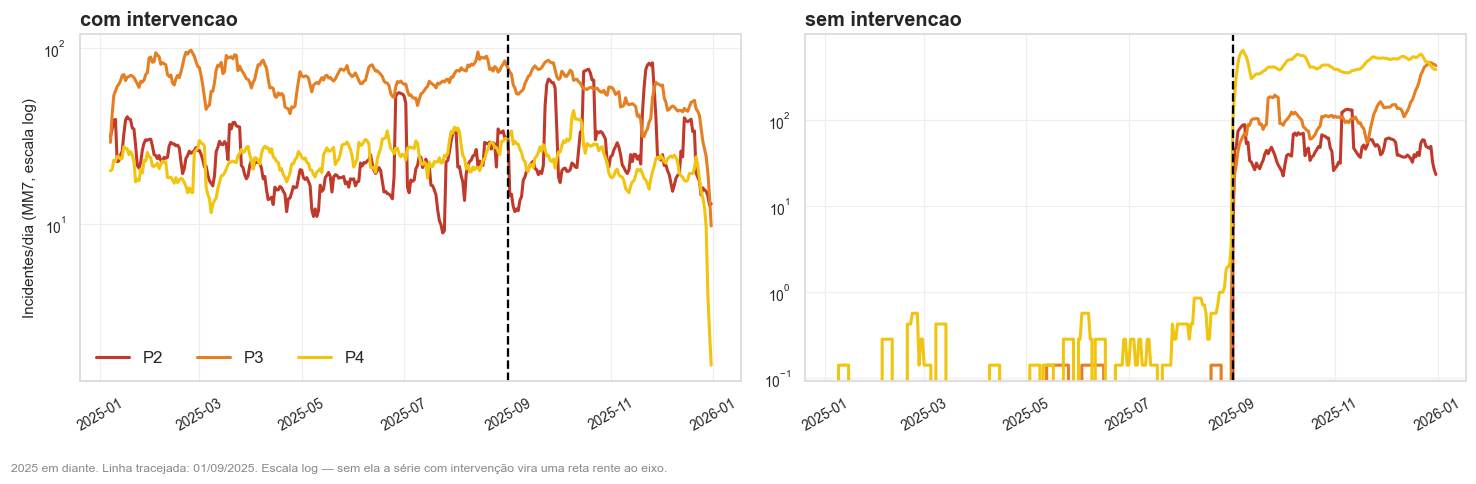

In [31]:
fig, axes = novo_grafico(
    "As 6 séries alvo", figsize=(13.5, 4.2), ncols=2,
)
for ax, tipo in zip(axes, TIPOS_TRATAMENTO):
    for p in PRIORIDADES_ALVO:
        s = (
            fato_diario_prioridade
            .query("prioridade == @p and tipo_tratamento == @tipo and data >= @Q_R2")
            .set_index("data")["abertos"]
        )
        ax.plot(s.index, s.rolling(7).mean(), lw=2, color=COR_PRIORIDADE[p], label=f"P{p}")
    ax.axvline(Q_R3, color="black", ls="--", lw=1.5)
    ax.set_yscale("log")
    ax.set_title(tipo.replace("_", " "))
    ax.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("Incidentes/dia (MM7, escala log)")
axes[0].legend(ncols=3)
finalizar(fig, f"2025 em diante. Linha tracejada: {Q_R3:%d/%m/%Y}. Escala log — sem ela a "
               "série com intervenção vira uma reta rente ao eixo.")

**Leitura — o resultado é limpo e assimétrico.**

| Série | R2 (243 dias) | R3 (122 dias) | Janela candidata |
|---|---|---|---|
| P2 com intervenção | 23,2/dia · 0 % zeros | 30,7/dia · 0 % zeros | **365 dias** |
| P3 com intervenção | 68,5/dia · 0 % zeros | 54,4/dia · 0 % zeros | **365 dias** |
| P4 com intervenção | 23,5/dia · 0 % zeros | 22,4/dia · 4 % zeros | **365 dias** |
| P2 sem intervenção | 0,0/dia · **100 % zeros** | 51,3/dia · 0 % zeros | 122 dias |
| P3 sem intervenção | 0,0/dia · **98 % zeros** | 147,2/dia · 0 % zeros | 122 dias |
| P4 sem intervenção | 0,3/dia · **86 % zeros** | 459,6/dia · 0 % zeros | 122 dias |

As três séries **com intervenção** são densas nos dois regimes e nenhuma delas tem dia zerado.
Se §3.1 confirmar que elas não sofrem quebra em setembro, R2 inteiro entra no treino: **365 dias
em vez de 122**. É o principal ganho de dados desta revisão.

As três séries **sem intervenção** são esparsas em R2 e densas em R3. Isso não é ruído: elas
simplesmente **não existiam** antes da automação. O `pct_zeros` de 86–100 % descreve uma série que
começa em setembro, não uma série de volume baixo. Para elas o histórico é de 122 dias, e nenhuma
janela mais longa é honesta.

Com `Q_R3` em 01/09 o aviso de corte mal posicionado **não dispara mais**: o volume de R2 nos 7
dias que antecedem o corte cai de 96–100 % para 0–44 % em cada série sem intervenção. A fronteira
está onde a série de fato começa.

## 3.1 Quebras estruturais — revisão do uso do `ruptures`

In [32]:
def preparar_sinal(serie, log=True, deseasonalizar=True, periodo=7):
    """
    Prepara a série para detecção de quebra.

    - `log1p` estabiliza a variância de contagem (a variância cresce com a média em Poisson);
    - a remoção do perfil semanal evita que o ciclo seg–dom seja lido como mudança de patamar.
      Aqui o perfil é multiplicativo e estimado sobre a série inteira — se o próprio perfil mudar
      entre regimes (e §3.3 mostra que muda), estime por regime antes de comparar.
    """
    s = pd.Series(serie).astype(float).copy()
    if log:
        s = np.log1p(s)
    if deseasonalizar:
        idx = np.arange(len(s)) % periodo
        perfil = s.groupby(idx).transform("mean")
        s = s - perfil + s.mean()
    return s.to_numpy()


def detectar_quebras(sinal, n_bkps=None, pen=None, min_size=30, modelo="rbf"):
    """
    Detecção com `jump=1` (grade completa) e dois modos:
      - `n_bkps`: número fixo de quebras (use só quando o número for conhecido);
      - `pen`: seleção por penalidade — o algoritmo decide quantas quebras existem.
    """
    if pen is not None:
        algo = rpt.KernelCPD(kernel=modelo, min_size=min_size).fit(sinal)
        return algo, algo.predict(pen=pen)
    algo = rpt.Dynp(model=modelo, min_size=min_size, jump=1).fit(sinal)
    return algo, algo.predict(n_bkps=n_bkps)


def curva_penalidade(sinal, penalidades, min_size=30, modelo="rbf"):
    """Quantas quebras sobrevivem a cada penalidade. Um patamar largo indica estrutura estável."""
    algo = rpt.KernelCPD(kernel=modelo, min_size=min_size).fit(sinal)
    return pd.DataFrame(
        [{"pen": p, "n_quebras": len(algo.predict(pen=p)) - 1} for p in penalidades]
    )

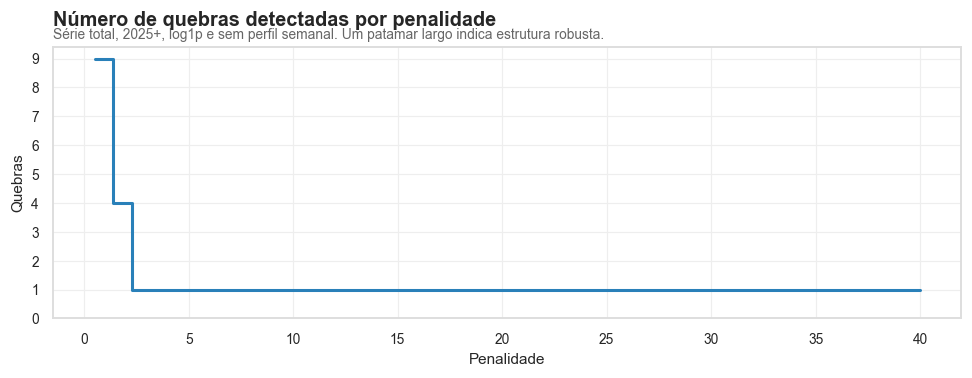

           min   max  count
n_quebras                  
9         0.50  0.50      1
4         1.40  1.40      1
1         2.30 40.00     43


In [33]:
# Série de trabalho: 2025 em diante, sem o regime-artefato.
serie_2025 = (
    fato_diario.loc[fato_diario["data"] >= Q_R2, ["data", "abertos_total"]]
    .reset_index(drop=True)
)
sinal_bruto = serie_2025["abertos_total"].to_numpy(dtype=float)
sinal_prep = preparar_sinal(sinal_bruto)

grade_pen = np.linspace(0.5, 40, 45)
curva = curva_penalidade(sinal_prep, grade_pen, min_size=21)

fig, ax = novo_grafico(
    "Número de quebras detectadas por penalidade",
    "Série total, 2025+, log1p e sem perfil semanal. Um patamar largo indica estrutura robusta.",
    figsize=(9, 3.6),
)
ax.step(curva["pen"], curva["n_quebras"], where="post", color=PALETA["destaque"], lw=2)
ax.set_xlabel("Penalidade")
ax.set_ylabel("Quebras")
ax.set_yticks(range(0, int(curva["n_quebras"].max()) + 1))
finalizar(fig)

print(curva.groupby("n_quebras")["pen"].agg(["min", "max", "count"]).sort_index(ascending=False))

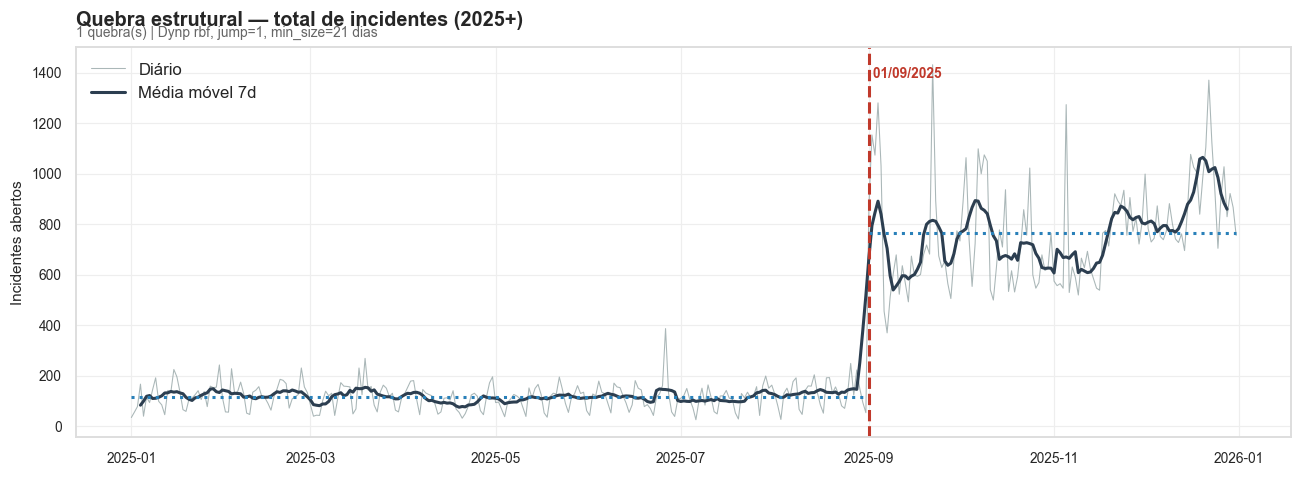

,bloco,inicio,fim,dias,media,mediana,desvio,razao_vs_anterior
0,1,2025-01-01,2025-08-31,243,116.82,120.00,51.18,NaN
1,2,2025-09-01,2025-12-31,122,765.76,735.50,201.78,6.55


In [34]:
def analisar_quebras(nome, serie_dias, valores, n_bkps=1, min_size=21):
    """Detecta, mede o efeito e desenha — em datas, não em índices."""
    sinal = preparar_sinal(valores)
    algo, pts = detectar_quebras(sinal, n_bkps=n_bkps, min_size=min_size)
    idx = pts[:-1]
    datas = [serie_dias.iloc[i] for i in idx]

    bordas = [0] + list(idx) + [len(sinal)]
    blocos = []
    for i in range(len(bordas) - 1):
        fatia = valores[bordas[i]:bordas[i + 1]]
        blocos.append({
            "bloco": i + 1,
            "inicio": serie_dias.iloc[bordas[i]],
            "fim": serie_dias.iloc[bordas[i + 1] - 1],
            "dias": len(fatia),
            "media": fatia.mean(),
            "mediana": np.median(fatia),
            "desvio": fatia.std(),
        })
    blocos = pd.DataFrame(blocos)
    blocos["razao_vs_anterior"] = (blocos["media"] / blocos["media"].shift(1)).round(2)

    fig, ax = novo_grafico(
        f"Quebra estrutural — {nome}",
        f"{n_bkps} quebra(s) | Dynp rbf, jump=1, min_size={min_size} dias",
    )
    ax.plot(serie_dias, valores, color=PALETA["neutro"], lw=0.7, alpha=0.8, label="Diário")
    ax.plot(serie_dias, pd.Series(valores).rolling(7, center=True).mean(),
            color=PALETA["total"], lw=2, label="Média móvel 7d")
    for d in datas:
        ax.axvline(d, color=PALETA["p2"], ls="--", lw=2)
        ax.annotate(f" {d:%d/%m/%Y}", (d, ax.get_ylim()[1] * 0.92),
                    color=PALETA["p2"], fontsize=9, weight="bold")
    for _, b in blocos.iterrows():
        ax.hlines(b["media"], b["inicio"], b["fim"], color=PALETA["destaque"], lw=2, ls=":")
    ax.set_ylabel("Incidentes abertos")
    ax.legend(loc="upper left")
    finalizar(fig)

    return datas, pts, sinal, algo, blocos


datas_q, pts_q, sinal_q, algo_q, blocos_q = analisar_quebras(
    "total de incidentes (2025+)", serie_2025["data"], sinal_bruto, n_bkps=1
)
blocos_q

Redução de custo observada     : 0.5951
Média sob a nula (200 permut.) : 0.0477
Máximo sob a nula              : 0.1737
p-valor por permutação         : 0.0050

Interpretação: o p-valor mede a chance de uma série SEM mudança de patamar,
mas com a mesma sazonalidade semanal, produzir um ganho tão grande.


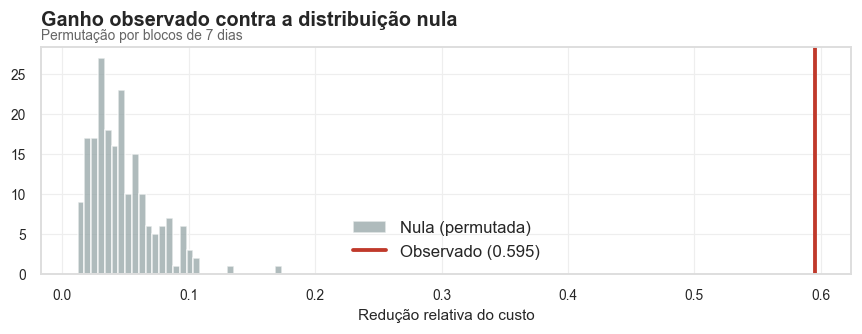

In [35]:
def teste_permutacao_quebra(sinal, n_bkps=1, min_size=21, n_perm=300, bloco=7, semente=42):
    """
    Testa o PROCEDIMENTO, não a quebra escolhida.

    Estatística: redução relativa do custo total ao permitir `n_bkps` quebras.
    Nula: a mesma série reordenada em blocos de 7 dias (permutação por blocos), o que preserva
    a autocorrelação de curto prazo e a sazonalidade semanal enquanto destrói a ordem de longo
    prazo — exatamente o que a hipótese "não há mudança de patamar" afirma.

    Isto resolve as duas fragilidades do Mann-Whitney aplicado depois da detecção: o ponto de
    corte deixa de ser escolhido nos mesmos dados em que é testado, e a autocorrelação deixa de
    inflar a significância.
    """
    rng = np.random.default_rng(semente)

    def ganho(x):
        algo = rpt.Dynp(model="rbf", min_size=min_size, jump=1).fit(x)
        pts = algo.predict(n_bkps=n_bkps)
        c_nulo = algo.cost.sum_of_costs([len(x)])
        return 1 - algo.cost.sum_of_costs(pts) / c_nulo if c_nulo > 0 else 0.0

    observado = ganho(sinal)

    n_blocos = int(np.ceil(len(sinal) / bloco))
    padded = np.pad(sinal, (0, n_blocos * bloco - len(sinal)), mode="wrap").reshape(n_blocos, bloco)

    nulos = []
    for _ in range(n_perm):
        emb = padded[rng.permutation(n_blocos)].ravel()[: len(sinal)]
        nulos.append(ganho(emb))
    nulos = np.array(nulos)

    p = (1 + (nulos >= observado).sum()) / (1 + n_perm)
    return observado, nulos, p


ganho_obs, ganho_nulo, p_valor = teste_permutacao_quebra(sinal_q, n_bkps=1, n_perm=200)

print(f"Redução de custo observada     : {ganho_obs:.4f}")
print(f"Média sob a nula (200 permut.) : {ganho_nulo.mean():.4f}")
print(f"Máximo sob a nula              : {ganho_nulo.max():.4f}")
print(f"p-valor por permutação         : {p_valor:.4f}")
print()
print("Interpretação: o p-valor mede a chance de uma série SEM mudança de patamar,")
print("mas com a mesma sazonalidade semanal, produzir um ganho tão grande.")

fig, ax = novo_grafico("Ganho observado contra a distribuição nula",
                       "Permutação por blocos de 7 dias", figsize=(8, 3.2))
ax.hist(ganho_nulo, bins=30, color=PALETA["neutro"], alpha=0.75, label="Nula (permutada)")
ax.axvline(ganho_obs, color=PALETA["p2"], lw=2.5, label=f"Observado ({ganho_obs:.3f})")
ax.set_xlabel("Redução relativa do custo")
ax.legend()
finalizar(fig)

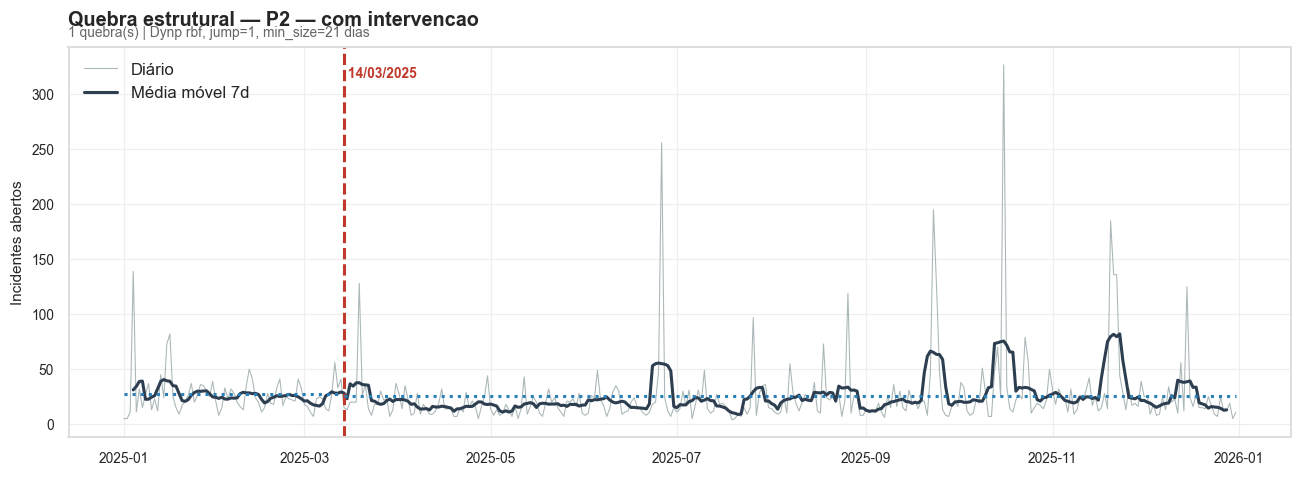

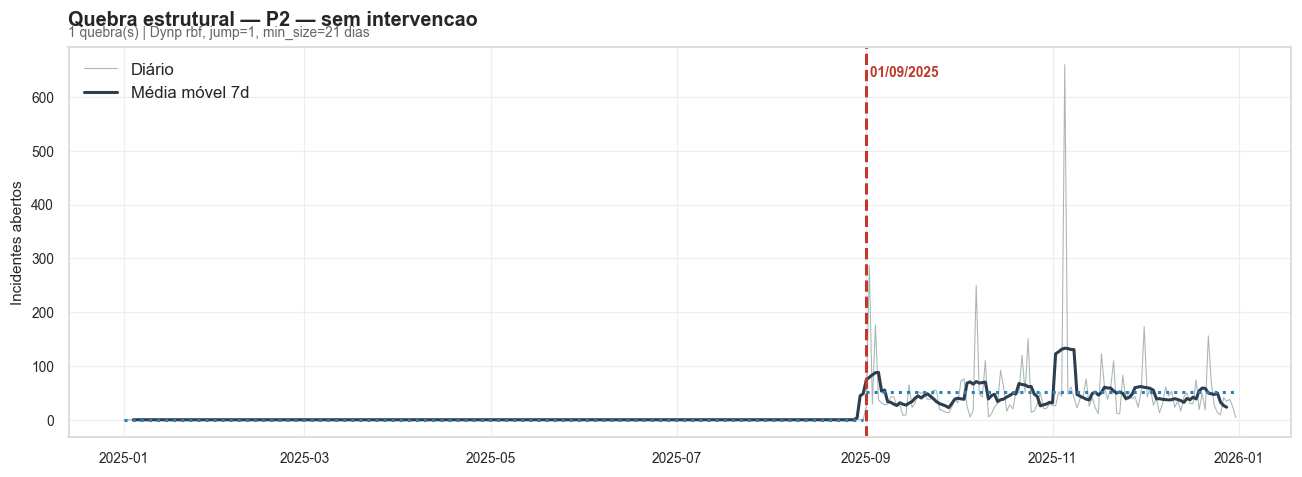

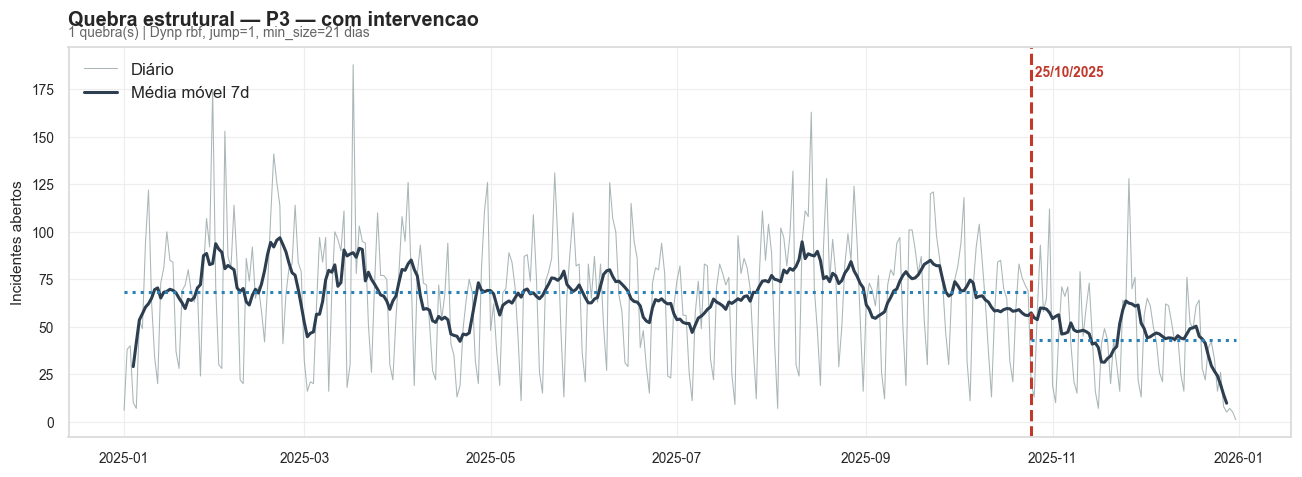

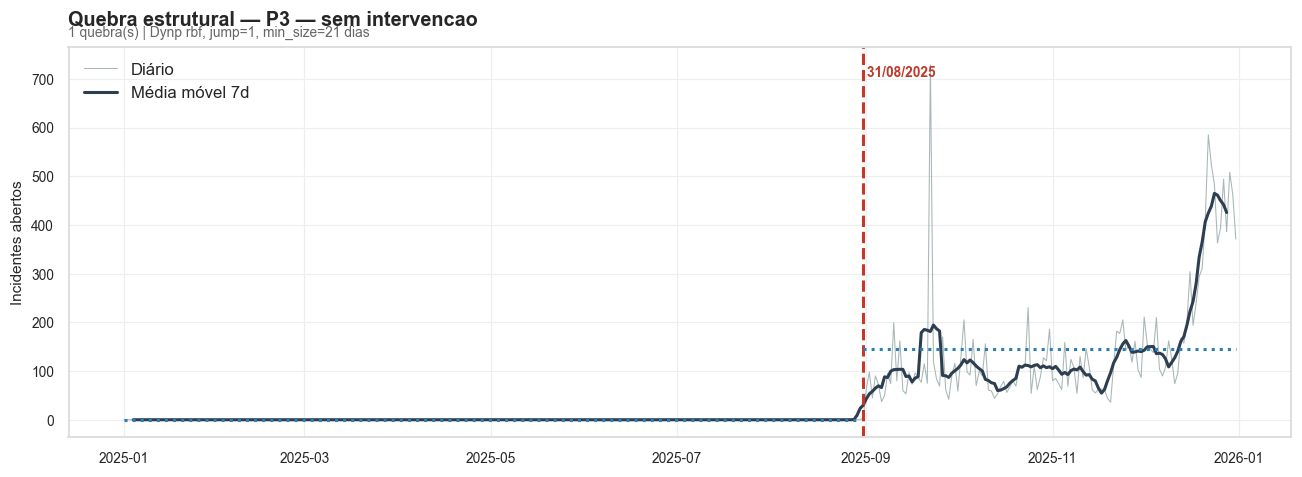

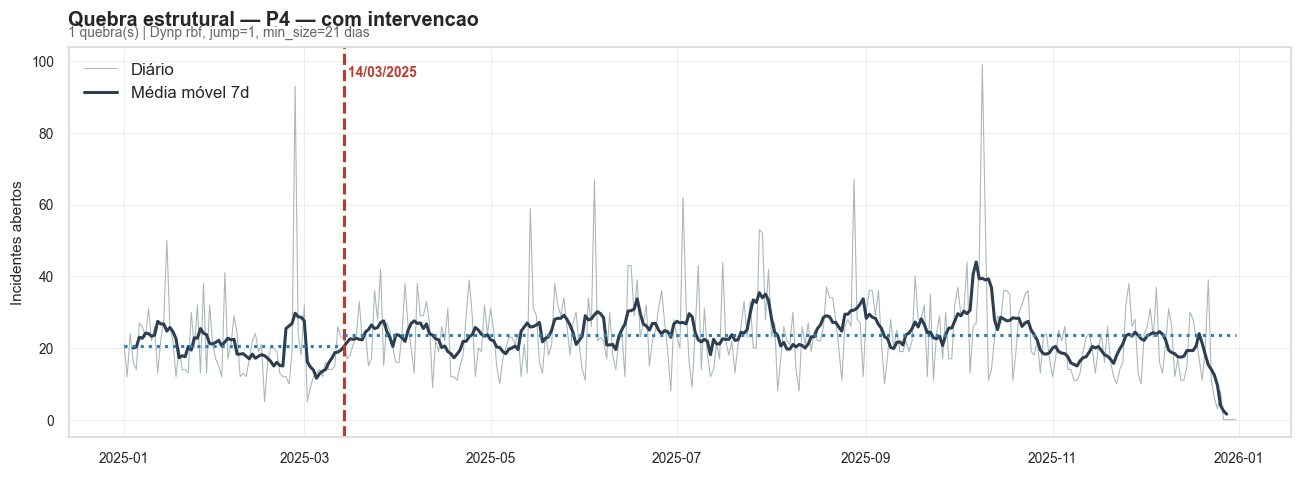

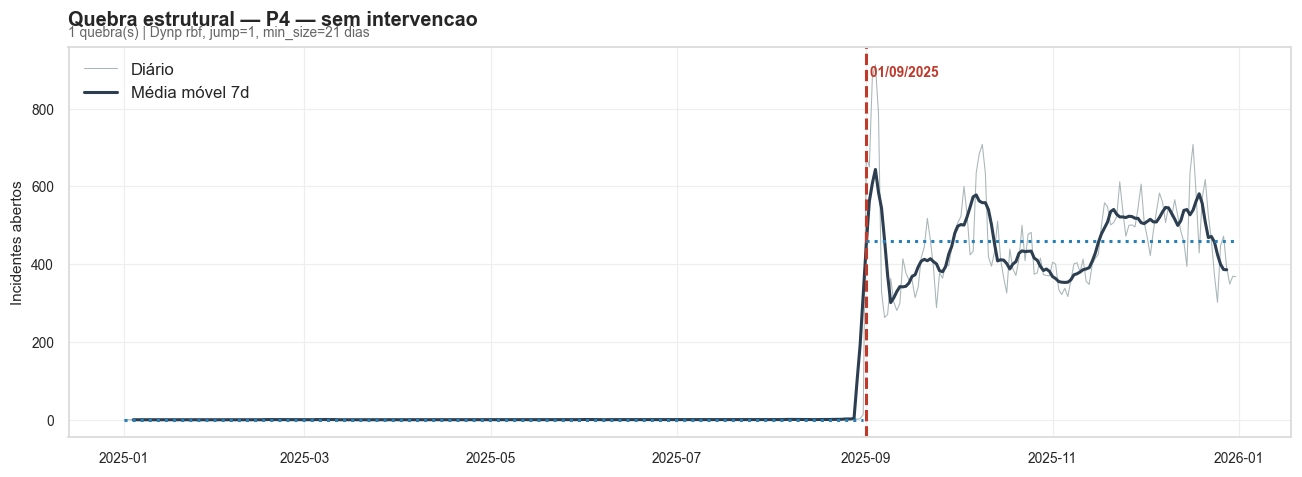


Janela de treino liberada por série

  P2 com_intervencao  a partir de 01/01/2025  (365 dias)
  P2 sem_intervencao  a partir de 01/09/2025  (122 dias)  <- restrita pela quebra
  P3 com_intervencao  a partir de 25/10/2025  ( 68 dias)  <- restrita pela quebra
  P3 sem_intervencao  a partir de 31/08/2025  (123 dias)  <- restrita pela quebra
  P4 com_intervencao  a partir de 01/01/2025  (365 dias)
  P4 sem_intervencao  a partir de 01/09/2025  (122 dias)  <- restrita pela quebra


,prioridade,tipo_tratamento,dias,data_quebra,media_antes,media_depois,razao,p_permutacao,quebra_relevante,dias_ate_q_r3
0,2,com_intervencao,365,2025-03-14,27.04,25.38,0.94,0.01,False,-171
1,2,sem_intervencao,365,2025-09-01,0.00,51.33,inf,0.01,True,0
2,3,com_intervencao,365,2025-10-25,68.55,43.18,0.63,0.01,True,54
3,3,sem_intervencao,365,2025-08-31,0.02,146.02,"7,067.58",0.01,True,-1
4,4,com_intervencao,365,2025-03-14,20.51,23.76,1.16,0.05,False,-171
5,4,sem_intervencao,365,2025-09-01,0.30,459.57,"1,529.81",0.01,True,0


In [36]:
# Item 4a — o pipeline inteiro nas 6 séries, 2025 em diante.
# A pergunta que decide a janela de treino: a quebra de setembro aparece nas séries COM
# intervenção, ou elas atravessam a data planas? Mesmas escolhas já validadas acima —
# jump=1, log1p, perfil semanal removido, permutação por blocos de 7 dias.
def diagnosticar_serie(prioridade, tipo, desde=Q_R2, n_bkps=1,
                       min_size=MIN_SIZE_QUEBRA, n_perm=N_PERM_QUEBRA):
    serie = (
        fato_diario_prioridade
        .query("prioridade == @prioridade and tipo_tratamento == @tipo and data >= @desde")
        .sort_values("data")
    )
    nome = f"P{prioridade} — {tipo.replace('_', ' ')}"
    datas, _, sinal, _, blocos = analisar_quebras(
        nome, serie["data"].reset_index(drop=True),
        serie["abertos"].to_numpy(dtype=float), n_bkps=n_bkps, min_size=min_size,
    )
    _, _, p_val = teste_permutacao_quebra(
        sinal, n_bkps=n_bkps, min_size=min_size, n_perm=n_perm
    )
    return {
        "prioridade": prioridade,
        "tipo_tratamento": tipo,
        "dias": len(serie),
        "data_quebra": datas[0],
        "media_antes": blocos.loc[0, "media"],
        "media_depois": blocos.loc[1, "media"],
        "razao": blocos.loc[1, "razao_vs_anterior"],
        "p_permutacao": p_val,
    }


resumo_quebras = pd.DataFrame([
    diagnosticar_serie(p, t) for p in PRIORIDADES_ALVO for t in TIPOS_TRATAMENTO
])

# Uma quebra só conta se o procedimento sobrevive à permutação E o patamar muda de verdade.
# Sem o segundo critério, uma diferença de 5 % em série longa sai "significativa".
resumo_quebras["quebra_relevante"] = (
    (resumo_quebras["p_permutacao"] <= LIMIAR_P_QUEBRA)
    & ((resumo_quebras["razao"] >= RAZAO_MIN_QUEBRA)
       | (resumo_quebras["razao"] <= 1 / RAZAO_MIN_QUEBRA))
)
resumo_quebras["dias_ate_q_r3"] = (resumo_quebras["data_quebra"] - Q_R3).dt.days

# Janela de treino liberada por série: se não há quebra relevante, R2 inteiro entra.
JANELA_TREINO = {
    (l.prioridade, l.tipo_tratamento): (l.data_quebra if l.quebra_relevante else Q_R2)
    for l in resumo_quebras.itertuples()
}

print("\nJanela de treino liberada por série\n")
for (p, t), inicio in JANELA_TREINO.items():
    n = int((fato_diario_prioridade["data"].max() - inicio).days) + 1
    marca = "" if inicio == Q_R2 else "  <- restrita pela quebra"
    print(f"  P{p} {t:<16} a partir de {inicio:%d/%m/%Y}  ({n:>3} dias){marca}")

resumo_quebras.round(4)

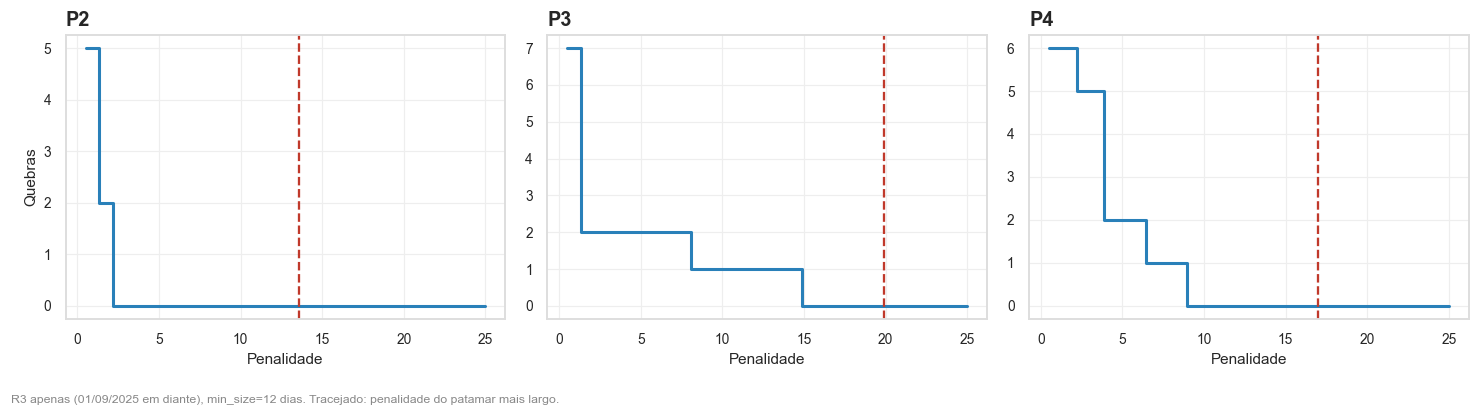

,prioridade,dias,n_quebras,pen_escolhida,largura_patamar,data_quebra,media_antes,media_depois,razao,p_permutacao
0,2,122,0,13.59,28,NaT,51.33,NaN,NaN,NaN
1,3,122,0,19.93,13,NaT,147.19,NaN,NaN,NaN
2,4,122,0,16.97,20,NaT,459.57,NaN,NaN,NaN


In [37]:
# Item 4b — mini-quebra DENTRO de R3, nas três séries sem intervenção.
# Elas respondem a configuração de monitoramento, não à saúde da plataforma: uma segunda
# mudança dentro dos 120 dias encurtaria ainda mais o histórico útil delas. Aqui o número de
# quebras NÃO é imposto — sai da curva de penalidade, que é o modo honesto de perguntar
# "existe alguma?" em vez de "onde está a que eu já decidi que existe?".
GRADE_PEN_R3 = np.linspace(0.5, 25, 30)


def blocos_entre_quebras(dias, valores, pts):
    """Média/mediana de cada bloco delimitado pelos pontos de quebra."""
    bordas = [0] + list(pts[:-1]) + [len(valores)]
    linhas = []
    for i in range(len(bordas) - 1):
        fatia = valores[bordas[i]:bordas[i + 1]]
        linhas.append({
            "bloco": i + 1,
            "inicio": dias.iloc[bordas[i]],
            "fim": dias.iloc[bordas[i + 1] - 1],
            "dias": len(fatia),
            "media": fatia.mean(),
        })
    out = pd.DataFrame(linhas)
    out["razao_vs_anterior"] = (out["media"] / out["media"].shift(1)).round(2)
    return out


linhas_r3, blocos_r3 = [], {}
fig, axes = novo_grafico(
    "Curva de penalidade dentro de R3 — séries sem intervenção", figsize=(13.5, 3.6), ncols=3,
)
for ax, p in zip(axes, PRIORIDADES_ALVO):
    serie = (
        fato_diario_prioridade
        .query("prioridade == @p and tipo_tratamento == 'sem_intervencao' and data >= @Q_R3")
        .sort_values("data")
    )
    dias = serie["data"].reset_index(drop=True)
    valores = serie["abertos"].to_numpy(dtype=float)
    sinal = preparar_sinal(valores)

    curva_r3 = curva_penalidade(sinal, GRADE_PEN_R3, min_size=MIN_SIZE_QUEBRA_R3)
    ax.step(curva_r3["pen"], curva_r3["n_quebras"], where="post", color=PALETA["destaque"], lw=2)
    ax.set_title(f"P{p}")
    ax.set_xlabel("Penalidade")

    # Patamar mais largo = estrutura mais estável. Se ele é o de zero quebras, não há quebra.
    patamares = curva_r3.groupby("n_quebras")["pen"].agg(["min", "max", "count"])
    n_escolhido = int(patamares["count"].idxmax())
    pen_escolhida = float(patamares.loc[n_escolhido, ["min", "max"]].mean())
    ax.axvline(pen_escolhida, color=PALETA["p2"], ls="--", lw=1.5)

    linha = {"prioridade": p, "dias": len(serie), "n_quebras": n_escolhido,
             "pen_escolhida": round(pen_escolhida, 2),
             "largura_patamar": int(patamares.loc[n_escolhido, "count"])}
    if n_escolhido == 0:
        linha.update({"data_quebra": pd.NaT, "media_antes": valores.mean(),
                      "media_depois": np.nan, "razao": np.nan, "p_permutacao": np.nan})
    else:
        _, pts = detectar_quebras(sinal, pen=pen_escolhida, min_size=MIN_SIZE_QUEBRA_R3)
        b = blocos_entre_quebras(dias, valores, pts)
        blocos_r3[p] = b
        _, _, p_val = teste_permutacao_quebra(
            sinal, n_bkps=n_escolhido, min_size=MIN_SIZE_QUEBRA_R3, n_perm=N_PERM_QUEBRA
        )
        linha.update({"data_quebra": b.loc[1, "inicio"], "media_antes": b.loc[0, "media"],
                      "media_depois": b.loc[1, "media"], "razao": b.loc[1, "razao_vs_anterior"],
                      "p_permutacao": p_val})
    linhas_r3.append(linha)

axes[0].set_ylabel("Quebras")
finalizar(fig, f"R3 apenas ({Q_R3:%d/%m/%Y} em diante), min_size={MIN_SIZE_QUEBRA_R3} dias. "
               "Tracejado: penalidade do patamar mais largo.")

quebras_r3 = pd.DataFrame(linhas_r3)

# Se houver mini-quebra relevante, ela encurta a janela da série — atualiza JANELA_TREINO.
for l in quebras_r3.itertuples():
    if l.n_quebras and pd.notna(l.p_permutacao) and l.p_permutacao <= LIMIAR_P_QUEBRA and (
        l.razao >= RAZAO_MIN_QUEBRA or l.razao <= 1 / RAZAO_MIN_QUEBRA
    ):
        JANELA_TREINO[(l.prioridade, "sem_intervencao")] = l.data_quebra
        print(f"AVISO — P{l.prioridade} sem_intervencao tem mini-quebra em "
              f"{l.data_quebra:%d/%m/%Y} (razão {l.razao}, p={l.p_permutacao:.3f}). "
              f"Janela de treino encurtada.")

quebras_r3.round(4)

**Leitura — a hipótese se confirma, e aparece uma quebra que ninguém procurava.**

| Série | Quebra detectada | Antes → depois | Razão | p (permutação) | Relevante? |
|---|---|---|---|---|---|
| P2 com intervenção | 14/03/2025 | 27,0 → 25,4 | 0,94 | 0,01 | **não** |
| P4 com intervenção | 14/03/2025 | 20,5 → 23,8 | 1,16 | 0,05 | **não** |
| P3 com intervenção | **25/10/2025** | 68,6 → 43,2 | **0,63** | 0,01 | **sim** |
| P2 sem intervenção | 01/09/2025 | 0,0 → 51,3 | ∞ | 0,01 | sim |
| P3 sem intervenção | 31/08/2025 | 0,02 → 146,0 | 7.068 | 0,01 | sim |
| P4 sem intervenção | 01/09/2025 | 0,3 → 459,6 | 1.530 | 0,01 | sim |

A detecção roda sobre a série de 2025 inteira, **independente de `Q_R3`** — é o que permite usá-la
para auditar o valor da constante em vez de assumi-lo.

**1. Nenhuma das três séries com intervenção quebra em setembro.** É o principal resultado desta
revisão. O detector é forçado a apontar exatamente uma quebra em cada série (`n_bkps=1`), então
ele sempre devolve *alguma* data — e é por isso que o p-valor sozinho não decide. Em P2 e P4 a
quebra encontrada tem razão 0,94 e 1,16: mudança de patamar de 6 % e 16 %, ruído de série anual.
São elas que liberam **365 dias de treino**.

**2. As três séries sem intervenção quebram em 31/08–01/09, e `Q_R3` foi ajustado para 01/09.**
A detecção feita diretamente em cada série encontra a data que a detecção sobre o total não
encontrou, e o corte anterior (03/09) ficava dois dias tarde. Com a constante em 01/09, R2 deixa
de conter o arranque da automação: o resíduo `Sem Intervenção` em R2 cai de 1.883 para 82 tickets.
A razão de 7.068× em P3 não é exagero de escala — é uma série que era de 0,02 incidentes por dia
e passou a 146.

**3. P3 com intervenção tem uma quebra própria, em 25/10, e ela não tem nada a ver com a
automação.** O volume cai de 68,6 para 43,2 por dia — 37 % a menos, sete semanas depois da
mudança de instrumentação. Isso encurta a janela de treino dessa série para 68 dias, o pior
histórico das seis, e merece pergunta à área: mudança de roteamento, reclassificação de
prioridade, ou queda real de demanda? Enquanto não houver resposta, a janela curta é a leitura
conservadora e é a que `JANELA_TREINO` aplica.

**4. Dentro de R3 não há mini-quebra.** A curva de penalidade das três séries sem intervenção
escolhe **zero quebras** como o patamar mais largo, com `min_size` de 12 dias — e continua
escolhendo zero com os 122 dias do corte novo. Os 122 dias de R3 são estruturalmente estáveis
para elas — o histórico é curto, mas é homogêneo, e nada indica uma segunda mudança de
configuração de monitoramento no período.

## 3.2 O que explica a quebra de setembro

A quebra é grande demais para ser crescimento de demanda. Três cortes convergem para a mesma
explicação, e a consequência para o alvo é direta.

In [38]:
comparativo = (
    df[df["regime"].isin(REGIME_MODELAVEL)]
    .groupby("regime", observed=True)
    .agg(
        incidentes=("Número", "size"),
        dias=("data", "nunique"),
        pct_monitoramento=("aberto_por_monitoramento", lambda s: s.mean() * 100),
        pct_sem_intervencao=("sem_intervencao", lambda s: s.mean() * 100),
        duracao_mediana_h=("duracao_horas", "median"),
        duracao_media_h=("duracao_horas", "mean"),
        pct_sem_ic=("ic_ausente", lambda s: s.mean() * 100),
        pct_sem_classificacao=("sem_classificacao", lambda s: s.mean() * 100),
        ics_distintos=("ic", "nunique"),
    )
)
comparativo["media_dia"] = comparativo["incidentes"] / comparativo["dias"]
comparativo.T

regime,2,3
incidentes,"28,388.00","93,423.00"
dias,243.00,122.00
pct_monitoramento,54.89,94.76
pct_sem_intervencao,0.29,85.94
duracao_mediana_h,1.55,0.16
duracao_media_h,121.76,9.54
pct_sem_ic,0.40,1.78
pct_sem_classificacao,3.50,82.12
ics_distintos,"4,973.00","6,393.00"
media_dia,116.82,765.76


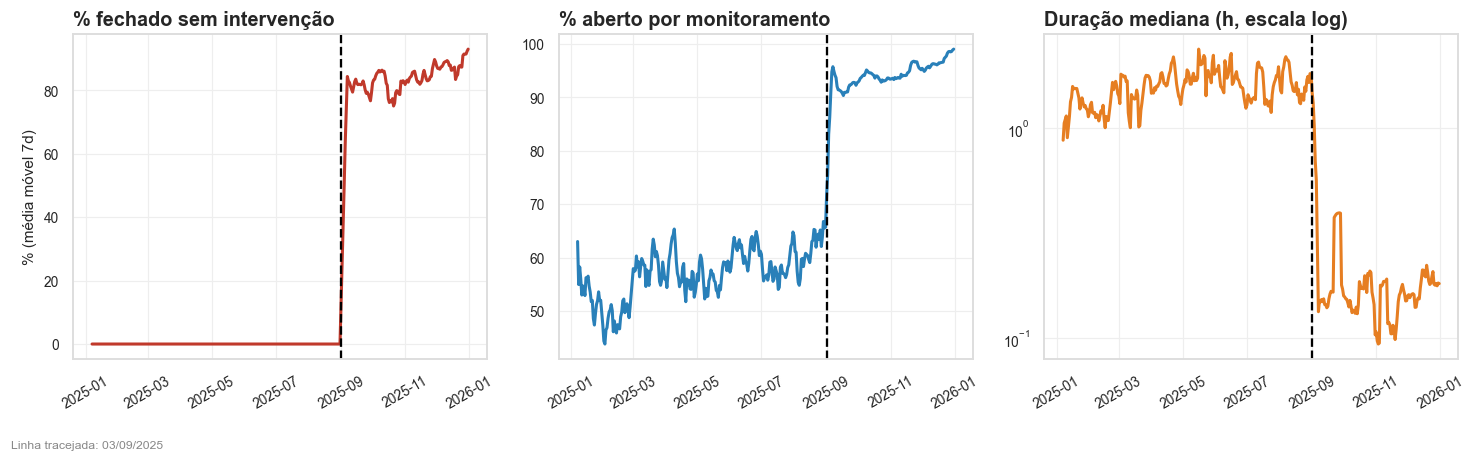

In [39]:
fig, axes = novo_grafico("Anatomia da quebra de setembro/2025", figsize=(13.5, 4), ncols=3)

serie = fato_diario[fato_diario["data"] >= Q_R2]

axes[0].plot(serie["data"], serie["taxa_sem_intervencao_total"].rolling(7).mean(),
             color=PALETA["p2"], lw=2)
axes[0].set_title("% fechado sem intervenção")
axes[0].set_ylabel("% (média móvel 7d)")

axes[1].plot(serie["data"], serie["taxa_monitoramento_total"].rolling(7).mean(),
             color=PALETA["destaque"], lw=2)
axes[1].set_title("% aberto por monitoramento")

dur = (
    df[df["regime"].isin(REGIME_MODELAVEL)]
    .groupby("data_encerrado", observed=True)["duracao_horas"].median()
)
axes[2].plot(dur.index, dur.rolling(7).mean(), color=PALETA["p3"], lw=2)
axes[2].set_yscale("log")
axes[2].set_title("Duração mediana (h, escala log)")

for ax in axes:
    ax.axvline(Q_R3, color="black", ls="--", lw=1.5)
    ax.tick_params(axis="x", rotation=30)
finalizar(fig, "Linha tracejada: 03/09/2025")

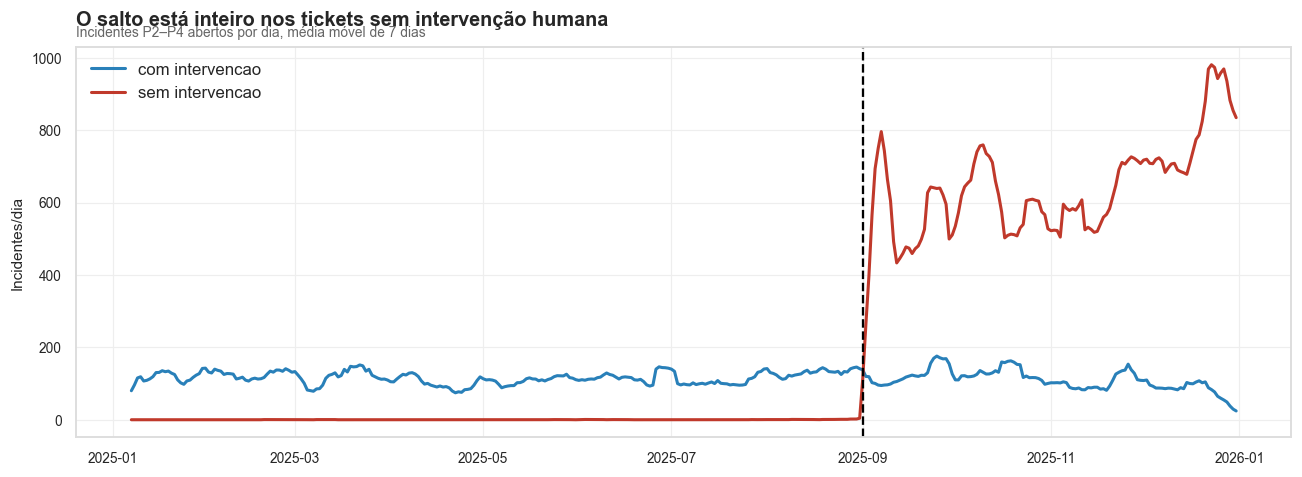

tipo_tratamento,com_intervencao,sem_intervencao
regime,,
2,115.23,0.34
3,107.51,658.09
fator_r3_r2,0.93,"1,950.19"


In [40]:
# Se os tickets sem intervenção saírem, o que sobra do salto? A pergunta agora se responde
# com a própria dimensão do fato — não é preciso recriar o recorte com np.where.
por_tipo = (
    fato_diario_prioridade
    .groupby(["data", "tipo_tratamento", "regime"], observed=True)["abertos"]
    .sum().reset_index()
)

fig, ax = novo_grafico(
    "O salto está inteiro nos tickets sem intervenção humana",
    "Incidentes P2–P4 abertos por dia, média móvel de 7 dias",
)
for tipo in TIPOS_TRATAMENTO:
    s = por_tipo[(por_tipo["tipo_tratamento"] == tipo) & (por_tipo["data"] >= Q_R2)]
    ax.plot(s["data"], s["abertos"].rolling(7).mean(), lw=2,
            color=COR_TIPO[tipo], label=tipo.replace("_", " "))
ax.axvline(Q_R3, color="black", ls="--", lw=1.5)
ax.set_ylabel("Incidentes/dia")
ax.legend()
finalizar(fig)

razao = (
    por_tipo.query("regime in @REGIME_MODELAVEL")
    .groupby(["regime", "tipo_tratamento"], observed=True)["abertos"].mean().unstack()
)
razao.loc["fator_r3_r2"] = (razao.loc[3] / razao.loc[2]).round(2)
razao.round(2)

> **Decisão fechada com a área: o alvo são as duas séries, separadamente.**
>
> A pergunta que esta seção abriu — "o alvo inclui os tickets `Sem Intervenção`?" — não tinha
> resposta técnica, porque as duas alternativas respondem a perguntas de negócio diferentes:
>
> - **incluir** faz o modelo prever majoritariamente o volume de um pipeline automático, que
>   responde a mudanças de configuração de monitoramento e não à saúde da plataforma. É
>   previsível, porque é máquina;
> - **excluir** faz o modelo medir a carga que chega a uma pessoa — mais próximo da intenção
>   original, mas uma série menor.
>
> A resposta foi **as duas**, como séries separadas. Daí a dimensão `tipo_tratamento` (§2.2) e as
> 6 séries alvo dimensionadas em §3.0. Vale registrar o que o recorte revelou e que não estava
> visível quando só existia o total:
>
> **a quebra de setembro está inteiramente na série sem intervenção. A série com intervenção
> atravessa a data plana** — de 115,2 para 107,5 incidentes/dia, fator 0,93×. O que multiplicava
> por 6,6 no total era a soma de uma série que nasce em setembro com outra que não se moveu.
>
> Consequência para a modelagem, e é a mais importante deste notebook: as duas metades **não têm
> o mesmo histórico**. A série com intervenção pode usar 365 dias; a sem intervenção, 122. O
> diagnóstico de §3.9, escrito quando o alvo era um só, vale apenas para a segunda metade.
> §3.1 confirma isso série a série.

## 3.3 Sazonalidade

Comparações sempre entre R2 e R3, nunca contra R1 — R1 não é um regime de negócio.

O que se mede aqui é **razão**, não diferença: quanto o volume de R3 é maior que o de R2 em cada
recorte. Um crescimento uniforme daria a mesma razão em todos os cortes. Onde a razão desvia, há
informação sobre a *natureza* da mudança.

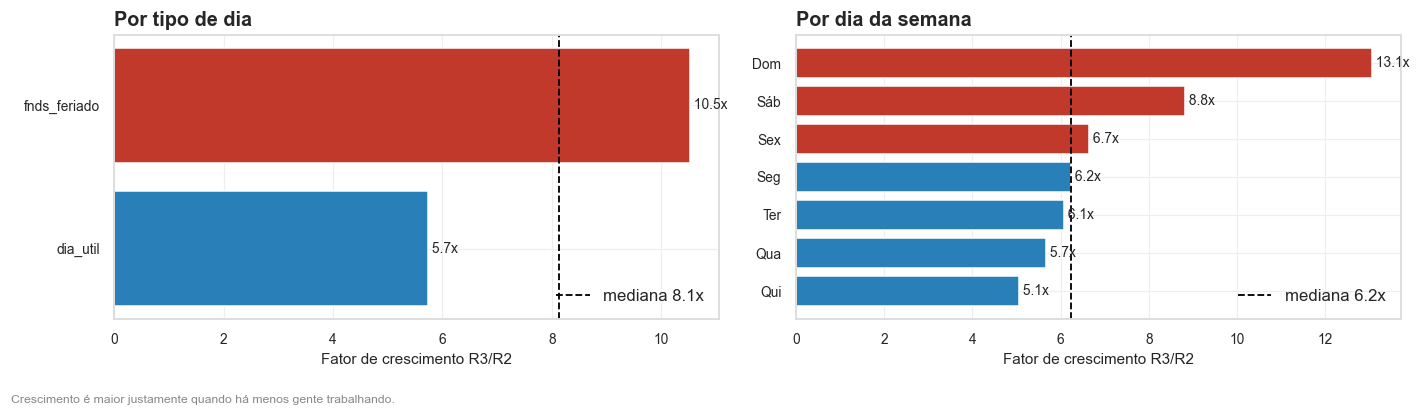

In [41]:
def fator_crescimento(dados, dimensao, valor="abertos", regimes=(2, 3)):
    """Média diária por categoria em cada regime + a razão entre eles."""
    tab = (
        dados[dados["regime"].isin(regimes)]
        .groupby(["regime", dimensao], observed=True)[valor].mean()
        .unstack("regime")
        .rename(columns=lambda r: f"R{r}")
    )
    tab["fator"] = (tab[f"R{regimes[1]}"] / tab[f"R{regimes[0]}"]).round(2)
    return tab.sort_values("fator")


def grafico_fator(tab, titulo, subtitulo=None, ax=None):
    criado = ax is None
    if criado:
        fig, ax = novo_grafico(titulo, subtitulo, figsize=(8, 3.4))
    else:
        ax.set_title(titulo)
    cores = [PALETA["p2"] if v > tab["fator"].median() else PALETA["destaque"] for v in tab["fator"]]
    ax.barh(tab.index.astype(str), tab["fator"], color=cores)
    ax.axvline(tab["fator"].median(), color="black", ls="--", lw=1.2,
               label=f"mediana {tab['fator'].median():.1f}x")
    for i, v in enumerate(tab["fator"]):
        ax.text(v, i, f" {v:.1f}x", va="center", fontsize=9)
    ax.set_xlabel("Fator de crescimento R3/R2")
    ax.legend(loc="lower right")
    if criado:
        finalizar(fig)
    return ax


base_dia = fato_diario_prioridade.merge(
    dim_calendario[["data", "tipo_dia", "nome_dia_semana", "dia_semana"]], on="data", how="left"
)
diario_total = base_dia.groupby(["data", "regime", "tipo_dia", "nome_dia_semana", "dia_semana"],
                                observed=True)["abertos"].sum().reset_index()

fig, axes = novo_grafico("Onde o crescimento se concentrou", figsize=(13, 3.6), ncols=2)
grafico_fator(fator_crescimento(diario_total, "tipo_dia"), "Por tipo de dia", ax=axes[0])
sem = fator_crescimento(diario_total.sort_values("dia_semana"), "nome_dia_semana")
grafico_fator(sem, "Por dia da semana", ax=axes[1])
finalizar(fig, "Crescimento é maior justamente quando há menos gente trabalhando.")

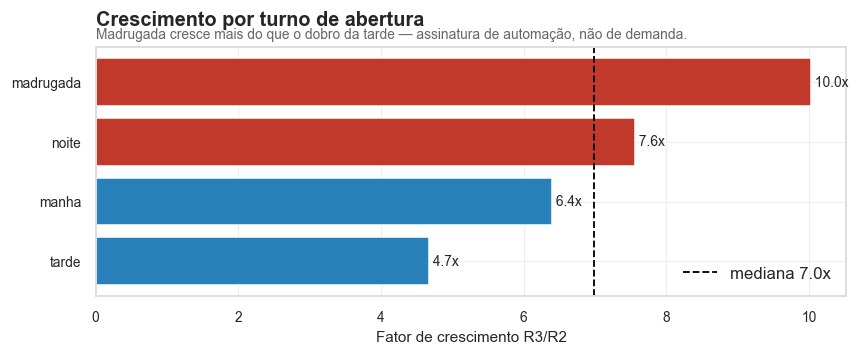

regime,R2,R3,fator
turno,,,
tarde,40.60,189.64,4.67
manha,32.08,205.37,6.40
noite,24.01,181.61,7.56
madrugada,18.86,188.98,10.02


In [42]:
turno_total = (
    fato_diario_prioridade_turno.groupby(["data", "regime", "turno"], observed=True)["abertos"]
    .sum().reset_index()
)
tab_turno = fator_crescimento(turno_total, "turno")
grafico_fator(
    tab_turno, "Crescimento por turno de abertura",
    "Madrugada cresce mais do que o dobro da tarde — assinatura de automação, não de demanda.",
)
tab_turno

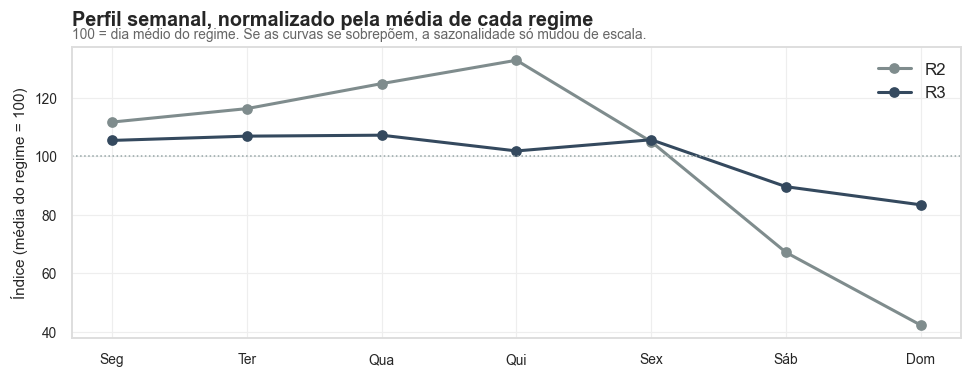

regime,2,3
nome_dia_semana,,
Dom,42.20,83.40
Qua,124.90,107.20
Qui,132.90,101.80
Seg,111.70,105.40
Sex,105.00,105.70
Sáb,67.10,89.60
Ter,116.30,106.90


In [43]:
# O perfil semanal mudou de forma, não só de escala? Normalizando cada regime pela própria média.
perfil = (
    diario_total[diario_total["regime"].isin(REGIME_MODELAVEL)]
    .groupby(["regime", "dia_semana", "nome_dia_semana"], observed=True)["abertos"].mean()
    .reset_index()
)
perfil["indice"] = perfil["abertos"] / perfil.groupby("regime")["abertos"].transform("mean") * 100

fig, ax = novo_grafico(
    "Perfil semanal, normalizado pela média de cada regime",
    "100 = dia médio do regime. Se as curvas se sobrepõem, a sazonalidade só mudou de escala.",
    figsize=(9, 3.6),
)
for r, cor in [(2, PALETA["r2"]), (3, PALETA["r3"])]:
    sub = perfil[perfil["regime"] == r].sort_values("dia_semana")
    ax.plot(sub["nome_dia_semana"], sub["indice"], marker="o", lw=2, color=cor, label=f"R{r}")
ax.axhline(100, color=PALETA["neutro"], ls=":", lw=1)
ax.set_ylabel("Índice (média do regime = 100)")
ax.legend()
finalizar(fig)

perfil.pivot(index="nome_dia_semana", columns="regime", values="indice").round(1)

O achatamento da curva em R3 é a evidência mais limpa de automação: o alerta automático não sabe
que é domingo. Para a modelagem isso significa que **`dia_semana` perdeu poder preditivo em R3** —
uma feature calibrada em R2 vai carregar uma sazonalidade que já não existe. Vale testar o modelo
com e sem os termos semanais.

## 3.4 Prioridade

A recomposição do mix é o segundo achado que condiciona a modelagem.

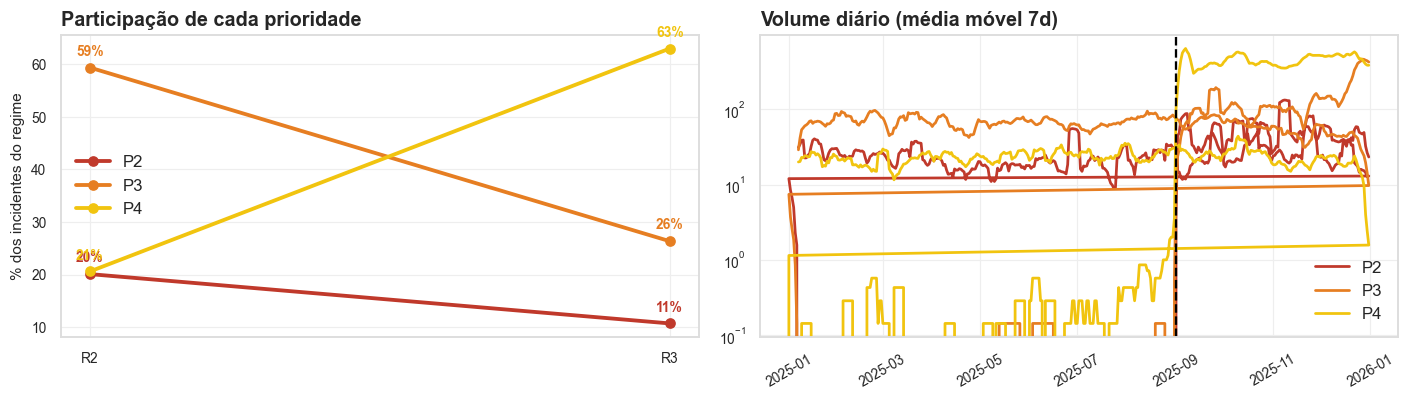

regime,2,3
prioridade,,
2,20.10,10.70
3,59.30,26.30
4,20.60,63.00


In [44]:
mix = (
    fato_diario_prioridade[fato_diario_prioridade["regime"].isin(REGIME_MODELAVEL)]
    .groupby(["regime", "prioridade"], observed=True)["abertos"].sum().reset_index()
)
mix["pct"] = mix["abertos"] / mix.groupby("regime")["abertos"].transform("sum") * 100

fig, axes = novo_grafico("Prioridade: recomposição do mix", figsize=(13, 3.8), ncols=2)

for p in PRIORIDADES_ALVO:
    sub = mix[mix["prioridade"] == p]
    axes[0].plot([f"R{r}" for r in sub["regime"]], sub["pct"], marker="o", lw=2.5,
                 color=COR_PRIORIDADE[p], label=f"P{p}")
    for _, linha in sub.iterrows():
        axes[0].annotate(f"{linha['pct']:.0f}%", (f"R{int(linha['regime'])}", linha["pct"]),
                         textcoords="offset points", xytext=(0, 8), ha="center",
                         color=COR_PRIORIDADE[p], fontsize=9, weight="bold")
axes[0].set_title("Participação de cada prioridade")
axes[0].set_ylabel("% dos incidentes do regime")
axes[0].legend()

serie_p = fato_diario_prioridade[fato_diario_prioridade["data"] >= Q_R2]
for p in PRIORIDADES_ALVO:
    sub = serie_p[serie_p["prioridade"] == p]
    axes[1].plot(sub["data"], sub["abertos"].rolling(7).mean(), lw=1.8,
                 color=COR_PRIORIDADE[p], label=f"P{p}")
axes[1].axvline(Q_R3, color="black", ls="--", lw=1.5)
axes[1].set_title("Volume diário (média móvel 7d)")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()
finalizar(fig)

mix.pivot(index="prioridade", columns="regime", values="pct").round(1)

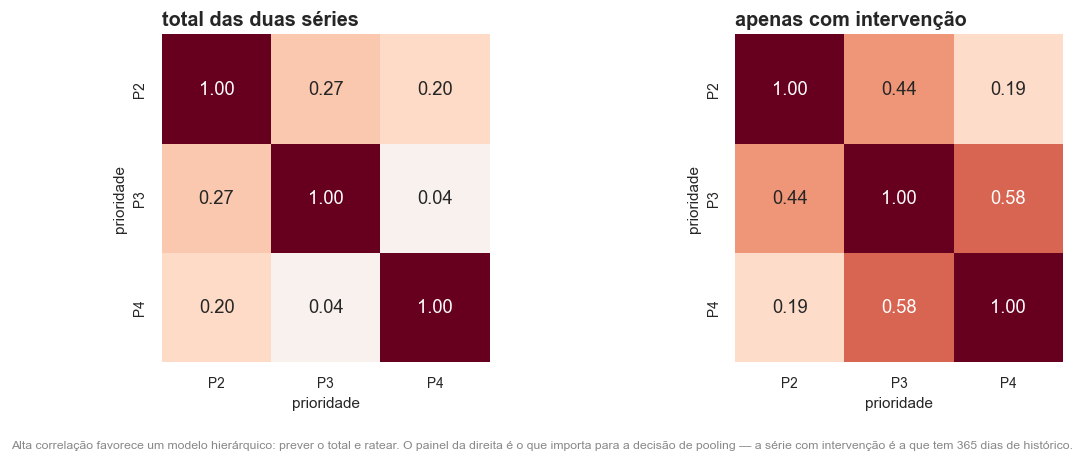

In [45]:
# As três prioridades se movem juntas? Se a correlação for alta, um modelo do total + rateio
# pode render mais que modelos independentes, dado o histórico curto.
# `pivot_table` com aggfunc="sum" e não `pivot`: no grão atual há duas linhas por (data,
# prioridade) — uma por tipo de tratamento — e `pivot` levantaria erro de índice duplicado.
fig, axes = novo_grafico("Correlação entre prioridades (Spearman, apenas R3)",
                         figsize=(11, 4), ncols=2)

for ax, (rotulo, filtro) in zip(axes, [
    ("total das duas séries", "regime == 3"),
    ("apenas com intervenção", "regime == 3 and tipo_tratamento == 'com_intervencao'"),
]):
    largo_p = (
        fato_diario_prioridade.query(filtro)
        .pivot_table(index="data", columns="prioridade", values="abertos", aggfunc="sum")
        .rename(columns=lambda p: f"P{p}")
    )
    sns.heatmap(largo_p.corr(method="spearman"), annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, vmin=-1, vmax=1, square=True, cbar=False, ax=ax)
    ax.set_title(rotulo)

finalizar(fig, "Alta correlação favorece um modelo hierárquico: prever o total e ratear. O painel "
               "da direita é o que importa para a decisão de pooling — a série com intervenção é "
               "a que tem 365 dias de histórico.")

## 3.5 Grupo designado

A pergunta que orienta a seção é a que você formulou: **por que cada incidente vai para cada
time?** As quatro respostas parciais estão em ranking, especialização, cobertura horária e
resposta à quebra.

In [46]:
resumo_times = (
    dim_time_regime.groupby("time", observed=True)
    .agg(
        incidentes=("incidentes", "sum"),
        primeira_data=("primeira_data", "min"),
        ultima_data=("ultima_data", "max"),
        regimes_ativos=("regime", "nunique"),
    )
    .reset_index()
    .sort_values("incidentes", ascending=False)
)
resumo_times["pct_total"] = resumo_times["incidentes"] / resumo_times["incidentes"].sum() * 100
resumo_times["pct_acumulado"] = resumo_times["pct_total"].cumsum()
resumo_times["dias_desde_ultimo"] = (df["data"].max() - resumo_times["ultima_data"]).dt.days
resumo_times["situacao"] = np.select(
    [resumo_times["incidentes"] < 50,
     resumo_times["dias_desde_ultimo"] > 60,
     resumo_times["pct_total"] >= 1],
    ["residual", "inativo", "relevante"], default="marginal",
)

print(f"Grupos distintos na base : {resumo_times['time'].nunique()}")
print(resumo_times["situacao"].value_counts().to_string())
print()
print(f"Times que somam 99% do volume: "
      f"{(resumo_times['pct_acumulado'] < 99).sum() + 1}")
resumo_times

Grupos distintos na base : 17
situacao
marginal     10
relevante     6
residual      1

Times que somam 99% do volume: 10


,time,incidentes,primeira_data,ultima_data,regimes_ativos,pct_total,pct_acumulado,dias_desde_ultimo,situacao
13,Team14,92775,2023-01-09,2025-12-31,3,75.71,75.71,0,relevante
10,Team11,9790,2023-01-11,2025-12-30,3,7.99,83.70,1,relevante
4,Team05,9276,2023-01-30,2025-12-30,3,7.57,91.27,1,relevante
8,Team09,3425,2023-02-09,2025-12-31,3,2.79,94.06,0,relevante
11,Team12,2173,2024-03-19,2025-12-31,3,1.77,95.83,0,relevante
2,Team03,1306,2024-11-19,2025-12-31,3,1.07,96.90,0,relevante
9,Team10,1172,2024-12-24,2025-12-31,3,0.96,97.86,0,marginal
16,Team17,743,2023-05-20,2025-12-26,3,0.61,98.46,5,marginal
1,Team02,579,2023-08-30,2025-12-30,3,0.47,98.94,1,marginal
0,Team01,306,2024-12-29,2025-12-26,3,0.25,99.19,5,marginal


Alguns grupos são residuais
(Team13 com 1 incidente, Team06 com 50) ou pararam de receber incidentes.

Para a modelagem, o número que importa é outro: **quantos times realmente movem o volume**. A
coluna `pct_acumulado` responde isso — e a resposta é bem menos que 14.

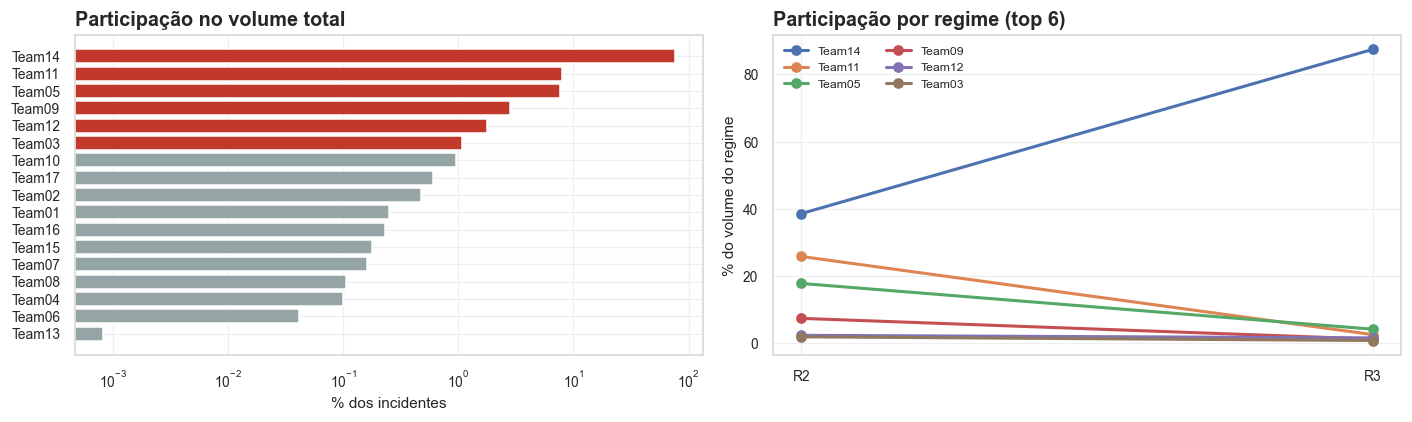

In [47]:
top_times = resumo_times.head(6)["time"].tolist()

fig, axes = novo_grafico("Concentração e evolução da carga entre times", figsize=(13, 4), ncols=2)

axes[0].barh(resumo_times["time"][::-1], resumo_times["pct_total"][::-1],
             color=[PALETA["p2"] if t in top_times else PALETA["neutro"]
                    for t in resumo_times["time"][::-1]])
axes[0].set_title("Participação no volume total")
axes[0].set_xlabel("% dos incidentes")
axes[0].set_xscale("log")

share = dim_time_regime[dim_time_regime["regime"].isin(REGIME_MODELAVEL)]
for t in top_times:
    sub = share[share["time"] == t].sort_values("regime")
    axes[1].plot([f"R{r}" for r in sub["regime"]], sub["share_regime"], marker="o", lw=2, label=t)
axes[1].set_title("Participação por regime (top 6)")
axes[1].set_ylabel("% do volume do regime")
axes[1].legend(fontsize=8, ncol=2)
finalizar(fig)

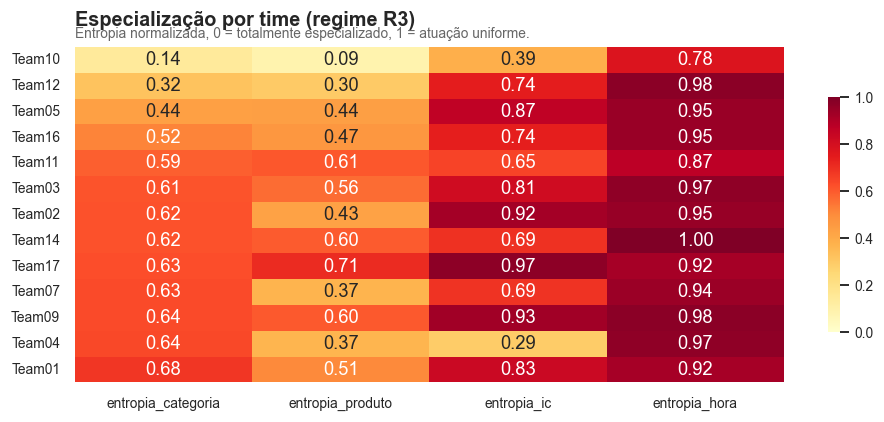

In [48]:
# Especialização: entropia baixa = o time atende poucas categorias; alta = generalista.
esp = (
    dim_time_regime.query("regime == 3 and incidentes >= 50")
    .set_index("time")[["entropia_categoria", "entropia_produto", "entropia_ic", "entropia_hora"]]
    .sort_values("entropia_categoria")
    .astype(float)
)

fig, ax = novo_grafico(
    "Especialização por time (regime R3)",
    "Entropia normalizada, 0 = totalmente especializado, 1 = atuação uniforme.",
    figsize=(9, 4),
)
sns.heatmap(esp, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_ylabel("")
finalizar(fig)

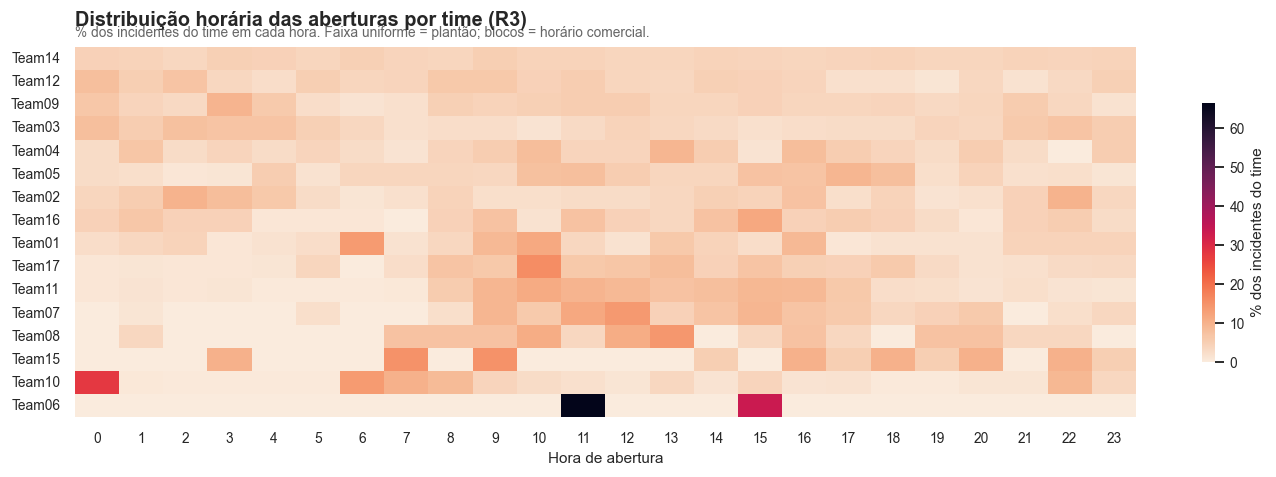

,horas_cobertas,pct_madrugada_0a6,pct_comercial_8a18,uniformidade
Grupo designado,,,,
Team03,24,39.30,29.60,0.53
Team10,24,30.00,31.10,-0.48
Team02,24,35.60,40.20,0.41
Team15,11,10.00,45.00,-0.26
Team14,24,25.40,45.60,0.91
Team12,24,30.80,46.90,0.61
Team09,24,31.00,47.90,0.60
Team01,24,15.50,52.60,0.21
Team04,23,22.40,57.90,0.47


In [49]:
# Cobertura horária: quem é plantão 24x7 e quem é horário comercial.
hora_time = (
    df.query("regime == 3")
    .groupby(["Grupo designado", "hora_abertura"], observed=True).size()
    .rename("inc").reset_index()
)
hora_time["pct"] = (
    hora_time["inc"] / hora_time.groupby("Grupo designado")["inc"].transform("sum") * 100
)
mapa_hora = hora_time.pivot(index="Grupo designado", columns="hora_abertura", values="pct")
mapa_hora = mapa_hora.loc[mapa_hora.index.isin(resumo_times.query("incidentes >= 50")["time"])]
mapa_hora = mapa_hora.reindex(columns=range(24)).fillna(0)
mapa_hora = mapa_hora.loc[mapa_hora.std(axis=1).sort_values().index]

fig, ax = novo_grafico(
    "Distribuição horária das aberturas por time (R3)",
    "% dos incidentes do time em cada hora. Faixa uniforme = plantão; blocos = horário comercial.",
    figsize=(13, 4.5),
)
sns.heatmap(mapa_hora, cmap="rocket_r", cbar_kws={"label": "% dos incidentes do time", "shrink": 0.7}, ax=ax)
ax.set_xlabel("Hora de abertura")
ax.set_ylabel("")
finalizar(fig)

pd.DataFrame({
    "horas_cobertas": (mapa_hora > 0).sum(axis=1),
    "pct_madrugada_0a6": mapa_hora.loc[:, 0:5].sum(axis=1).round(1),
    "pct_comercial_8a18": mapa_hora.loc[:, 8:18].sum(axis=1).round(1),
    "uniformidade": (1 - mapa_hora.std(axis=1) / mapa_hora.mean(axis=1)).round(2),
}).sort_values("pct_comercial_8a18")

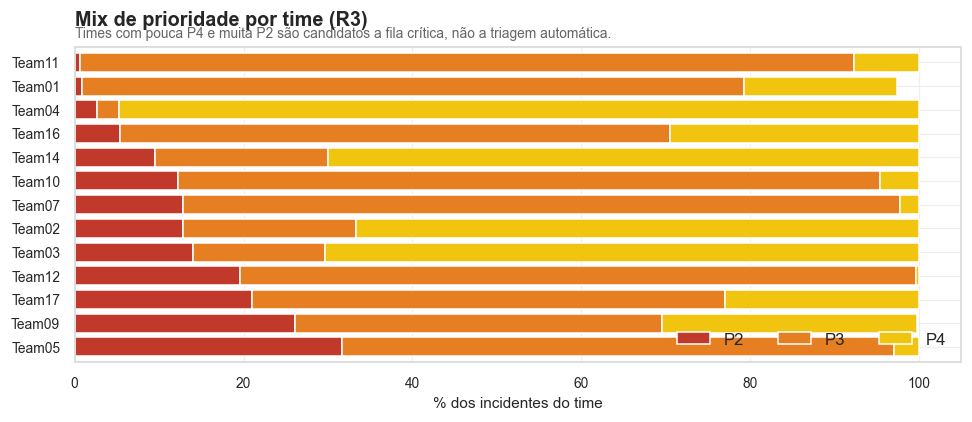

,P2,P3,P4
time,,,
Team05,31.60,65.40,3.00
Team09,26.00,43.50,30.20
Team17,21.00,56.00,23.00
Team12,19.50,80.10,0.30
Team03,14.00,15.70,70.40
Team02,12.90,20.50,66.70
Team07,12.80,84.90,2.30
Team10,12.30,83.00,4.70
Team14,9.50,20.50,70.00


In [50]:
# Mix de prioridade por time — os times atendem as mesmas prioridades?
mix_time = (
    dim_time_regime.query("regime == 3 and incidentes >= 50")
    .set_index("time")[[f"pct_p{p}" for p in PRIORIDADES_ALVO]]
    .rename(columns=lambda c: c.upper().replace("PCT_", ""))
)
mix_time = mix_time.loc[mix_time["P2"].sort_values(ascending=False).index]

fig, ax = novo_grafico(
    "Mix de prioridade por time (R3)",
    "Times com pouca P4 e muita P2 são candidatos a fila crítica, não a triagem automática.",
    figsize=(9, 4),
)
mix_time.plot(kind="barh", stacked=True, ax=ax,
              color=[COR_PRIORIDADE[p] for p in PRIORIDADES_ALVO], width=0.8)
ax.set_xlabel("% dos incidentes do time")
ax.set_ylabel("")
ax.legend(title="", ncol=3, loc="lower right")
finalizar(fig)
mix_time.round(1)

In [51]:
def correlacao_defasada(serie_x, serie_y, defasagens=range(0, 8)):
    """Correlação de Spearman de x(t-k) contra y(t). k>0 => x antecede y."""
    return pd.DataFrame([
        {"defasagem": k, "correlacao": serie_x.shift(k).corr(serie_y, method="spearman")}
        for k in defasagens
    ])


# Algum time funciona como indicador antecedente do volume de P2/P3?
alvo_p2p3 = (
    fato_diario_prioridade.query("regime == 3 and prioridade in [2, 3]")
    .groupby("data", observed=True)["abertos"].sum()
)
lead = []
for t in resumo_times.query("incidentes >= 200")["time"]:
    s = (
        fato_diario_time.query("regime == 3 and time == @t")
        .set_index("data")["abertos"].reindex(alvo_p2p3.index).fillna(0)
    )
    c = correlacao_defasada(s, alvo_p2p3)
    melhor = c.loc[c["correlacao"].abs().idxmax()]
    lead.append({"time": t, "melhor_defasagem": int(melhor["defasagem"]),
                 "correlacao": round(melhor["correlacao"], 3),
                 "correlacao_lag0": round(c.loc[0, "correlacao"], 3)})

pd.DataFrame(lead).sort_values("correlacao", key=abs, ascending=False)

,time,melhor_defasagem,correlacao,correlacao_lag0
0,Team14,0,0.64,0.64
1,Team11,4,-0.40,0.29
2,Team05,0,0.37,0.37
3,Team09,0,0.33,0.33
10,Team16,5,-0.26,-0.03
6,Team10,0,0.24,0.24
4,Team12,3,-0.23,0.01
5,Team03,2,0.22,0.21
8,Team02,7,0.20,0.05
7,Team17,7,0.19,0.10


**Leitura para a modelagem.** Se algum time apresenta correlação máxima em defasagem ≥ 1, a série
dele é candidata a feature antecedente — o que é mais útil que a correlação contemporânea, já que
esta última não está disponível no momento da previsão. Times cuja melhor defasagem é 0 são
apenas espelho do volume total e não acrescentam informação.

## 3.6 Item de configuração

O achado central se sustenta e vale repetir com o número: **em R3, 17 % dos ICs ativos concentram
89 % dos incidentes.** Uma feature baseada na média da base inteira descreveria um IC que não
existe. O que carrega sinal é a cauda.

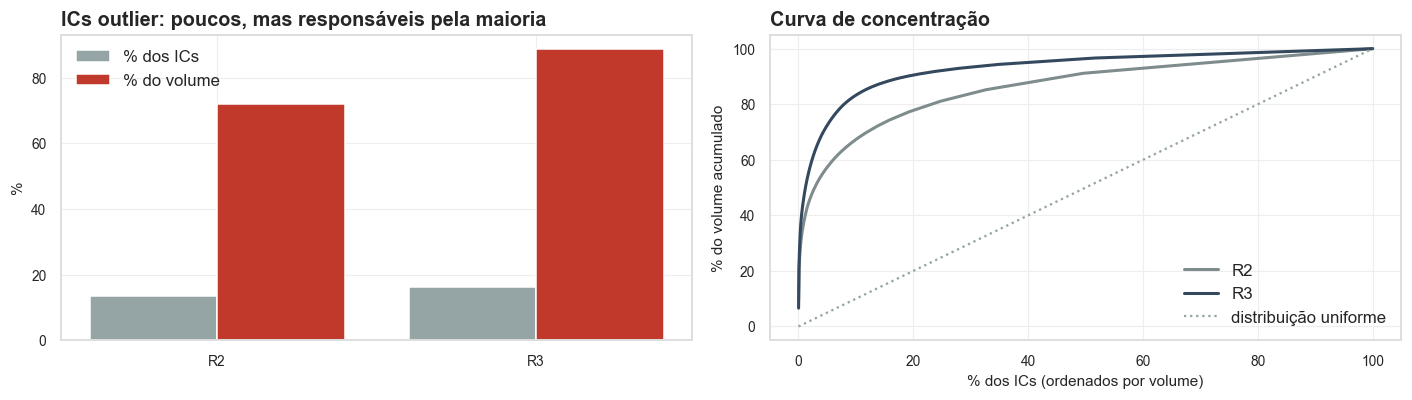

,regime,ics_ativos,limite_outlier,ics_outliers,pct_ics_outliers,pct_volume_outliers
0,R2,4972,6.00,671,13.50,71.88
1,R3,6392,8.50,1031,16.13,88.65


In [52]:
conc = []
for r in REGIME_MODELAVEL:
    sub = dim_ic_regime.query("regime == @r and incidentes > 0")
    li, ls = limites_iqr(sub["incidentes"])
    outliers = sub[sub["incidentes"] > ls]
    conc.append({
        "regime": f"R{r}",
        "ics_ativos": len(sub),
        "limite_outlier": ls,
        "ics_outliers": len(outliers),
        "pct_ics_outliers": len(outliers) / len(sub) * 100,
        "pct_volume_outliers": outliers["incidentes"].sum() / sub["incidentes"].sum() * 100,
    })
conc = pd.DataFrame(conc)

fig, axes = novo_grafico("Concentração do volume em poucos ICs", figsize=(13, 3.8), ncols=2)

x = np.arange(len(conc))
axes[0].bar(x - 0.2, conc["pct_ics_outliers"], 0.4, color=PALETA["neutro"], label="% dos ICs")
axes[0].bar(x + 0.2, conc["pct_volume_outliers"], 0.4, color=PALETA["p2"], label="% do volume")
axes[0].set_xticks(x, conc["regime"])
axes[0].set_title("ICs outlier: poucos, mas responsáveis pela maioria")
axes[0].set_ylabel("%")
axes[0].legend()

for r, cor in [(2, PALETA["r2"]), (3, PALETA["r3"])]:
    sub = dim_ic_regime.query("regime == @r and incidentes > 0").sort_values("incidentes", ascending=False)
    cum = sub["incidentes"].cumsum() / sub["incidentes"].sum() * 100
    axes[1].plot(np.arange(1, len(sub) + 1) / len(sub) * 100, cum, lw=2, color=cor, label=f"R{r}")
axes[1].plot([0, 100], [0, 100], ls=":", color=PALETA["neutro"], label="distribuição uniforme")
axes[1].set_title("Curva de concentração")
axes[1].set_xlabel("% dos ICs (ordenados por volume)")
axes[1].set_ylabel("% do volume acumulado")
axes[1].legend()
finalizar(fig)

conc.round(2)

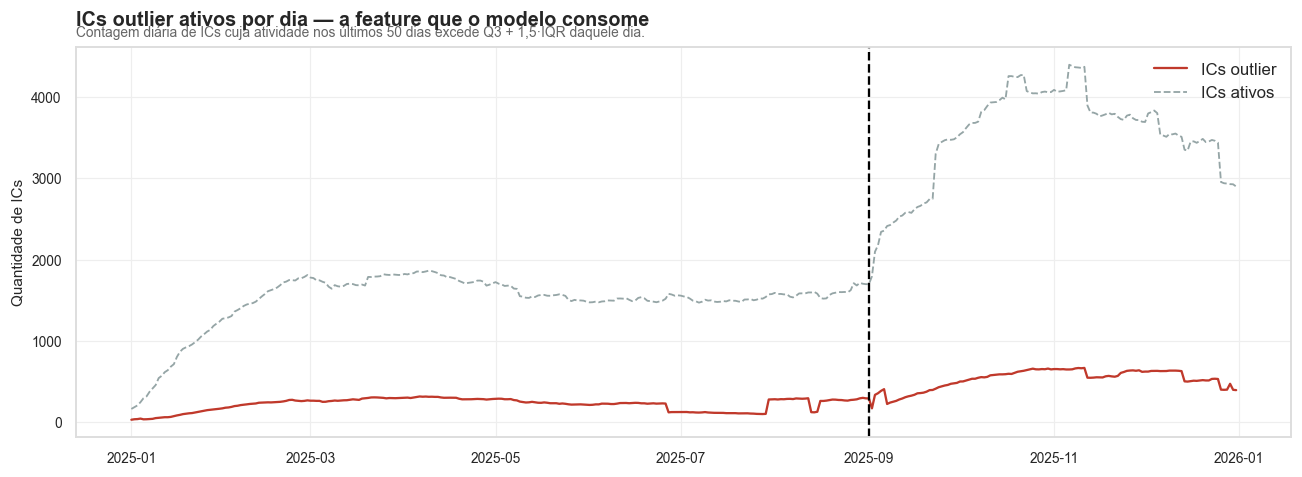

,ics,pct
jornada_monitoramento,,
Monitorado nativo novo,3510,38.30
Monitorado nativo antigo,2793,30.50
Sempre manual,2095,22.80
Migrado no R3,618,6.70
Regrediu para manual,116,1.30
Migrado no R2,32,0.30
Oscilante (termina monitorado),7,0.10


In [53]:
fig, ax = novo_grafico(
    "ICs outlier ativos por dia — a feature que o modelo consome",
    "Contagem diária de ICs cuja atividade nos últimos 50 dias excede Q3 + 1,5·IQR daquele dia.",
)
sub = ft_ic[ft_ic["data"] >= Q_R2]
ax.plot(sub["data"], sub["ics_outliers"], color=PALETA["p2"], lw=1.5, label="ICs outlier")
ax.plot(sub["data"], sub["ics_ativos"], color=PALETA["neutro"], lw=1.2, ls="--", label="ICs ativos")
ax.axvline(Q_R3, color="black", ls="--", lw=1.5)
ax.set_ylabel("Quantidade de ICs")
ax.legend()
finalizar(fig)

dim_ic["jornada_monitoramento"].value_counts().rename("ics").to_frame().assign(
    pct=lambda d: (d["ics"] / d["ics"].sum() * 100).round(1)
)

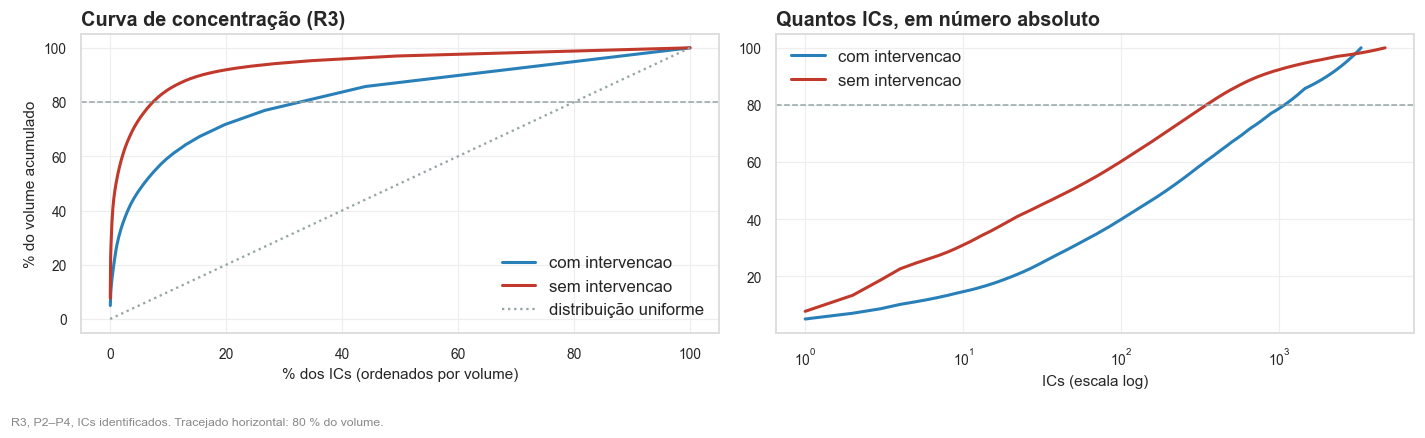

tipo_tratamento  incidentes  distintos  n_para_80pct  pct_dos_distintos
com_intervencao       13007       3315          1085              32.73
sem_intervencao       78733       4701           348               7.40

Sobreposição entre os dois conjuntos de ICs que cobrem 80 % de cada série:
  n_top80_com                                1,085
  n_top80_sem                                348
  n_interseccao                              203
  jaccard                                    0.17
  pct_volume_com_intervencao_na_interseccao  20.52
  pct_volume_sem_intervencao_na_interseccao  51.90


In [54]:
# A pergunta do recorte por tipo: quantos ICs geram a série SEM intervenção? Se 80 % do
# volume vier de poucas dezenas, a série é o comportamento de um punhado de alertas — e a
# feature certa é o estado desses ICs específicos, não um agregado da base inteira.
COBERTURA_CONCENTRACAO = 0.80


def concentracao_por_tipo(base, coluna, cobertura=COBERTURA_CONCENTRACAO):
    """
    Quantas entidades de `coluna` cobrem `cobertura` do volume de cada tipo de tratamento,
    e o quanto os dois conjuntos se sobrepõem.

    Devolve (tabela por tipo, dicionário de sobreposição). A sobreposição é medida de duas
    formas porque elas respondem a coisas diferentes: Jaccard diz se as *populações* são as
    mesmas; o % de volume diz se a interseção é o que de fato move cada série.
    """
    alvo = int(cobertura * 100)
    linhas, conjuntos = [], {}
    for tipo in TIPOS_TRATAMENTO:
        v = base.loc[base["tipo_tratamento"] == tipo, coluna].value_counts()
        if v.empty:
            continue
        acum = v.cumsum() / v.sum()
        n = int((acum < cobertura).sum() + 1)
        conjuntos[tipo] = set(v.index[:n])
        linhas.append({
            "tipo_tratamento": tipo,
            "incidentes": int(v.sum()),
            "distintos": len(v),
            f"n_para_{alvo}pct": n,
            "pct_dos_distintos": n / len(v) * 100,
        })

    a = conjuntos.get(TIPOS_TRATAMENTO[0], set())
    b = conjuntos.get(TIPOS_TRATAMENTO[1], set())
    uniao = a | b
    inter = a & b
    sobreposicao = {
        f"n_top{alvo}_com": len(a),
        f"n_top{alvo}_sem": len(b),
        "n_interseccao": len(inter),
        "jaccard": len(inter) / len(uniao) if uniao else np.nan,
    }
    for tipo in TIPOS_TRATAMENTO:
        fatia = base[base["tipo_tratamento"] == tipo]
        sobreposicao[f"pct_volume_{tipo}_na_interseccao"] = (
            fatia[coluna].isin(inter).mean() * 100 if len(fatia) else np.nan
        )
    return pd.DataFrame(linhas), sobreposicao


base_r3 = df.query("regime == 3 and prioridade in @PRIORIDADES_ALVO and ic != 'SEM_IC'")
conc_ic, sobrep_ic = concentracao_por_tipo(base_r3, "ic")

fig, axes = novo_grafico("Concentração por item de configuração, por tipo de tratamento",
                         figsize=(13, 3.8), ncols=2)
for tipo in TIPOS_TRATAMENTO:
    v = base_r3.loc[base_r3["tipo_tratamento"] == tipo, "ic"].value_counts()
    cum = v.cumsum() / v.sum() * 100
    axes[0].plot(np.arange(1, len(v) + 1) / len(v) * 100, cum, lw=2,
                 color=COR_TIPO[tipo], label=tipo.replace("_", " "))
    axes[1].plot(np.arange(1, len(v) + 1), cum, lw=2, color=COR_TIPO[tipo],
                 label=tipo.replace("_", " "))
axes[0].plot([0, 100], [0, 100], ls=":", color=PALETA["neutro"], label="distribuição uniforme")
axes[0].axhline(COBERTURA_CONCENTRACAO * 100, color=PALETA["neutro"], ls="--", lw=1)
axes[0].set_title("Curva de concentração (R3)")
axes[0].set_xlabel("% dos ICs (ordenados por volume)")
axes[0].set_ylabel("% do volume acumulado")
axes[0].legend()
axes[1].set_xscale("log")
axes[1].axhline(COBERTURA_CONCENTRACAO * 100, color=PALETA["neutro"], ls="--", lw=1)
axes[1].set_title("Quantos ICs, em número absoluto")
axes[1].set_xlabel("ICs (escala log)")
axes[1].legend()
finalizar(fig, "R3, P2–P4, ICs identificados. Tracejado horizontal: 80 % do volume.")

print(conc_ic.round(2).to_string(index=False))
print("\nSobreposição entre os dois conjuntos de ICs que cobrem 80 % de cada série:")
for k, v in sobrep_ic.items():
    print(f"  {k:<42} {v:,.2f}" if isinstance(v, float) else f"  {k:<42} {v:,}")

**Leitura.** Em R3, a série sem intervenção sai de **348 ICs** (7,4 % dos que ela toca) e a série
com intervenção precisa de **1.085** (33 %) para chegar aos mesmos 80 %. Não é só volume maior: é
volume mais concentrado, o que é a assinatura de um conjunto fixo de alertas configurados.

A sobreposição diz o resto. Jaccard de **0,17** entre os dois conjuntos — populações
majoritariamente distintas. E a assimetria é informativa: os 203 ICs em comum respondem por
**52 % do volume sem intervenção** contra **21 % do volume com intervenção**. Ou seja, os ICs que
disparam alerta automático são em boa parte os mesmos que geram chamado tratado, mas o contrário
não vale — a maior parte da carga humana vem de ICs que o monitoramento automático não toca.

Para a modelagem: a feature útil na série sem intervenção é o **estado daqueles 348 ICs**, não uma
média da base inteira. Na série com intervenção a cauda é longa e agregados amplos fazem mais
sentido.

In [55]:
# Os 63% de nulo em Produto/Categoria/Subcategoria são aleatórios?
nulos = (
    df.groupby(["regime", "sem_classificacao"], observed=True)
    .agg(incidentes=("Número", "size"),
         pct_monitoramento=("aberto_por_monitoramento", lambda s: s.mean() * 100),
         pct_sem_intervencao=("sem_intervencao", lambda s: s.mean() * 100),
         duracao_mediana_h=("duracao_horas", "median"))
    .reset_index()
)
nulos["pct_do_regime"] = (
    nulos["incidentes"] / nulos.groupby("regime")["incidentes"].transform("sum") * 100
)
nulos.round(2)

,regime,sem_classificacao,incidentes,pct_monitoramento,pct_sem_intervencao,duracao_mediana_h,pct_do_regime
0,1,0,732,26.37,0.41,"4,186.91",100.00
1,2,0,27394,53.26,0.04,1.52,96.50
2,2,1,994,100.00,7.04,1.99,3.50
3,3,0,16700,70.66,27.45,1.24,17.88
4,3,1,76723,100.00,98.67,0.09,82.12


Se `sem_classificacao = 1` concentrar aberturas por monitoramento e duração muito curta, então a
ausência de `Produto`/`Categoria`/`Subcategoria` é **estrutural**: o pipeline automático não
preenche esses campos. Nesse caso as três colunas não são candidatas a feature do modelo diário —
elas só descrevem o subconjunto manual. O que sobrevive é a *própria flag de ausência*, já
disponível como `abertos_sem_classificacao`.

## 3.7 Descrição Resumida
Verificação da hipótese de origem: se o texto vem de template de alerta, a normalização deve
colapsar muito e a cobertura deve concentrar-se em poucos templates.

In [56]:
top = dim_template.head(20)[
    ["template_descricao", "incidentes", "pct_volume", "pct_acumulado",
     "prioridade_dominante", "pct_monitorado", "duracao_mediana_h", "time_principal", "cluster"]
].copy()
top["template_descricao"] = top["template_descricao"].str.slice(0, 70)
top

,template_descricao,incidentes,pct_volume,pct_acumulado,prioridade_dominante,pct_monitorado,duracao_mediana_h,time_principal,cluster
0,problem: check application monitoring,28728,23.44,23.44,4,100.00,0.01,Team14,0
1,problem: disk i/o is overloaded on <NOME_NUM>,7444,6.07,29.52,3,100.00,0.15,Team14,2
2,problem: free disk space is less than <NUM>% o...,5285,4.31,33.83,4,100.00,1.37,Team14,1
3,problem: check application monitoring vip,4281,3.49,37.32,4,100.00,0.07,Team14,0
4,problem: unavailable by icmp ping,4133,3.37,40.70,2,100.00,0.58,Team14,3
5,problem: apache busy workers,3925,3.20,43.90,3,100.00,0.09,Team14,3
6,problem: lack of free swap space 40m <<NUM>%,3255,2.66,46.56,4,100.00,0.81,Team14,1
7,problem: processor load is too high p3,2174,1.77,48.33,3,100.00,0.37,Team14,3
8,problem: high bandwidth ><NUM>% at least 15m,1874,1.53,49.86,4,100.00,0.05,Team14,3
9,problem: error backup full bacula,1689,1.38,51.24,3,100.00,3.24,Team14,3


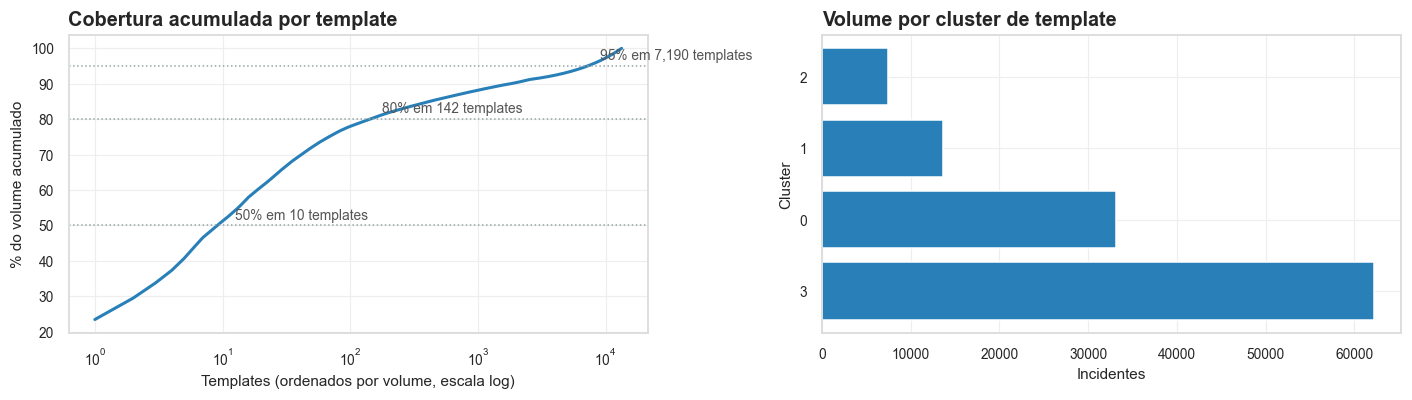

,templates,incidentes
cluster,,
3,7118,62186
0,24,33149
1,44,13624
2,3,7456


In [57]:
fig, axes = novo_grafico("Estrutura da coluna Descrição Resumida", figsize=(13, 3.8), ncols=2)

cob = dim_template["pct_volume"].cumsum()
axes[0].plot(np.arange(1, len(cob) + 1), cob, color=PALETA["destaque"], lw=2)
for alvo in (50, 80, 95):
    n = int((cob < alvo).sum() + 1)
    axes[0].axhline(alvo, color=PALETA["neutro"], ls=":", lw=1)
    axes[0].annotate(f"{alvo}% em {n:,} templates", (n, alvo), textcoords="offset points",
                     xytext=(8, 4), fontsize=9, color="#555555")
axes[0].set_xscale("log")
axes[0].set_title("Cobertura acumulada por template")
axes[0].set_xlabel("Templates (ordenados por volume, escala log)")
axes[0].set_ylabel("% do volume acumulado")

perfil_cluster = (
    dim_template.query("cluster >= 0")
    .groupby("cluster", observed=True)
    .agg(templates=("template_descricao", "size"), incidentes=("incidentes", "sum"))
    .sort_values("incidentes", ascending=False)
)
axes[1].barh(perfil_cluster.index.astype(str), perfil_cluster["incidentes"], color=PALETA["destaque"])
axes[1].set_title("Volume por cluster de template")
axes[1].set_xlabel("Incidentes")
axes[1].set_ylabel("Cluster")
finalizar(fig)

perfil_cluster

In [58]:
# Exemplos por cluster — a leitura qualitativa que decide se o agrupamento tem sentido.
for c in perfil_cluster.index[:6]:
    sub = dim_template.query("cluster == @c").nlargest(3, "incidentes")
    print(f"--- cluster {c} | {perfil_cluster.loc[c, 'incidentes']:,} incidentes "
          f"| {perfil_cluster.loc[c, 'templates']} templates ---")
    for _, l in sub.iterrows():
        print(f"    [{l['incidentes']:>6,}] P{l['prioridade_dominante']} {l['template_descricao'][:88]}")
    print()

--- cluster 3 | 62,186 incidentes | 7118 templates ---
    [ 4,133] P2 problem: unavailable by icmp ping
    [ 3,925] P3 problem: apache busy workers
    [ 2,174] P3 problem: processor load is too high p3

--- cluster 0 | 33,149 incidentes | 24 templates ---
    [28,728] P4 problem: check application monitoring
    [ 4,281] P4 problem: check application monitoring vip
    [    20] P3 problem: check application monitoring on saasworker

--- cluster 1 | 13,624 incidentes | 44 templates ---
    [ 5,285] P4 problem: free disk space is less than <NUM>% on volume /
    [ 3,255] P4 problem: lack of free swap space 40m <<NUM>%
    [   977] P4 problem: /: free disk space is less than <NUM>

--- cluster 2 | 7,456 incidentes | 3 templates ---
    [ 7,444] P3 problem: disk i/o is overloaded on <NOME_NUM>
    [     8] P4 problem: disk i/o is overloaded on ic01488ic04172mirrorsic04172locawebic04172comic04172b
    [     4] P4 problem: disk i/o is overloaded on ic02568ic04172hospedagemic04172locawebic

In [59]:
# Quais classes são novas em R3? Se o salto vier de tipos de alerta inéditos, é confirmação
# de mudança de instrumentação — e não de mais problemas nos mesmos lugares.
por_classe = (
    fato_diario_classe.merge(fato_diario[["data", "regime"]].drop_duplicates(), on="data",
                             how="left", suffixes=("", "_dia"))
    .groupby(["classe_descricao", "regime"], observed=True)["abertos"].sum()
    .unstack("regime", fill_value=0)
    .rename(columns=lambda r: f"R{r}")
)
for c in ("R1", "R2", "R3"):
    if c not in por_classe.columns:
        por_classe[c] = 0
por_classe["pct_r2"] = por_classe["R2"] / por_classe["R2"].sum() * 100
por_classe["pct_r3"] = por_classe["R3"] / por_classe["R3"].sum() * 100
por_classe["delta_pp"] = (por_classe["pct_r3"] - por_classe["pct_r2"]).round(2)
por_classe["nova_em_r3"] = ((por_classe["R2"] == 0) & (por_classe["R3"] > 0)).astype(int)

resultado = por_classe.sort_values("delta_pp", ascending=False)
print(f"Classes que só existem em R3: {int(resultado['nova_em_r3'].sum())} "
      f"({resultado.loc[resultado['nova_em_r3'] == 1, 'R3'].sum():,} incidentes)")
resultado.head(12).round(2)

Classes que só existem em R3: 0 (0 incidentes)


regime,R1,R2,R3,pct_r2,pct_r3,delta_pp,nova_em_r3
classe_descricao,,,,,,,
erro_aplicacao,142,4333,32814,15.43,35.13,19.70,0
infraestrutura_rede,109,2698,18915,9.61,20.25,10.64,0
performance_degradada,18,1016,13135,3.62,14.06,10.44,0
banco_de_dados,9,697,2600,2.48,2.78,0.30,0
disponibilidade_servico,62,4777,13670,17.01,14.64,-2.38,0
certificado_seguranca,33,1264,684,4.50,0.73,-3.77,0
backup_replicacao,17,1777,1709,6.33,1.83,-4.50,0
outros,53,1438,480,5.12,0.51,-4.61,0
job_processamento,9,2145,2219,7.64,2.38,-5.26,0


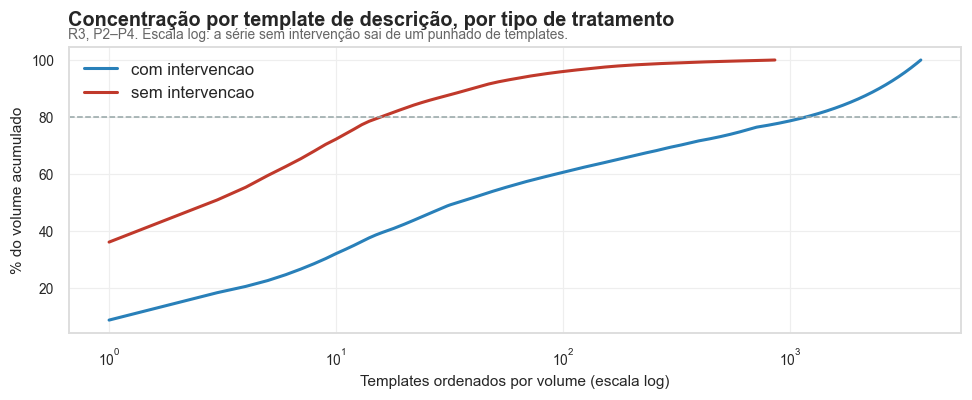

tipo_tratamento  incidentes  distintos  n_para_80pct  pct_dos_distintos
com_intervencao       13007       3776          1175              31.12
sem_intervencao       78733        859            16               1.86

Sobreposição entre os dois conjuntos de templates que cobrem 80 % de cada série:
  n_top80_com                                    1,175
  n_top80_sem                                    16
  n_interseccao                                  12
  jaccard                                        0.01
  pct_volume_com_intervencao_na_interseccao      19.01
  pct_volume_sem_intervencao_na_interseccao      69.75

Top 5 templates de cada série (R3):

  --- com_intervencao (13,007 incidentes) ---
    [ 1,149] problem: free disk space is less than <NUM>% on volume /
    [   787] problem: unavailable by icmp ping
    [   464] problem: check <PATH> doesn't change more then <MEDIDA>
    [   284] problem: check: nginx type: tcp on port: <NUM> not running
    [   267] problem: <NOME_NUM> agen

In [60]:
# Mesma pergunta na outra dimensão: quantos TEMPLATES de alerta geram cada série?
# `concentracao_por_tipo()` é a função de §3.6 — a única coisa que muda é a coluna.
conc_tpl, sobrep_tpl = concentracao_por_tipo(base_r3, "template_descricao")

fig, ax = novo_grafico(
    "Concentração por template de descrição, por tipo de tratamento",
    "R3, P2–P4. Escala log: a série sem intervenção sai de um punhado de templates.",
    figsize=(9, 3.8),
)
for tipo in TIPOS_TRATAMENTO:
    v = base_r3.loc[base_r3["tipo_tratamento"] == tipo, "template_descricao"].value_counts()
    ax.plot(np.arange(1, len(v) + 1), v.cumsum() / v.sum() * 100, lw=2,
            color=COR_TIPO[tipo], label=tipo.replace("_", " "))
ax.axhline(COBERTURA_CONCENTRACAO * 100, color=PALETA["neutro"], ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("Templates ordenados por volume (escala log)")
ax.set_ylabel("% do volume acumulado")
ax.legend()
finalizar(fig)

print(conc_tpl.round(2).to_string(index=False))
print("\nSobreposição entre os dois conjuntos de templates que cobrem 80 % de cada série:")
for k, v in sobrep_tpl.items():
    print(f"  {k:<46} {v:,.2f}" if isinstance(v, float) else f"  {k:<46} {v:,}")

# Os templates de maior volume de cada série, lado a lado — a leitura qualitativa que diz
# se são de fato dois fenômenos ou o mesmo alerta com dois desfechos.
print("\nTop 5 templates de cada série (R3):")
for tipo in TIPOS_TRATAMENTO:
    v = base_r3.loc[base_r3["tipo_tratamento"] == tipo, "template_descricao"].value_counts()
    print(f"\n  --- {tipo} ({int(v.sum()):,} incidentes) ---")
    for tpl, n in v.head(5).items():
        print(f"    [{n:>6,}] {str(tpl)[:86]}")

**Leitura — aqui a diferença é de outra ordem de grandeza.**

| | com intervenção | sem intervenção |
|---|---|---|
| Incidentes em R3 | 13.007 | 78.733 |
| Templates distintos | 3.776 | **859** |
| Templates para 80 % do volume | 1.175 (31 %) | **16 (1,9 %)** |
| Jaccard entre os dois conjuntos-80 % | \-\- | **0,01** |

**Dezesseis templates geram 80 % da série sem intervenção**, e um só — `problem: check
application monitoring` — responde por 28.481 dos 78.733 incidentes (36 %). Isso não é uma série
de incidentes: é o log de um punhado de checagens automáticas.

Os conjuntos são **essencialmente disjuntos** (Jaccard 0,01). Os 12 templates em comum carregam
70 % do volume sem intervenção mas só 19 % do volume com intervenção — mesma assimetria vista nos
ICs, e mais extrema.

Consequências práticas:

1. **A série sem intervenção é modelável em nível muito mais fino do que a agregada.** Com 16
   templates cobrindo 80 %, a série diária de cada um é uma feature específica, e provavelmente
   mais informativa que qualquer agregado da base.
2. **A rotulagem por LLM de §2.9 deve priorizar esses 16.** É barato e dá nome de negócio ao que
   hoje é "cluster 3".
3. **O que os dois lados compartilham é o alerta de infraestrutura básica** — disco, ping, I/O.
   Faz sentido: o mesmo sintoma às vezes fecha sozinho e às vezes vira chamado. Esse subconjunto
   é o único lugar onde a fração com/sem de §3.12 tem interpretação física direta.

## 3.8 Diagnóstico das séries alvo

Última parada antes da modelagem: entender a estrutura temporal do que se quer prever.

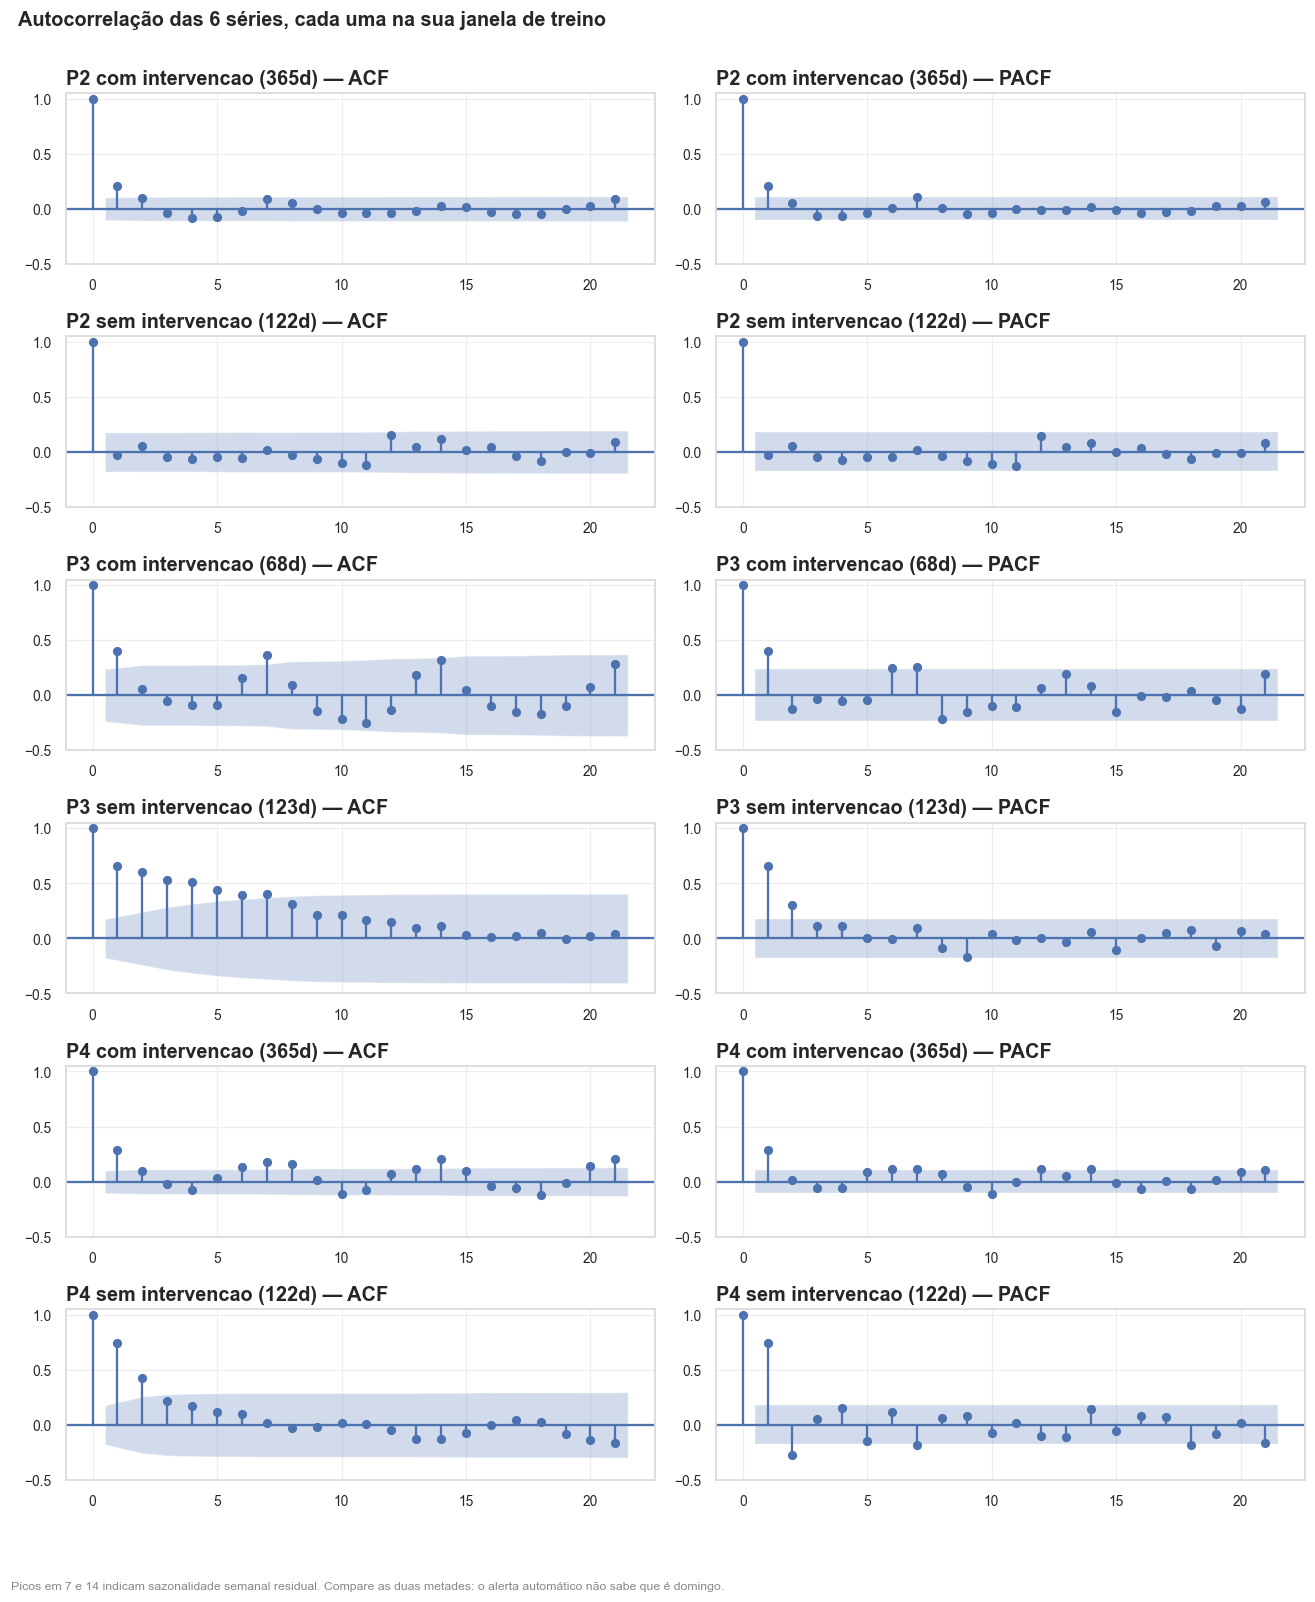

In [61]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

SERIES_ALVO = [(p, t) for p in PRIORIDADES_ALVO for t in TIPOS_TRATAMENTO]


def janela_de_treino(tabela, prioridade, tipo):
    """
    Recorta uma tabela na janela que §3.1 liberou para aquela série.

    Cada série tem a sua: usar R2 numa série que quebrou em setembro é treinar em outra
    distribuição, e restringir a R3 uma série que atravessou plana joga fora 245 dias.
    """
    inicio = JANELA_TREINO[(prioridade, tipo)]
    return (
        tabela.query("prioridade == @prioridade and tipo_tratamento == @tipo and data >= @inicio")
        .sort_values("data")
    )


fig, axes = plt.subplots(len(SERIES_ALVO), 2, figsize=(12, 2.3 * len(SERIES_ALVO)))
for i, (p, t) in enumerate(SERIES_ALVO):
    s = janela_de_treino(fato_diario_prioridade, p, t).set_index("data")["abertos"]
    rotulo = f"P{p} {t.replace('_', ' ')} ({len(s)}d)"
    plot_acf(s, lags=21, ax=axes[i, 0], title=f"{rotulo} — ACF")
    plot_pacf(s, lags=21, ax=axes[i, 1], method="ywm", title=f"{rotulo} — PACF")
    for ax in axes[i]:
        ax.set_ylim(-0.5, 1.05)
fig.suptitle("Autocorrelação das 6 séries, cada uma na sua janela de treino",
             y=1.0, fontsize=13, weight="bold", x=0.01, ha="left")
finalizar(fig, "Picos em 7 e 14 indicam sazonalidade semanal residual. Compare as duas metades: "
               "o alerta automático não sabe que é domingo.")

In [62]:
def ranquear_candidatas(tabela, coluna_alvo, excluir_prefixos=("y_",), minimo=0.05):
    """
    Correlação de Spearman entre cada candidata numérica e o alvo.

    Spearman e não Pearson: as contagens têm cauda pesada e a relação de interesse é monotônica,
    não linear. Isto é um filtro de triagem, não seleção de features — colunas correlacionadas
    entre si aparecem todas no topo.
    """
    base = tabela.dropna(subset=[coluna_alvo])
    numericas = base.select_dtypes(include=[np.number]).columns
    candidatas = [
        c for c in numericas
        if not c.startswith(excluir_prefixos) and c not in (coluna_alvo, "prioridade", "regime")
    ]
    linhas = []
    for c in candidatas:
        s = base[c]
        if s.nunique(dropna=True) < 3:
            continue
        r = s.corr(base[coluna_alvo], method="spearman")
        if pd.notna(r) and abs(r) >= minimo:
            linhas.append({"feature": c, "spearman": round(r, 3), "abs": abs(r)})
    return pd.DataFrame(linhas).sort_values("abs", ascending=False).drop(columns="abs")


for p, t in SERIES_ALVO:
    sub = janela_de_treino(tabela_modelo_longa, p, t)
    ranking = ranquear_candidatas(sub, "y_abertos_d1")
    inicio = JANELA_TREINO[(p, t)]
    print(f"\n=== P{p} {t} — top 15 candidatas para y_abertos_d1 "
          f"(desde {inicio:%d/%m/%Y}, {len(sub)} dias) ===")
    print(ranking.head(15).to_string(index=False))


=== P2 com_intervencao — top 15 candidatas para y_abertos_d1 (desde 01/01/2025, 365 dias) ===
              feature  spearman
           sen_semana      0.33
           cos_semana      0.27
        ics_distintos      0.27
 descricoes_distintas      0.26
  fechados_entrou_kpi      0.26
              abertos      0.25
abertos_hor_comercial      0.25
     times_ativos_dia      0.24
  times_com_incidente      0.24
             fechados      0.23
           dia_semana     -0.23
      fechados_manual      0.23
abertos_monitoramento      0.23
       abertos_manual      0.21
            ics_novos      0.20

=== P2 sem_intervencao — top 15 candidatas para y_abertos_d1 (desde 01/09/2025, 122 dias) ===
                 feature  spearman
              cos_semana      0.37
              sen_semana      0.26
        times_ativos_dia      0.25
     times_com_incidente      0.25
              dia_semana     -0.24
           abertos_lag_3     -0.23
           abertos_lag_2     -0.21
                 b

In [63]:
# Baselines. Nenhum modelo deve ser aceito sem bater estes números — e eles importam mais
# aqui do que antes: numa série estável de ~110/dia, a média móvel de 7 dias é um adversário
# difícil. Registrar como PISO.
def avaliar_baselines(tabela, prioridade, tipo, horizonte=1):
    sub = (
        janela_de_treino(tabela, prioridade, tipo)
        .dropna(subset=[f"y_abertos_d{horizonte}"])
    )
    y = sub[f"y_abertos_d{horizonte}"].to_numpy()
    candidatos = {
        "ingênuo (valor de hoje)": sub["abertos"].to_numpy(),
        "sazonal (mesmo dia da semana anterior)": sub["abertos_lag_7"].to_numpy(),
        "média móvel 7d": sub["abertos_media_7d"].to_numpy(),
        "média móvel 30d": sub["abertos_media_30d"].to_numpy(),
    }
    linhas = []
    for nome, yhat in candidatos.items():
        m = ~np.isnan(yhat)
        erro = y[m] - yhat[m]
        linhas.append({
            "baseline": nome,
            "MAE": np.abs(erro).mean(),
            "RMSE": np.sqrt((erro**2).mean()),
            "MAPE %": np.mean(np.abs(erro) / np.maximum(y[m], 1)) * 100,
            "n": int(m.sum()),
        })
    return pd.DataFrame(linhas).assign(prioridade=prioridade, tipo_tratamento=tipo,
                                       horizonte=horizonte)


baselines = pd.concat(
    [avaliar_baselines(tabela_modelo_longa, p, t, h)
     for p, t in SERIES_ALVO for h in HORIZONTES],
    ignore_index=True,
)

print("PISO por série — qualquer modelo que não supere estes números deve ser descartado.\n")
melhor = (
    baselines.loc[baselines.groupby(["prioridade", "tipo_tratamento", "horizonte"])["MAE"].idxmin()]
    [["prioridade", "tipo_tratamento", "horizonte", "baseline", "MAE", "RMSE", "MAPE %"]]
)
print(melhor.round(2).to_string(index=False))

baselines.pivot_table(index=["prioridade", "tipo_tratamento", "baseline"],
                      columns="horizonte", values=["MAE", "MAPE %"]).round(2)

PISO por série — qualquer modelo que não supere estes números deve ser descartado.

 prioridade tipo_tratamento  horizonte                baseline   MAE   RMSE  MAPE %
          2 com_intervencao          1         média móvel 30d 15.60  31.25   78.69
          2 com_intervencao          7         média móvel 30d 15.63  30.78   80.14
          2 sem_intervencao          1         média móvel 30d 34.12  72.95  105.19
          2 sem_intervencao          7         média móvel 30d 31.35  67.73  105.07
          3 com_intervencao          1          média móvel 7d 19.07  24.81  108.16
          3 com_intervencao          7 ingênuo (valor de hoje) 18.08  25.92  123.38
          3 sem_intervencao          1          média móvel 7d 53.96  88.19   44.00
          3 sem_intervencao          7          média móvel 7d 70.20 113.64   47.92
          4 com_intervencao          1          média móvel 7d  8.12  11.65   54.75
          4 com_intervencao          7         média móvel 30d  8.58  12.01 

MAE        MAPE %       
horizonte                                                              1      7      1      7
prioridade tipo_tratamento baseline                                                          
2          com_intervencao ingênuo (valor de hoje)                 18.12  19.35  79.90  79.54
                           média móvel 30d                         15.60  15.63  78.69  80.14
                           média móvel 7d                          16.88  16.86  82.38  85.45
                           sazonal (mesmo dia da semana anterior)  20.18  20.32  89.96  92.04
           sem_intervencao ingênuo (valor de hoje)                 46.40  44.30 124.77 110.67
                           média móvel 30d                         34.12  31.35 105.19 105.07
                           média móvel 7d                          39.02  35.94 118.51 129.43
                           sazonal (mesmo dia da semana anterior)  49.90  38.86 149.89 102.39
3          com_intervencao ingênuo (valor de hoje)                 20.61  18.08  66.88 123.38
                           média móvel 30d                         21.25  21.58 167.35 202.21
                           média móvel 7d                          19.07  21.61 108.16 183.15
                           sazonal (mesmo dia da semana anterior)  26.24  18.28 158.15 155.99
           sem_intervencao ingênuo (valor de hoje)                 58.35  72.47  47.44  54.41
                           média móvel 30d                         69.77  79.10  48.52  50.10
                           média móvel 7d                          53.96  70.20  44.00  47.92
                           sazonal (mesmo dia da semana anterior)  78.98  86.74  59.20  55.95
4          com_intervencao ingênuo (valor de hoje)                  9.44   9.94  47.91  71.72
                           média móvel 30d                          8.41   8.58  68.28  73.52
                           média móvel 7d                           8.12   8.82  54.75  73.94
                           sazonal (mesmo dia da semana anterior)  10.44   9.68  78.21  70.42
           sem_intervencao ingênuo (valor de hoje)                 58.13 101.84  13.00  25.29
                           média móvel 30d                        110.74 111.00  23.06  25.90
                           média móvel 7d                          89.60  94.56  19.85  22.29
                           sazonal (mesmo dia da semana anterior) 138.32 133.10  31.13  31.73

**Leitura — o piso, e o que ele diz sobre cada série.**

Melhor baseline por série (MAE), com cada uma na janela que §3.1 liberou:

| Série | D+1: baseline · MAE · MAPE | D+7: baseline · MAE · MAPE |
|---|---|---|
| P2 com | MM30 · 15,6 · 79 % | MM30 · 15,6 · 80 % |
| P3 com | MM7 · 19,1 · 108 % | ingênuo · 18,1 · 123 % |
| P4 com | MM7 · 8,1 · 55 % | MM30 · 8,6 · 74 % |
| P2 sem | MM30 · 34,1 · 105 % | MM30 · 31,4 · 105 % |
| P3 sem | MM7 · 54,0 · 44 % | MM7 · 70,2 · 48 % |
| P4 sem | ingênuo · 58,1 · **13 %** | MM7 · 94,6 · 22 % |

Três leituras:

1. **As médias móveis vencem em quase toda a tabela.** Isso é o esperado numa série com pouca
   memória e é exatamente o motivo de registrá-las: um gradient boosting com 80 colunas que
   entregue MAE 16 em P2 com intervenção não está aprendendo nada que a média de 30 dias já não
   dê. **O piso é este; modelo que não o supera não segue.**
2. **MAPE alto não significa série difícil da mesma forma nos dois lados.** As séries com
   intervenção têm MAPE de 55 % a 123 % sobre médias de 22 a 54 por dia: são ruidosas em termos
   relativos porque o nível é baixo. Já P4 sem intervenção tem MAPE de 13 % sobre 456 por dia —
   é máquina, e é a série mais previsível da base. Isso não a torna a mais útil: prever bem o
   volume de alertas automáticos responde a uma pergunta de capacidade de pipeline, não de escala
   de plantão.
3. **P3 com intervenção é o caso mais frágil.** O baseline ingênuo empata com a MM7, o MAPE passa
   de 100 % e a avaliação roda sobre apenas 68 dias — consequência da quebra de 25/10 detectada em
   §3.1. É a série que mais precisa da resposta da área antes de virar modelo.

## 3.9 Restrição de validação

Este é o limite que nenhuma feature resolve, e ele precisa estar explícito. A revisão por tipo de
tratamento mudou o diagnóstico: **ele não é o mesmo para as 6 séries.**

| Séries | Histórico utilizável | O que cabe |
|---|---|---|
| **com intervenção** (P2, P3, P4) | 365 dias (R2 + R3), se §3.1 confirmar que não há quebra | teste de 60–90 dias com treino folgado; validação por origem móvel com 4–5 folds |
| **sem intervenção** (P2, P3, P4) | 120 dias (só R3) | teste de 30 dias deixa 90 de treino; poucos folds e modelo enxuto |

A versão anterior deste notebook afirmava "o regime R3 tem 122 dias" como se valesse para o alvo
inteiro. **Vale só para metade dele.** As três séries que exigem gente atravessaram setembro sem
mudar de patamar e podem usar o ano todo — é o principal ganho desta revisão, e é o que torna as
séries com intervenção as candidatas mais sólidas à modelagem.

Uma validação temporal honesta continua exigindo o de sempre: teste inteiramente posterior ao
treino, e ambos no mesmo regime. Os caminhos, em ordem de preferência:

1. **Validação por janela deslizante com origem móvel** (`TimeSeriesSplit` com `gap` igual ao
   horizonte). Nas séries com intervenção dá para usar 4–5 folds; nas sem intervenção, 2 ou 3.
2. **Modelo enxuto onde o histórico é curto.** Com 90 dias de treino, um modelo de contagem
   regularizado (Poisson / Binomial Negativa) com 5–10 features tende a superar um gradient
   boosting com 80 colunas. O ranking de §3.8 é ponto de partida, mas convém remover redundância —
   as janelas móveis são fortemente correlacionadas entre si.
3. **Pooling.** Duas formas, e elas competem: por prioridade (§3.4) ou por tipo, via decomposição
   nível × fração (§3.12). A segunda é a que aproveita o histórico longo da série com intervenção
   para ajudar a curta.

**O que não fazer:** validação cruzada aleatória. Ela embaralha o tempo, e com autocorrelação forte
o resultado vira otimismo puro. E não misturar as janelas: avaliar uma série sem intervenção em
dados de R2 é avaliá-la num período em que ela não existia.

**Restrição adicional — maturação.** §3.10 mostra que o rótulo de uma data não fica pronto no
fim do dia. Isso corta dias do fim da série de treino e impõe uma defasagem mínima para comparar
previsão com realizado em produção.

**Quando reavaliar:** se a §3.1 apontar uma quebra nova nos dados que chegarem, o histórico volta
a zero para a série afetada. Vale reexecutar §3.0 e §3.1 a cada carga.

In [64]:
PERCENTIS_MATURACAO = [0.50, 0.90, 0.95, 0.99]
PERCENTIL_CORTE_MATURACAO = 0.95   # o que define quantos dias do fim são descartados

base_mat = df.query("prioridade in @PRIORIDADES_ALVO and regime in @REGIME_MODELAVEL")

maturacao = (
    base_mat.groupby(CHAVES_SERIE + ["regime"], observed=True)["duracao_horas"]
    .quantile(PERCENTIS_MATURACAO).unstack()
)
maturacao.columns = [f"p{int(q * 100)}_h" for q in maturacao.columns]
for c in list(maturacao.columns):
    maturacao[c.replace("_h", "_dias")] = np.ceil(maturacao[c] / 24).astype("Int64")
maturacao = maturacao.reset_index()

print("Duração até o fechamento, por série e regime\n")
print(
    maturacao[CHAVES_SERIE + ["regime", "p50_h", "p90_h", "p95_h", "p99_h",
                              "p95_dias", "p99_dias"]]
    .round(2).to_string(index=False)
)
print("\nA coluna que governa a maturação é a das linhas `sem_intervencao`: enquanto um chamado")
print("de D permanece aberto e pode virar 'Sem Intervenção', as DUAS séries de D são provisórias.")
print("A duração da série com intervenção não atrasa nada — chamado aberto já não é 'Sem")
print("Intervenção', e o total de D é conhecido no fim de D.")

# --- Resposta 1: dias censurados no fim da série -------------------------
print("\n" + "=" * 78)
print(f"1. Dias censurados no fim de cada prioridade (percentil "
      f"{PERCENTIL_CORTE_MATURACAO:.0%} da série SEM intervenção, medido em R3)\n")

# A maturação é medida SEMPRE em R3, inclusive nas prioridades cuja janela de treino começa
# em R2. Quem governa a maturação é a série SEM intervenção, e ela não existe em R2 — §3.0
# mostra 86–100 % de dias zerados. Com Q_R3 = 01/09 sobram 82 tickets sem intervenção em R2,
# que são só a cauda longa do regime antigo: o p95 deles vai a 138 dias em P3 e 288 em P4 e
# contaminaria o corte com um artefato de amostra. R3 é o regime em que a série de fato vive.
REGIMES_MATURACAO = [3]

col95, col99 = "p95_dias", "p99_dias"
corte, corte_conservador = {}, {}
data_fim = fato_diario_prioridade["data"].max()
for p in PRIORIDADES_ALVO:
    sub = maturacao.query(
        "prioridade == @p and tipo_tratamento == 'sem_intervencao' "
        "and regime in @REGIMES_MATURACAO"
    )
    corte[p] = int(pd.to_numeric(sub[col95], errors="coerce").fillna(0).max())
    corte_conservador[p] = int(pd.to_numeric(sub[col99], errors="coerce").fillna(0).max())
    print(f"  P{p}: {corte[p]} dia(s) no p95 ({corte_conservador[p]} no p99) -> "
          f"última data utilizável como rótulo: {data_fim - pd.Timedelta(days=corte[p]):%d/%m/%Y}")

print("\n  O corte vale para as duas séries da prioridade e custa apenas essas datas do fim "
      "do treino.")

# --- Resposta 2: defasagem mínima de avaliação ---------------------------
print("\n2. Defasagem mínima para comparar previsão com realizado\n")
for p in PRIORIDADES_ALVO:
    d = corte[p]
    linha = " | ".join(f"D+{h}: {h + d} dias depois de D" for h in HORIZONTES)
    marca = "  <- maturação > horizonte" if d > min(HORIZONTES) else ""
    print(f"  P{p} (maturação {d}d): {linha}{marca}")

problemas = [(p, h) for p in PRIORIDADES_ALVO for h in HORIZONTES if corte[p] > h]
if problemas:
    print("\n" + "!" * 78)
    print("ATENÇÃO — a maturação alcança ou excede o horizonte nestas combinações:")
    for p, h in problemas:
        print(f"  P{p} em D+{h}: a repartição de D+{h} só fecha {corte[p]} dias depois.")
    print("  Saídas: aceitar a defasagem na avaliação (o modelo continua servindo para decidir),")
    print("  ou prever o TOTAL — que não amadurece — e a fração à parte, como discutido em §3.12.")
    print("!" * 78)
else:
    print("\nNenhuma combinação tem maturação maior que o horizonte: o desenho fecha.")

# --- Censura na ponta da extração ----------------------------------------
# Incidentes ainda abertos na data de corte da base: o rótulo deles nunca vai amadurecer
# neste arquivo. Se forem muitos nos últimos dias, o corte acima é otimista.
em_aberto = base_mat[base_mat["data_encerrado"].isna()]
print(f"\nIncidentes P2–P4 sem data de encerramento: {len(em_aberto):,} "
      f"({len(em_aberto) / len(base_mat) * 100:.2f}% da base modelável)")
if len(em_aberto):
    print(em_aberto.groupby(CHAVES_SERIE, observed=True).size().rename("incidentes").to_string())
else:
    print("  Nenhum — a extração está fechada e o corte acima não é otimista.")

Duração até o fechamento, por série e regime

 prioridade tipo_tratamento  regime    p50_h    p90_h    p95_h    p99_h  p95_dias  p99_dias
          2 com_intervencao       2     0.54     2.26     3.41     5.63         1         1
          2 com_intervencao       3     0.61     1.87     2.33     4.60         1         1
          2 sem_intervencao       3     0.36     1.56     1.80     3.71         1         1
          3 com_intervencao       2     1.66   124.25 1,017.43 4,678.44        43       195
          3 com_intervencao       3     1.84   156.42   715.06 1,898.75        30        80
          3 sem_intervencao       2 1,010.14 3,227.59 3,294.64 3,348.29       138       140
          3 sem_intervencao       3     0.17     1.24     3.85    10.38         1         1
          4 com_intervencao       2     3.42   167.89   272.57 1,120.76        12        47
          4 com_intervencao       3     2.63    94.83   178.26   617.76         8        26
          4 sem_intervencao       

**Leitura — o desenho fecha.**

A maturação é medida **dentro de R3**, que é onde a série sem intervenção existe, e é de **1 dia
nas três prioridades** (p95 de 1,8 h em P2, 3,9 h em P3 e 2,0 h em P4). O custo no treino é apenas
isso: uma data do fim da série deixa de servir como rótulo. Nada que mude a viabilidade.

Na avaliação em produção, a defasagem mínima é de 2 dias para D+1 e 8 dias para D+7 nas três
prioridades. **Nenhuma combinação em que a maturação alcance o horizonte** — o que na revisão
anterior era a ressalva de P4 em D+1 desaparece com o corte em 01/09.

> **Por que a conta é feita só em R3.** A versão anterior tomava o máximo do p95 entre os regimes
> que a janela de treino atravessa, e as séries com intervenção treinam desde R2 — então o p95 de
> R2 da série *sem* intervenção entrava na conta. Com `Q_R3 = 03/09` isso era inofensivo (R2 ainda
> tinha 1.883 tickets sem intervenção, p95 de 0,8 h a 25,7 h → 1–2 dias). Com `Q_R3 = 01/09`
> sobram **82 tickets** em R2, e eles são justamente a cauda longa: o p95 iria a 138 dias em P3 e
> 288 em P4. É artefato de amostra, não fenômeno — a série não existe em R2, e medir maturação
> onde a série não existe não significa nada. `REGIMES_MATURACAO = [3]` fixa isso na célula acima.

Duas ressalvas de leitura na tabela de percentis:


- **A duração da série com intervenção não entra na conta**, e é por isso que o p95 de 29 dias em
  P3 não vira defasagem de 29 dias. Enquanto o chamado está aberto já se sabe que ele não é
  `Sem Intervenção`; a repartição de D não espera por ele.

**Nenhum incidente P2–P4 está sem data de encerramento**, então a extração está fechada e os
cortes acima não são otimistas por censura à direita.

## 3.10 Correlação cruzada entre os dois tipos

Hipótese de negócio: **um volume anormal de alertas automáticos pode preceder incidentes reais que
exigem gente.** Se for verdade, a série sem intervenção é feature antecedente da série com
intervenção, e o histórico curto de uma ajuda a prever a outra.

O teste é o mesmo já usado com os times em §3.5 — `correlacao_defasada()`, Spearman de x(t−k)
contra y(t), com k de 0 a 7. A leitura é binária:

- **melhor defasagem ≥ 1** → a série antecede a outra e é candidata a feature: no momento da
  previsão de D+1, o valor de D já está disponível;
- **melhor defasagem = 0** → as duas são reflexo do mesmo evento no mesmo dia. Descreve o passado,
  mas não serve para prever, porque o valor contemporâneo do preditor ainda não existe.

Os dois sentidos são testados: nada garante que a antecedência esteja na direção que a intuição
sugere.

Séries brutas — preditor(t−k) contra alvo(t), Spearman, R3

 preditor      alvo  k=0   k=1   k=2   k=3   k=4   k=5   k=6   k=7  melhor_k  melhor_corr
   P2 sem    P2 com 0.38  0.14 -0.07 -0.11 -0.12 -0.16  0.19  0.09         0         0.38
   P3 sem    P3 com 0.01 -0.19 -0.32 -0.25 -0.27 -0.20 -0.23 -0.14         2        -0.32
   P4 sem    P4 com 0.26  0.16  0.06 -0.02 -0.01  0.00 -0.02 -0.10         0         0.26
total sem total com 0.01 -0.16 -0.23 -0.27 -0.35 -0.28 -0.20 -0.11         4        -0.35
   P2 com    P2 sem 0.38  0.16 -0.14 -0.18 -0.14  0.07  0.08  0.42         7         0.42
   P3 com    P3 sem 0.01 -0.16 -0.21 -0.24 -0.31 -0.33 -0.25  0.00         5        -0.33
   P4 com    P4 sem 0.26  0.22  0.12  0.07  0.14  0.06 -0.04 -0.14         0         0.26
total com total sem 0.01 -0.07 -0.20 -0.29 -0.23 -0.16 -0.15 -0.00         3        -0.29


Mesmas séries, em log1p e sem o perfil semanal

 preditor      alvo   k=0   k=1   k=2   k=3   k=4   k=5   k=6   k=7  melhor_k  m

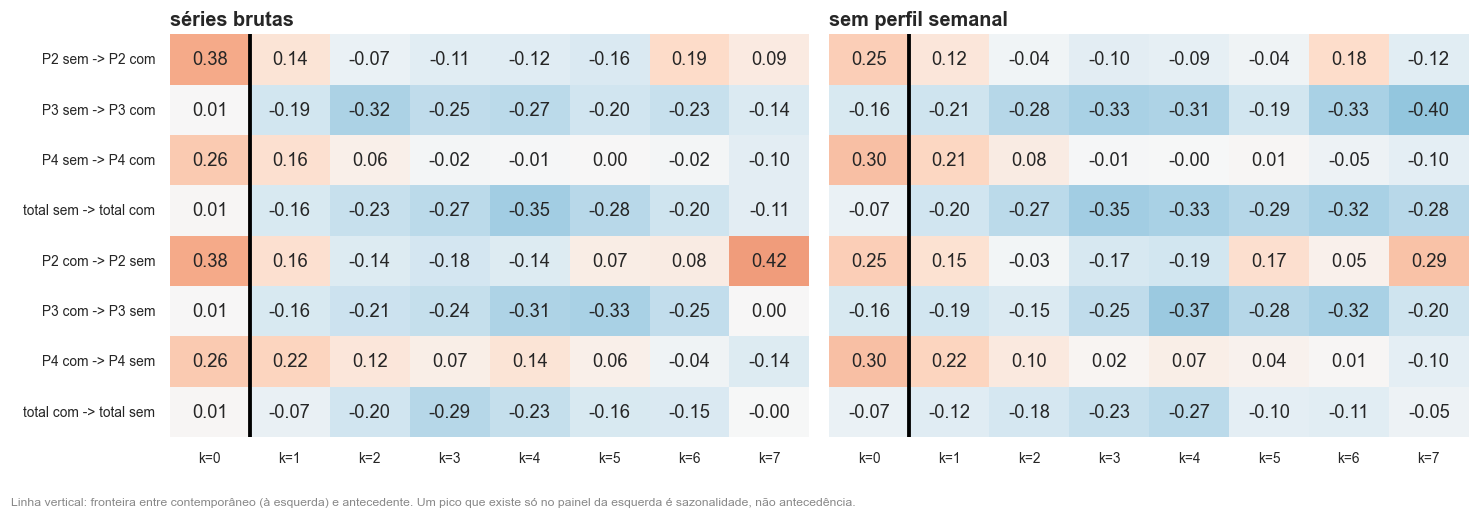


Features antecedentes candidatas (após remover o perfil semanal):

  P3 sem em D−7 -> P3 com em D (Spearman -0.395)
  total sem em D−3 -> total com em D (Spearman -0.349)
  P3 com em D−4 -> P3 sem em D (Spearman -0.368)


In [65]:
DEFASAGENS = range(0, 8)
CORR_MINIMA_FEATURE = 0.30

# Séries diárias de R3 com índice de datas comum. `correlacao_defasada()` alinha por índice —
# séries de tamanhos diferentes correlacionariam a interseção, silenciosamente.
series_r3 = {
    (p, t): (
        fato_diario_prioridade
        .query("regime == 3 and prioridade == @p and tipo_tratamento == @t")
        .set_index("data")["abertos"].sort_index()
    )
    for p in PRIORIDADES_ALVO for t in TIPOS_TRATAMENTO
}
for t in TIPOS_TRATAMENTO:
    series_r3[("total", t)] = sum(series_r3[(p, t)] for p in PRIORIDADES_ALVO)

PARES = (
    [(p, "sem_intervencao", p, "com_intervencao") for p in list(PRIORIDADES_ALVO) + ["total"]]
    + [(p, "com_intervencao", p, "sem_intervencao") for p in list(PRIORIDADES_ALVO) + ["total"]]
)


def rotulo(p, t):
    return f"{p if p == 'total' else 'P' + str(p)} {t.split('_')[0]}"


def matriz_defasada(series, pares=PARES, defasagens=DEFASAGENS):
    """Uma linha por par preditor→alvo, uma coluna por defasagem, mais o máximo em módulo."""
    linhas = []
    for px, tx, py, ty in pares:
        c = correlacao_defasada(series[(px, tx)], series[(py, ty)], defasagens)
        melhor = c.loc[c["correlacao"].abs().idxmax()]
        linhas.append({
            "preditor": rotulo(px, tx),
            "alvo": rotulo(py, ty),
            **{f"k={k}": round(v, 3) for k, v in zip(c["defasagem"], c["correlacao"])},
            "melhor_k": int(melhor["defasagem"]),
            "melhor_corr": round(melhor["correlacao"], 3),
        })
    return pd.DataFrame(linhas)


cruzada = matriz_defasada(series_r3)
print("Séries brutas — preditor(t−k) contra alvo(t), Spearman, R3\n")
print(cruzada.to_string(index=False))

# O pico em k=7 é suspeito por construção: as duas séries carregam ciclo semanal, e correlacionar
# x(t−7) com y(t) mede a sazonalidade compartilhada, não antecedência. Repetindo sobre o sinal já
# deseasonalizado por `preparar_sinal()`, o que sobrevive é relação de verdade.
series_desaz = {
    k: pd.Series(preparar_sinal(v.to_numpy(dtype=float)), index=v.index)
    for k, v in series_r3.items()
}
cruzada_desaz = matriz_defasada(series_desaz)
print("\n\nMesmas séries, em log1p e sem o perfil semanal\n")
print(cruzada_desaz.to_string(index=False))

fig, axes = novo_grafico("Correlação defasada entre tipos de tratamento (R3)",
                         figsize=(13.5, 4.5), ncols=2)
for ax, (tab, titulo) in zip(axes, [(cruzada, "séries brutas"),
                                    (cruzada_desaz, "sem perfil semanal")]):
    mapa = tab.set_index(tab["preditor"] + " -> " + tab["alvo"])[[f"k={k}" for k in DEFASAGENS]]
    sns.heatmap(mapa, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                cbar=False, ax=ax)
    ax.set_title(titulo)
    ax.set_ylabel("")
axes[1].set_yticklabels([])
for ax in axes:
    ax.axvline(1, color="black", lw=2.5)
finalizar(fig, "Linha vertical: fronteira entre contemporâneo (à esquerda) e antecedente. "
               "Um pico que existe só no painel da esquerda é sazonalidade, não antecedência.")

# Só vira candidata o que sobrevive à remoção do perfil semanal.
candidatas = (
    cruzada_desaz[(cruzada_desaz["melhor_k"] >= 1)
                  & (cruzada_desaz["melhor_corr"].abs() >= CORR_MINIMA_FEATURE)]
)
print("\n" + "=" * 78)
if len(candidatas):
    print("Features antecedentes candidatas (após remover o perfil semanal):\n")
    for _, l in candidatas.iterrows():
        print(f"  {l['preditor']} em D−{l['melhor_k']} -> {l['alvo']} em D "
              f"(Spearman {l['melhor_corr']})")
else:
    print(f"Nenhum par sobrevive: máximo em k >= 1 com |Spearman| >= {CORR_MINIMA_FEATURE}.")
    print("As duas séries são reflexo contemporâneo do mesmo dia, não indicadoras antecedentes")
    print("uma da outra. Nenhuma feature cruzada entra no modelo por este caminho.")

**Leitura — a hipótese de negócio não se sustenta, e o pouco que sobra tem o sinal invertido.**

Nenhuma correlação passa de |0,40|. Na série bruta o maior valor é 0,42, em `P2 com` → `P2 sem`
com **k = 7** — e é exatamente o tipo de resultado que o painel da direita existe para desmontar:
removido o perfil semanal, ele cai para 0,29. Era sazonalidade compartilhada, não antecedência.

O que sobrevive à deseasonalização, com |Spearman| ≥ 0,30:

| Preditor | Alvo | k | Spearman |
|---|---|---|---|
| P3 sem | P3 com | 7 | −0,39 |
| P3 com | P3 sem | 4 | −0,37 |
| total sem | total com | 3 | −0,35 |

Três observações antes de qualquer uso:

1. **O sinal é negativo.** Mais alerta automático hoje está associado a *menos* chamado tratado
   dias depois, não a mais. A hipótese de negócio — "volume anormal de alertas precede incidentes
   reais" — teria o sinal contrário. O que a correlação negativa provavelmente descreve é
   substituição: dias em que o monitoramento absorve o que antes viraria chamado.
2. **A magnitude é fraca e a amostra é curta.** Com 120 dias, |0,35| é pouco acima do que a
   flutuação amostral produz. Não é achado robusto.
3. **Nenhuma quebra clara entre contemporâneo e antecedente.** Em P2 e P4 o máximo está em k = 0
   nos dois painéis: são reflexo do mesmo dia, e valor contemporâneo não existe no momento da
   previsão.

**Recomendação: não incluir features cruzadas entre tipos na primeira rodada de modelagem.** Se
forem testadas depois, que seja só a de P3 e apenas como variável adicional a um modelo que já
bate o baseline — não como justificativa para complicar o desenho.

## 3.11 Alternativa de decomposição: nível × fração

Análise, não implementação de modelo. A pergunta é se vale decompor o problema em vez de treinar
6 modelos independentes:

```
total por prioridade   ×   fração que exige intervenção
```

Um modelo de contagem para o **nível** (quantos incidentes no dia) e um modelo binomial para a
**fração** (quantos deles exigem gente). As vantagens são reais, mas precisam ser verificadas
nesta base, não assumidas:

- a fração é limitada em [0, 1] e tende a ser mais suave que o nível;
- o gargalo de histórico curto afeta **só a fração** — o nível usa a janela toda, porque o total
  existe desde janeiro;
- garante coerência aditiva: as duas partes somam o total por construção, o que 6 modelos
  separados não dão.

O teste decisivo é a **estabilidade da fração**. Se ela for tão instável quanto as séries
absolutas, a decomposição só troca dois problemas por outros dois, e o caminho é modelar as
séries direto.

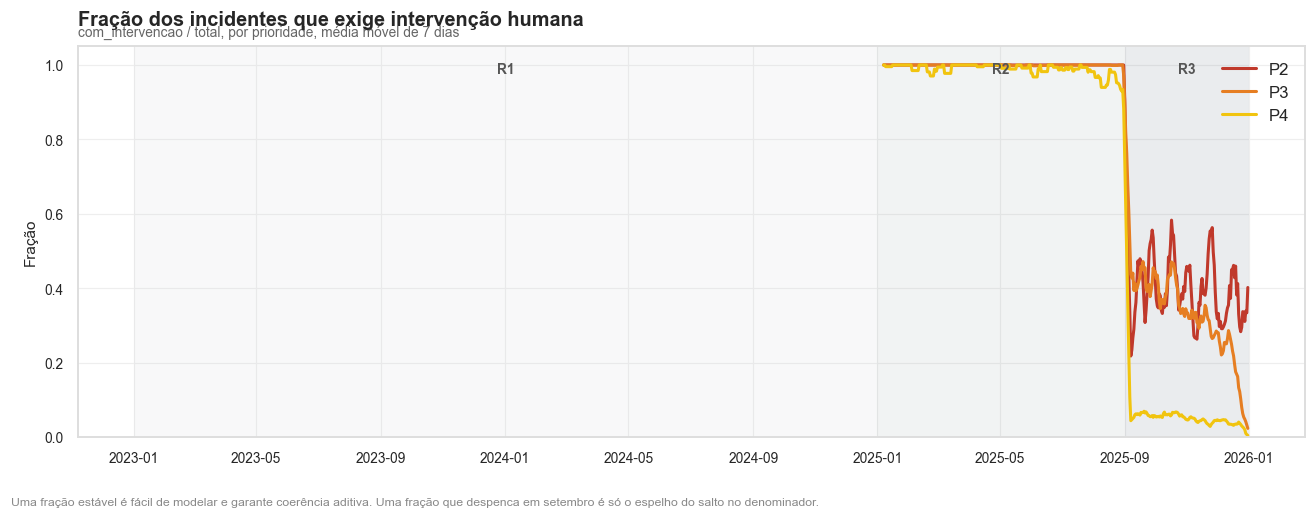

Coeficiente de variação em R3 — menor é mais fácil de prever

 prioridade  cv_nivel_total  cv_com_intervencao  cv_sem_intervencao  cv_fracao  fracao_media  fracao_min  fracao_max
          2            1.01                1.35                1.37       0.47          0.39        0.03        0.92
          3            0.62                0.55                0.86       0.51          0.32        0.00        0.61
          4            0.26                0.56                0.26       0.48          0.05        0.00        0.12

A fração tem quebra própria dentro de R3?

 prioridade  dias  p_permutacao  acf_lag1  acf_lag7
          2   122          0.56      0.14     -0.02
          3   122          0.01      0.61      0.68
          4   122          0.01      0.52      0.46

Recomendação

  P2: fração média 0.39 (faixa 0.03–0.92), CV 0.475
       fração é 2.9x mais estável que a série com intervenção e 2.9x mais que a sem -> decomposição favorecida
  P3: fração média 0.32 (faixa 0.00–0.61

In [66]:
# Série da fração: com_intervencao / total, por prioridade. Dia sem incidente algum fica nulo
# em vez de zero — 0 significaria "nenhum exigiu gente", que é afirmação diferente de "não houve
# incidente". Um fillna(0) aqui mascararia ausência de histórico como fração zero.
decomp = (
    fato_diario_prioridade.query("regime in @REGIME_MODELAVEL")
    .pivot_table(index=["data", "prioridade"], columns="tipo_tratamento",
                 values="abertos", aggfunc="sum")
    .reset_index()
)
decomp["total"] = decomp["com_intervencao"] + decomp["sem_intervencao"]
decomp["fracao_com"] = np.where(
    decomp["total"] > 0, decomp["com_intervencao"] / decomp["total"], np.nan
)
decomp["regime"] = np.select(
    [decomp["data"] < Q_R2, decomp["data"] < Q_R3], [1, 2], default=3
).astype("int8")

fig, ax = novo_grafico(
    "Fração dos incidentes que exige intervenção humana",
    "com_intervencao / total, por prioridade, média móvel de 7 dias",
)
for p in PRIORIDADES_ALVO:
    s = decomp.query("prioridade == @p").set_index("data")["fracao_com"]
    ax.plot(s.index, s.rolling(7).mean(), lw=2, color=COR_PRIORIDADE[p], label=f"P{p}")
marcar_regimes(ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Fração")
ax.legend()
finalizar(fig, "Uma fração estável é fácil de modelar e garante coerência aditiva. "
               "Uma fração que despenca em setembro é só o espelho do salto no denominador.")

# --- Variabilidade relativa: fração contra as duas séries absolutas ------
# Coeficiente de variação (desvio/média) dentro de R3, onde as três coexistem. É a medida
# que responde "qual das três é mais fácil de prever?".
def coef_variacao(s):
    s = pd.Series(s).dropna()
    return float(s.std() / s.mean()) if len(s) and s.mean() else np.nan


estab = []
for p in PRIORIDADES_ALVO:
    sub = decomp.query("prioridade == @p and regime == 3")
    estab.append({
        "prioridade": p,
        "cv_nivel_total": coef_variacao(sub["total"]),
        "cv_com_intervencao": coef_variacao(sub["com_intervencao"]),
        "cv_sem_intervencao": coef_variacao(sub["sem_intervencao"]),
        "cv_fracao": coef_variacao(sub["fracao_com"]),
        "fracao_media": sub["fracao_com"].mean(),
        "fracao_min": sub["fracao_com"].min(),
        "fracao_max": sub["fracao_com"].max(),
    })
estabilidade = pd.DataFrame(estab)

print("Coeficiente de variação em R3 — menor é mais fácil de prever\n")
print(estabilidade.round(3).to_string(index=False))

# --- Estabilidade estrutural da fração ----------------------------------
print("\n" + "=" * 78)
print("A fração tem quebra própria dentro de R3?\n")
quebras_fracao = []
for p in PRIORIDADES_ALVO:
    s = decomp.query("prioridade == @p and regime == 3").sort_values("data")
    valores = s["fracao_com"].ffill().to_numpy(dtype=float)
    # log1p não se aplica a proporção: aqui o sinal é a própria fração, sem estabilização.
    sinal = preparar_sinal(valores, log=False)
    _, _, p_val = teste_permutacao_quebra(
        sinal, n_bkps=1, min_size=MIN_SIZE_QUEBRA_R3, n_perm=N_PERM_QUEBRA
    )
    acf_1 = pd.Series(valores).autocorr(1)
    acf_7 = pd.Series(valores).autocorr(7)
    quebras_fracao.append({"prioridade": p, "dias": len(s), "p_permutacao": round(p_val, 4),
                           "acf_lag1": round(acf_1, 3), "acf_lag7": round(acf_7, 3)})
print(pd.DataFrame(quebras_fracao).to_string(index=False))

# --- Recomendação fundamentada ------------------------------------------
print("\n" + "=" * 78)
print("Recomendação\n")
for _, l in estabilidade.iterrows():
    p = int(l["prioridade"])
    ganho_com = l["cv_com_intervencao"] / l["cv_fracao"] if l["cv_fracao"] else np.nan
    ganho_sem = l["cv_sem_intervencao"] / l["cv_fracao"] if l["cv_fracao"] else np.nan
    veredito = (
        "decomposição favorecida" if (ganho_com > 1.5 and ganho_sem > 1.5)
        else "6 modelos separados" if (ganho_com < 1 or ganho_sem < 1)
        else "empate — decidir por coerência aditiva"
    )
    print(f"  P{p}: fração média {l['fracao_media']:.2f} (faixa {l['fracao_min']:.2f}–"
          f"{l['fracao_max']:.2f}), CV {l['cv_fracao']:.3f}")
    print(f"       fração é {ganho_com:.1f}x mais estável que a série com intervenção e "
          f"{ganho_sem:.1f}x mais que a sem -> {veredito}")

**Leitura — a resposta depende da prioridade, e essa é a resposta.**

| Prioridade | Fração média (R3) | CV da fração | CV com interv. | CV sem interv. | Quebra na fração (p) | ACF(1) |
|---|---|---|---|---|---|---|
| P2 | 0,39 | 0,47 | 1,35 | 1,36 | 0,50 | 0,13 |
| P3 | 0,32 | 0,51 | 0,55 | 0,85 | 0,01 | 0,61 |
| P4 | 0,05 | 0,48 | 0,56 | 0,26 | 0,01 | 0,52 |

**P2 — decomposição favorecida.** A fração é 2,9× mais estável que qualquer das duas séries
absolutas, e é a única cujo teste de permutação **não** acusa quebra dentro de R3 (p = 0,50). É
uma fração ruidosa dia a dia (ACF(1) = 0,13, quase sem memória), mas estacionária: um binomial
sobre uma média de 0,39 é um problema bem posto. E é a prioridade em que o nível se beneficia
mais, porque as duas séries absolutas de P2 são as mais voláteis da base.

**P3 — empate técnico.** A fração é só 1,1× mais estável que a série com intervenção. O ganho de
modelar a fração não paga a complexidade por si só. O que pesa aqui é outro argumento: P3 com
intervenção é a série com o pior histórico (68 dias, pela quebra de 25/10 vista em §3.1), e o
total de P3 não sofre dessa restrição na mesma medida. Se a decomposição for adotada em P2, vale
estendê-la a P3 pela coerência aditiva.

**P4 — seis modelos separados.** A fração média é 0,05: quase tudo em P4 é alerta automático.
Modelar uma proporção que vive colada em zero, com CV de 0,48, é mais difícil que modelar a série
sem intervenção diretamente — que tem o **menor** CV da tabela inteira (0,26). Aqui a decomposição
piora as duas pontas.

**Recomendação.** Não é "6 modelos" nem "decomposição": é **decomposição em P2 (e P3 por
coerência), séries diretas em P4**. Duas ressalvas que a tabela não mostra:

- a fração de P3 e P4 tem ACF(1) de ~0,5 e quebra dentro de R3 (p = 0,01) — não é a série suave
  que a teoria da decomposição promete;
- a decomposição tem um ganho colateral que nenhuma das colunas acima captura: o **total não
  amadurece** (§3.10). Prever nível e fração separadamente permite avaliar o nível sem defasagem
  nenhuma, e só a fração fica sujeita à espera de 1–2 dias.

---
# 4. Salvamento das tabelas finais

Um único bloco de escrita, com contrato explícito.

In [67]:
CATALOGO = {
    "s_fato_diario_prioridade": {
        "descricao": ("Grão dia × prioridade × tipo_tratamento. Tabela principal: as 6 séries "
                      "alvo, aberturas, fechamentos e janelas."),
        "chave": ["data", "prioridade", "tipo_tratamento"],
    },
    "s_fato_ola_prioridade": {
        "descricao": ("Grão dia × prioridade. Acumulado anual e atingimento de OLA. Vive fora do "
                      "fato porque a regra é calibrada sobre a prioridade inteira, não por tipo."),
        "chave": ["data", "prioridade"],
    },
    "s_fato_diario_prioridade_turno": {
        "descricao": "Grão dia × prioridade × tipo_tratamento × turno. Sazonalidade intradiária.",
        "chave": ["data", "prioridade", "tipo_tratamento", "turno"],
    },
    "s_fato_diario": {
        "descricao": "Grão dia. Contexto agregado + calendário.",
        "chave": ["data"],
    },
    "s_fato_diario_time": {
        "descricao": "Grão dia × time. Carga por grupo designado.",
        "chave": ["data", "time"],
    },
    "s_fato_diario_classe": {
        "descricao": "Grão dia × classe de descrição. Volume por tipo de alerta.",
        "chave": ["data", "classe_descricao"],
    },
    "s_ft_ic": {
        "descricao": "Grão dia. Features de item de configuração (ativos, outliers, inativos).",
        "chave": ["data"],
    },
    "s_ft_concentracao": {
        "descricao": "Grão dia. Concentração da carga entre times (HHI).",
        "chave": ["data"],
    },
    "s_dim_calendario": {"descricao": "Grão dia. Calendário e sazonalidade.", "chave": ["data"]},
    "s_dim_ic": {"descricao": "Grão IC. Perfil consolidado.", "chave": ["ic"]},
    "s_dim_ic_regime": {"descricao": "Grão IC × regime.", "chave": ["ic", "regime"]},
    "s_dim_time_regime": {"descricao": "Grão time × regime.", "chave": ["time", "regime"]},
    "s_dim_template": {"descricao": "Grão template de descrição.", "chave": ["template_descricao"]},
    "s_tabela_modelo": {
        "descricao": ("Grão dia, formato largo. Matriz pronta para modelagem: colunas "
                      "p{prioridade}_{tipo}_{métrica} para as 6 séries e p{prioridade}_{métrica} "
                      "para o grão de prioridade."),
        "chave": ["data"],
    },
}


def salvar(tabela, nome, pasta=SAVE_PATH, catalogo=CATALOGO, sep=";", encoding="utf-8-sig"):
    """
    Grava validando o contrato: a chave existe, é única e não tem nulo.

    """
    meta = catalogo.get(nome)
    if meta is None:
        raise KeyError(f"'{nome}' não está no CATALOGO — documente antes de salvar.")

    chave = meta["chave"]
    faltando = set(chave) - set(tabela.columns)
    if faltando:
        raise ValueError(f"{nome}: chave ausente {sorted(faltando)}")
    if tabela[chave].isna().any().any():
        raise ValueError(f"{nome}: chave {chave} contém nulo")
    dups = int(tabela.duplicated(subset=chave).sum())
    if dups:
        raise ValueError(f"{nome}: {dups} linhas duplicadas na chave {chave}")

    Path(pasta).mkdir(parents=True, exist_ok=True)
    caminho = f"{pasta}{nome}.csv"
    tabela.to_csv(caminho, index=False, sep=sep, encoding=encoding)
    print(f"  {nome:<34} {tabela.shape[0]:>7,} x {tabela.shape[1]:>3}  ->  {caminho}")
    return caminho

In [68]:
print("Gravando tabelas silver\n")

salvar(fato_diario_prioridade, "s_fato_diario_prioridade")
salvar(fato_ola_prioridade, "s_fato_ola_prioridade")
salvar(fato_diario_prioridade_turno, "s_fato_diario_prioridade_turno")
salvar(fato_diario, "s_fato_diario")
salvar(fato_diario_time, "s_fato_diario_time")
salvar(fato_diario_classe, "s_fato_diario_classe")
salvar(ft_ic, "s_ft_ic")
salvar(ft_concentracao, "s_ft_concentracao")
salvar(dim_calendario, "s_dim_calendario")
salvar(dim_ic, "s_dim_ic")
salvar(dim_ic_regime, "s_dim_ic_regime")
salvar(dim_time_regime, "s_dim_time_regime")
salvar(dim_template, "s_dim_template")
salvar(tabela_modelo, "s_tabela_modelo")

print("\nCatálogo:\n")
print(
    pd.DataFrame(CATALOGO).T
    .assign(chave=lambda d: d["chave"].map(lambda k: " + ".join(k)))
    .to_string()
)

print("\nEquivalência com a versão anterior (grão dia × prioridade):\n")
print(
    pd.DataFrame([
        ("s_fato_diario_prioridade", "ganhou `tipo_tratamento` na chave: 3.285 -> 6.570 linhas"),
        ("s_fato_diario_prioridade_turno", "idem: 13.140 -> 26.280 linhas"),
        ("fechados_sem_intervencao", "removida — virou a dimensão `tipo_tratamento`"),
        ("taxa_sem_intervencao", "removida — no novo grão seria 100 ou 0"),
        ("atingimento_ola_duracao / _volume", "movidas para s_fato_ola_prioridade"),
        ("fechados_ac_ano / kpi_violado_ac_ano", "agora por tipo; a versão por prioridade está "
                                                 "em s_fato_ola_prioridade com sufixo _prioridade"),
        ("y_abertos_d1 / _d7 / _acum_1a7", "3 alvos x 6 séries em vez de 3 alvos x 3 séries"),
        ("s_tabela_modelo", "colunas p{prio}_{tipo}_{métrica}; OLA continua p{prio}_{métrica}"),
    ], columns=["objeto", "o que mudou"]).to_string(index=False)
)

Gravando tabelas silver

  s_fato_diario_prioridade             6,570 x  53  ->  ../2_silver_data/s_fato_diario_prioridade.csv
  s_fato_ola_prioridade                3,285 x   9  ->  ../2_silver_data/s_fato_ola_prioridade.csv
  s_fato_diario_prioridade_turno      26,280 x   7  ->  ../2_silver_data/s_fato_diario_prioridade_turno.csv
  s_fato_diario                        1,095 x  43  ->  ../2_silver_data/s_fato_diario.csv
  s_fato_diario_time                  18,615 x   7  ->  ../2_silver_data/s_fato_diario_time.csv
  s_fato_diario_classe                12,045 x   7  ->  ../2_silver_data/s_fato_diario_classe.csv
  s_ft_ic                              1,095 x  14  ->  ../2_silver_data/s_ft_ic.csv
  s_ft_concentracao                    1,095 x   4  ->  ../2_silver_data/s_ft_concentracao.csv
  s_dim_calendario                     1,095 x  23  ->  ../2_silver_data/s_dim_calendario.csv
  s_dim_ic                             9,171 x  18  ->  ../2_silver_data/s_dim_ic.csv
  s_dim_ic_regime    

## Próximos passos

**Antes de modelar** — decisões, não código:

1. **Fechar a janela de treino de cada série** com base na tabela de §3.1 (`JANELA_TREINO`). É o
   insumo direto do split de validação.
2. **Escolher entre 6 modelos e a decomposição nível × fração** (§3.12), com a recomendação
   daquela seção na mesa.
3. **Fechar se D+7 é a contagem no dia ou o acumulado da semana** (§2.10).

**Na modelagem:**

4. Começar pelos baselines de §3.8, que agora são 6 séries × 2 horizontes. São **piso**: modelo
    que não bate a média móvel de 7 dias da sua série não deve seguir.
5. Preferir modelo de contagem (Poisson / Binomial Negativa) a regressão gaussiana — o alvo é
    contagem, tem cauda longa e não pode ser negativo.
6. Respeitar a janela de treino por série. Treinar uma série sem intervenção em R2 é treiná-la
    num período em que ela não existia.
7. Validar por origem móvel com `gap` igual ao horizonte, nunca por embaralhamento (§3.9).